## Module 3 Supply Chain & Data Level Attacks

---

<details>

<summary><b>Module Overview — Click to Expand</b></summary>

<br>

Artificial intelligence systems depend on much more than the machine learning model itself. Before a model is deployed, developers may collect data from external sources, rely on third-party labeling services, install machine learning frameworks, download pretrained models, use cloud infrastructure, and integrate software libraries and APIs.

Together, these components form the **AI supply chain**.

Every component in this supply chain introduces dependencies and trust relationships. If an attacker compromises an upstream dataset, software dependency, pretrained model, or other resource, the effects of that compromise may spread throughout the AI system.

This module explores **AI supply chain security and data-level attacks**, with particular attention to attacks that manipulate the information used to train machine learning models.

You will learn how attackers can manipulate training data to influence model behavior through techniques such as:

- Data poisoning
- Label manipulation and label flipping
- Targeted poisoning
- Untargeted poisoning
- Clean-label poisoning
- Backdoor attacks

A major focus of this module is understanding that an AI model can appear to operate normally while still containing security weaknesses introduced during training.

Throughout the module, you will complete a series of **hands-on mini labs** that demonstrate these attacks against simplified machine learning systems. Rather than only reading about each attack, you will examine how the training data changes, train models using clean and poisoned datasets, compare model behavior, and observe how different attacks affect model performance.

You will also examine defensive techniques for identifying suspicious training data and reducing the risk of data-level attacks.

By the end of the module, you should understand an important principle of AI security:

> **A model can only be trusted when the data, software, models, and infrastructure used to create it can also be trusted.**

</details>

<details>

<summary><b>Learning Objectives — Click to Expand</b></summary>

<br>

By the end of this module, you should be able to:

1. **Explain the AI supply chain** and identify the external components, services, data, software, and infrastructure that contribute to the development of an AI system.

2. **Identify common AI supply chain risks** involving datasets, third-party labeling, pretrained models, machine learning frameworks, cloud infrastructure, and deployment environments.

3. **Explain data poisoning** and describe how manipulated training data can influence the behavior of a machine learning model.

4. **Distinguish between targeted and untargeted poisoning attacks** based on the attacker's intended effect on model behavior.

5. **Explain label-flipping attacks** and observe how changing training labels can influence model predictions.

6. **Explain clean-label poisoning** and recognize how attackers can manipulate training inputs without changing their visible class labels.

7. **Explain backdoor attacks** and identify important concepts including triggers, target classes, poisoning rates, and attack success rates.

8. **Evaluate the effects of poisoned training data** using measurements such as overall accuracy, class-specific performance, confusion matrices, and targeted attack behavior.

9. **Recognize why aggregate model accuracy may not reveal a successful attack**, particularly when an attack targets a specific class, input pattern, or triggered behavior.

10. **Apply basic techniques for identifying suspicious training data**, including examining class distributions, feature behavior, outliers, duplicates, and unexpected patterns.

11. **Describe defensive practices for reducing data-level risk**, including data provenance, dataset validation, access control, integrity verification, monitoring, and trusted data collection.

12. **Explain why securing the complete AI supply chain is necessary** for maintaining the integrity and trustworthiness of deployed AI systems.

</details>

---

<details>

<summary><b>Section 1 — Understanding the AI Supply Chain — Click to Expand</b></summary>

<br>

Artificial intelligence systems are rarely developed entirely from scratch by a single person or organization. Modern AI development depends on a collection of data sources, software, pretrained models, development tools, infrastructure, and third-party services. These interconnected resources form the **AI supply chain**.

This supply chain is important from a security perspective because the final AI model can inherit problems from the components used to create it. An organization may carefully secure its deployed model while unknowingly relying on poisoned training data, an untrusted pretrained model, a compromised software dependency, or an insecure development environment.

Throughout this section, you will examine what makes up an AI supply chain, where attackers may target it, and why defenders must consider more than just the final trained model.

<br>

<details>

<summary><b>1.1 — What Is the AI Supply Chain?</b></summary>

<br>

The **AI supply chain** includes the people, organizations, data, software, models, hardware, infrastructure, and services involved in creating and operating an AI system. Some of these resources may be developed internally, while others may come from external organizations or public sources.

Consider an organization building an image classification system. Instead of collecting and labeling every image itself, the organization might download a public dataset and use a third-party company to label additional examples. Developers might begin with a pretrained model rather than creating one from scratch, use an open-source machine learning framework to train it, and rely on cloud infrastructure for the computing resources needed during training.

The resulting supply chain could include resources such as:

- Public or privately collected training datasets
- Third-party data-labeling services
- Pretrained machine learning models
- Open-source libraries and dependencies
- Machine learning frameworks
- Model repositories
- Cloud computing and storage services
- Internal development environments
- Deployment infrastructure
- Monitoring and retraining systems

A simplified AI development pipeline might look like:

    Data Collection
          ↓
    Data Preparation & Labeling
          ↓
    Model Selection
          ↓
    Model Training
          ↓
    Model Testing
          ↓
    Model Repository
          ↓
    Deployment
          ↓
    Monitoring & Retraining

Each stage provides something necessary for the final AI application. At the same time, each stage introduces another dependency that the organization must trust.

When developers use a public dataset, they trust that the dataset has not been intentionally manipulated. When they use a labeling service, they trust that the labels are accurate. When they download a pretrained model, they trust that the model has not been modified to contain hidden malicious behavior.

This creates one of the central questions in AI supply chain security:

> **If the final AI model depends on all of these components, what happens if one of those components cannot be trusted?**

A security problem introduced early in this pipeline may continue through development and eventually influence the deployed AI system.

</details>

<br>

<details>

<summary><b>1.2 — Important Assets in the AI Supply Chain</b></summary>

<br>

Before thinking about attacks, defenders first need to understand **what needs to be protected**.

An **asset** is something within the system that has value and could be negatively affected if its confidentiality, integrity, or availability were compromised.

In a traditional information system, assets might include databases, user accounts, servers, or sensitive files. AI systems contain many of these same assets, but they also introduce assets that are especially important to machine learning.

Possible AI supply chain assets include:

- **Training datasets** — The information from which the model learns.
- **Training labels** — The classifications or expected outputs associated with training examples.
- **Model weights and parameters** — The learned internal values that determine model behavior.
- **Pretrained models** — Models obtained externally and reused or fine-tuned.
- **Training code** — The software responsible for creating the model.
- **Software dependencies** — Packages and libraries required by the development environment.
- **Credentials and API keys** — Authentication information used to access AI resources.
- **Model repositories** — Locations where trained models and model versions are stored.
- **Training infrastructure** — Systems providing the computing resources used to train models.
- **Deployment infrastructure** — Systems responsible for hosting and serving the model.
- **Security logs and monitoring data** — Information used to identify suspicious activity or changes.

Different assets require different types of protection.

For example, the **integrity of the training dataset** is extremely important because changing the data may change what the model learns. The **confidentiality of model weights** may matter when the model contains proprietary information. The **availability of a deployed AI service** matters when other systems depend on its predictions.

Identifying assets gives defenders a clearer understanding of what an attacker might target and why those targets matter.

</details>

<br>

<details>

<summary><b>1.3 — Third-Party Dependencies and Trust</b></summary>

<br>

A major characteristic of the AI supply chain is its reliance on **third-party dependencies**.

An organization may not control every dataset, model, software package, or service used during AI development. Instead, developers often rely on resources created and maintained by other organizations.

This creates a trust relationship.

For example, downloading a public dataset means trusting that the source has provided legitimate data. Using a pretrained model means trusting both the person who created the model and the platform distributing it. Installing a machine learning package means trusting the package maintainers and potentially the developers responsible for its dependencies.

Common third-party dependencies may include:

- Public datasets
- Commercial datasets
- Data-labeling companies
- Open-source software
- Machine learning frameworks
- Pretrained models
- Public model repositories
- Cloud providers
- External APIs
- Data collection services

Using a third-party resource does not automatically make the system insecure. These resources are a normal and often necessary part of AI development.

The security problem occurs when an organization **places trust in a component without understanding or verifying that trust**.

For every important dependency, defenders should consider where the resource came from, who controls it, who can modify it, and what effect a compromise could have on the rest of the AI system.

</details>

<br>

<details>

<summary><b>1.4 — AI Supply Chain Attack Points</b></summary>

<br>

Because the AI supply chain contains many interconnected components, attackers may have multiple opportunities to influence the final system.

Instead of directly attacking the deployed model, an attacker may target something the development team already trusts.

Possible attack points include:

- **Training data** — Poisoning, inserting, deleting, or modifying training examples.
- **Training labels** — Changing labels so that the model learns incorrect relationships.
- **Pretrained models** — Distributing models containing hidden backdoors or manipulated behavior.
- **Software dependencies** — Compromising libraries or packages used during AI development.
- **Model repositories** — Replacing, modifying, or stealing stored models.
- **Cloud environments** — Using compromised credentials or misconfigurations to access AI resources.
- **Training infrastructure** — Manipulating code, datasets, or models during training.
- **Deployment pipelines** — Replacing an approved model with an unauthorized version.
- **APIs** — Abusing interfaces used to interact with models or supporting services.

These attack points demonstrate why AI security cannot focus exclusively on the deployed model.

For example, imagine that an organization has strong authentication and access controls protecting its deployed model. Those controls may successfully prevent attackers from modifying the production system directly.

However, suppose an attacker manipulated the training dataset several weeks earlier.

The organization may securely deploy the model, but the model itself may already have learned behavior influenced by the attacker.

The attack occurred **upstream**, while the consequences appeared **downstream**.

This is one of the most important ideas in supply chain security.

</details>

<br>

<details>

<summary><b>1.5 — Why Supply Chain Attacks Can Be Powerful</b></summary>

<br>

Supply chain attacks can be especially concerning because attackers may be able to compromise a resource that is trusted and reused by many downstream users.

Consider a pretrained model hosted in a public repository. If hundreds of organizations download that model and incorporate it into their own applications, those organizations share a common dependency.

An attacker who successfully compromises that dependency may not need to attack every organization individually. Instead, the attacker attempts to influence the resource that those organizations already trust.

The same idea applies to datasets and software packages.

A manipulated dataset that is widely reused could influence multiple models. A compromised software dependency could affect many development environments. A malicious pretrained model could introduce unwanted behavior into several downstream applications.

This creates what can be described as **transitive trust**.

Suppose:

    Organization A trusts Model B

But:

    Model B depends on Dataset C

And:

    Dataset C came from Source D

The relationship becomes:

    Organization A
          ↓ trusts
       Model B
          ↓ depends on
       Dataset C
          ↓ provided by
       Source D

Organization A may therefore indirectly depend on Source D even if its developers never directly interacted with that source.

This makes understanding dependencies an important part of AI security.

</details>

<br>

<details>

<summary><b>1.6 — Data as a Critical Supply Chain Asset</b></summary>

<br>

Although many parts of the AI supply chain require protection, **training data deserves special attention** because machine learning models learn their behavior from data.

Traditional software is largely controlled by instructions written directly by developers. Machine learning systems behave differently because part of their behavior is learned from examples.

This creates a unique security relationship:

    Training Data
          ↓
    Learning Process
          ↓
    Model Behavior

If the training data changes, the learned behavior of the model may also change.

An attacker who can influence the training dataset may therefore be able to influence the model **without directly modifying the model itself**.

For example, an attacker might attempt to change training labels, insert malicious examples, duplicate particular samples, or modify the distribution of the training data. Depending on the attack, the goal might be to reduce overall model performance or cause very specific inputs to be classified incorrectly.

This family of attacks is commonly associated with **data poisoning**.

Data poisoning will become one of the primary topics in the remainder of this module because it demonstrates how an attacker can exploit the AI supply chain before the model is ever deployed.

</details>

<br>

<details>

<summary><b>1.7 — Evaluating Trust in the AI Supply Chain</b></summary>

<br>

Supply chain security does not mean that defenders should automatically assume every external component is malicious. Instead, defenders should understand **where trust is being placed and whether that trust is justified**.

When evaluating an important AI supply chain component, several questions can help guide the analysis:

- Where did the component originate?
- Who created or maintains it?
- Who is authorized to modify it?
- Has its integrity been verified?
- Can changes to the component be detected?
- Is its history or provenance available?
- What other components depend on it?
- What happens if it is compromised?
- Can a trusted version be restored?

Consider a public training dataset. Knowing where it came from is useful, but defenders should also consider whether unknown users could contribute data, whether changes are tracked, whether labels have been validated, and whether previous trusted versions are available.

A pretrained model requires similar questions. Defenders may want to know who published it, whether the source is reputable, whether the downloaded model matches an expected version, and whether its behavior has been independently tested.

This approach changes the security question from:

> **"Do we trust this component?"**

to:

> **"Why do we trust this component, and what evidence supports that trust?"**

That is a much stronger starting point for supply chain security.

</details>

<br>

<details>

<summary><b>1.8 — Why AI Supply Chain Security Matters</b></summary>

<br>

The final AI application is influenced by everything that happens before deployment.

A poisoned dataset can cause the model to learn from manipulated information. Incorrect or malicious labels can teach the model incorrect relationships. A compromised pretrained model may introduce hidden behavior. A malicious software dependency could affect the development environment. Stolen cloud credentials could give an attacker access to datasets, training resources, or models.

Even after training is complete, supply chain risk remains. A model repository could be compromised, an approved model could be replaced during deployment, or new poisoned data could be introduced during future retraining.

The complete relationship can be thought of as a chain:

    Data Sources
         ↓
    Data Preparation
         ↓
    Training Dataset
         ↓
    Software & Dependencies
         ↓
    Training Infrastructure
         ↓
    Trained Model
         ↓
    Model Repository
         ↓
    Deployment Infrastructure
         ↓
    AI Application
         ↓
    Monitoring & Retraining

Each component contributes to the trustworthiness of what comes after it.

This does not mean that every weakness will automatically compromise the entire system. It means defenders need to understand how weaknesses can **propagate through dependencies** and where security controls should be placed to reduce that risk.

Protecting only the final model leaves much of this chain unexamined.

</details>

<br>

<details>

<summary><b>Section 1 — Key Takeaways</b></summary>

<br>

An AI system is built from a collection of interconnected components rather than from the model alone. Training datasets, labels, pretrained models, software dependencies, cloud infrastructure, model repositories, deployment environments, and third-party services can all contribute to the security of the final application.

These components create **trust relationships**. When developers use an external dataset, model, service, or software package, they are depending on that resource to behave as expected. Understanding where that trust is placed is an important part of securing AI systems.

Attackers may also target these upstream dependencies instead of directly attacking the final application. A successful compromise early in the AI lifecycle can influence components that appear much later in the development process.

Some important areas defenders should pay attention to include:

- Training data and labels
- Pretrained models
- Third-party services
- Software packages and dependencies
- Training environments
- Model repositories
- Cloud infrastructure
- Deployment pipelines

Among these components, training data is especially important because the model learns its behavior from that information.

The main lesson from this section is:

> **The security and trustworthiness of an AI model depend partly on the security and integrity of the supply chain used to create it.**

In the next sections, you will begin examining what happens when attackers exploit one of the most important parts of this supply chain: **the data used to train the model**.

</details>

</details>


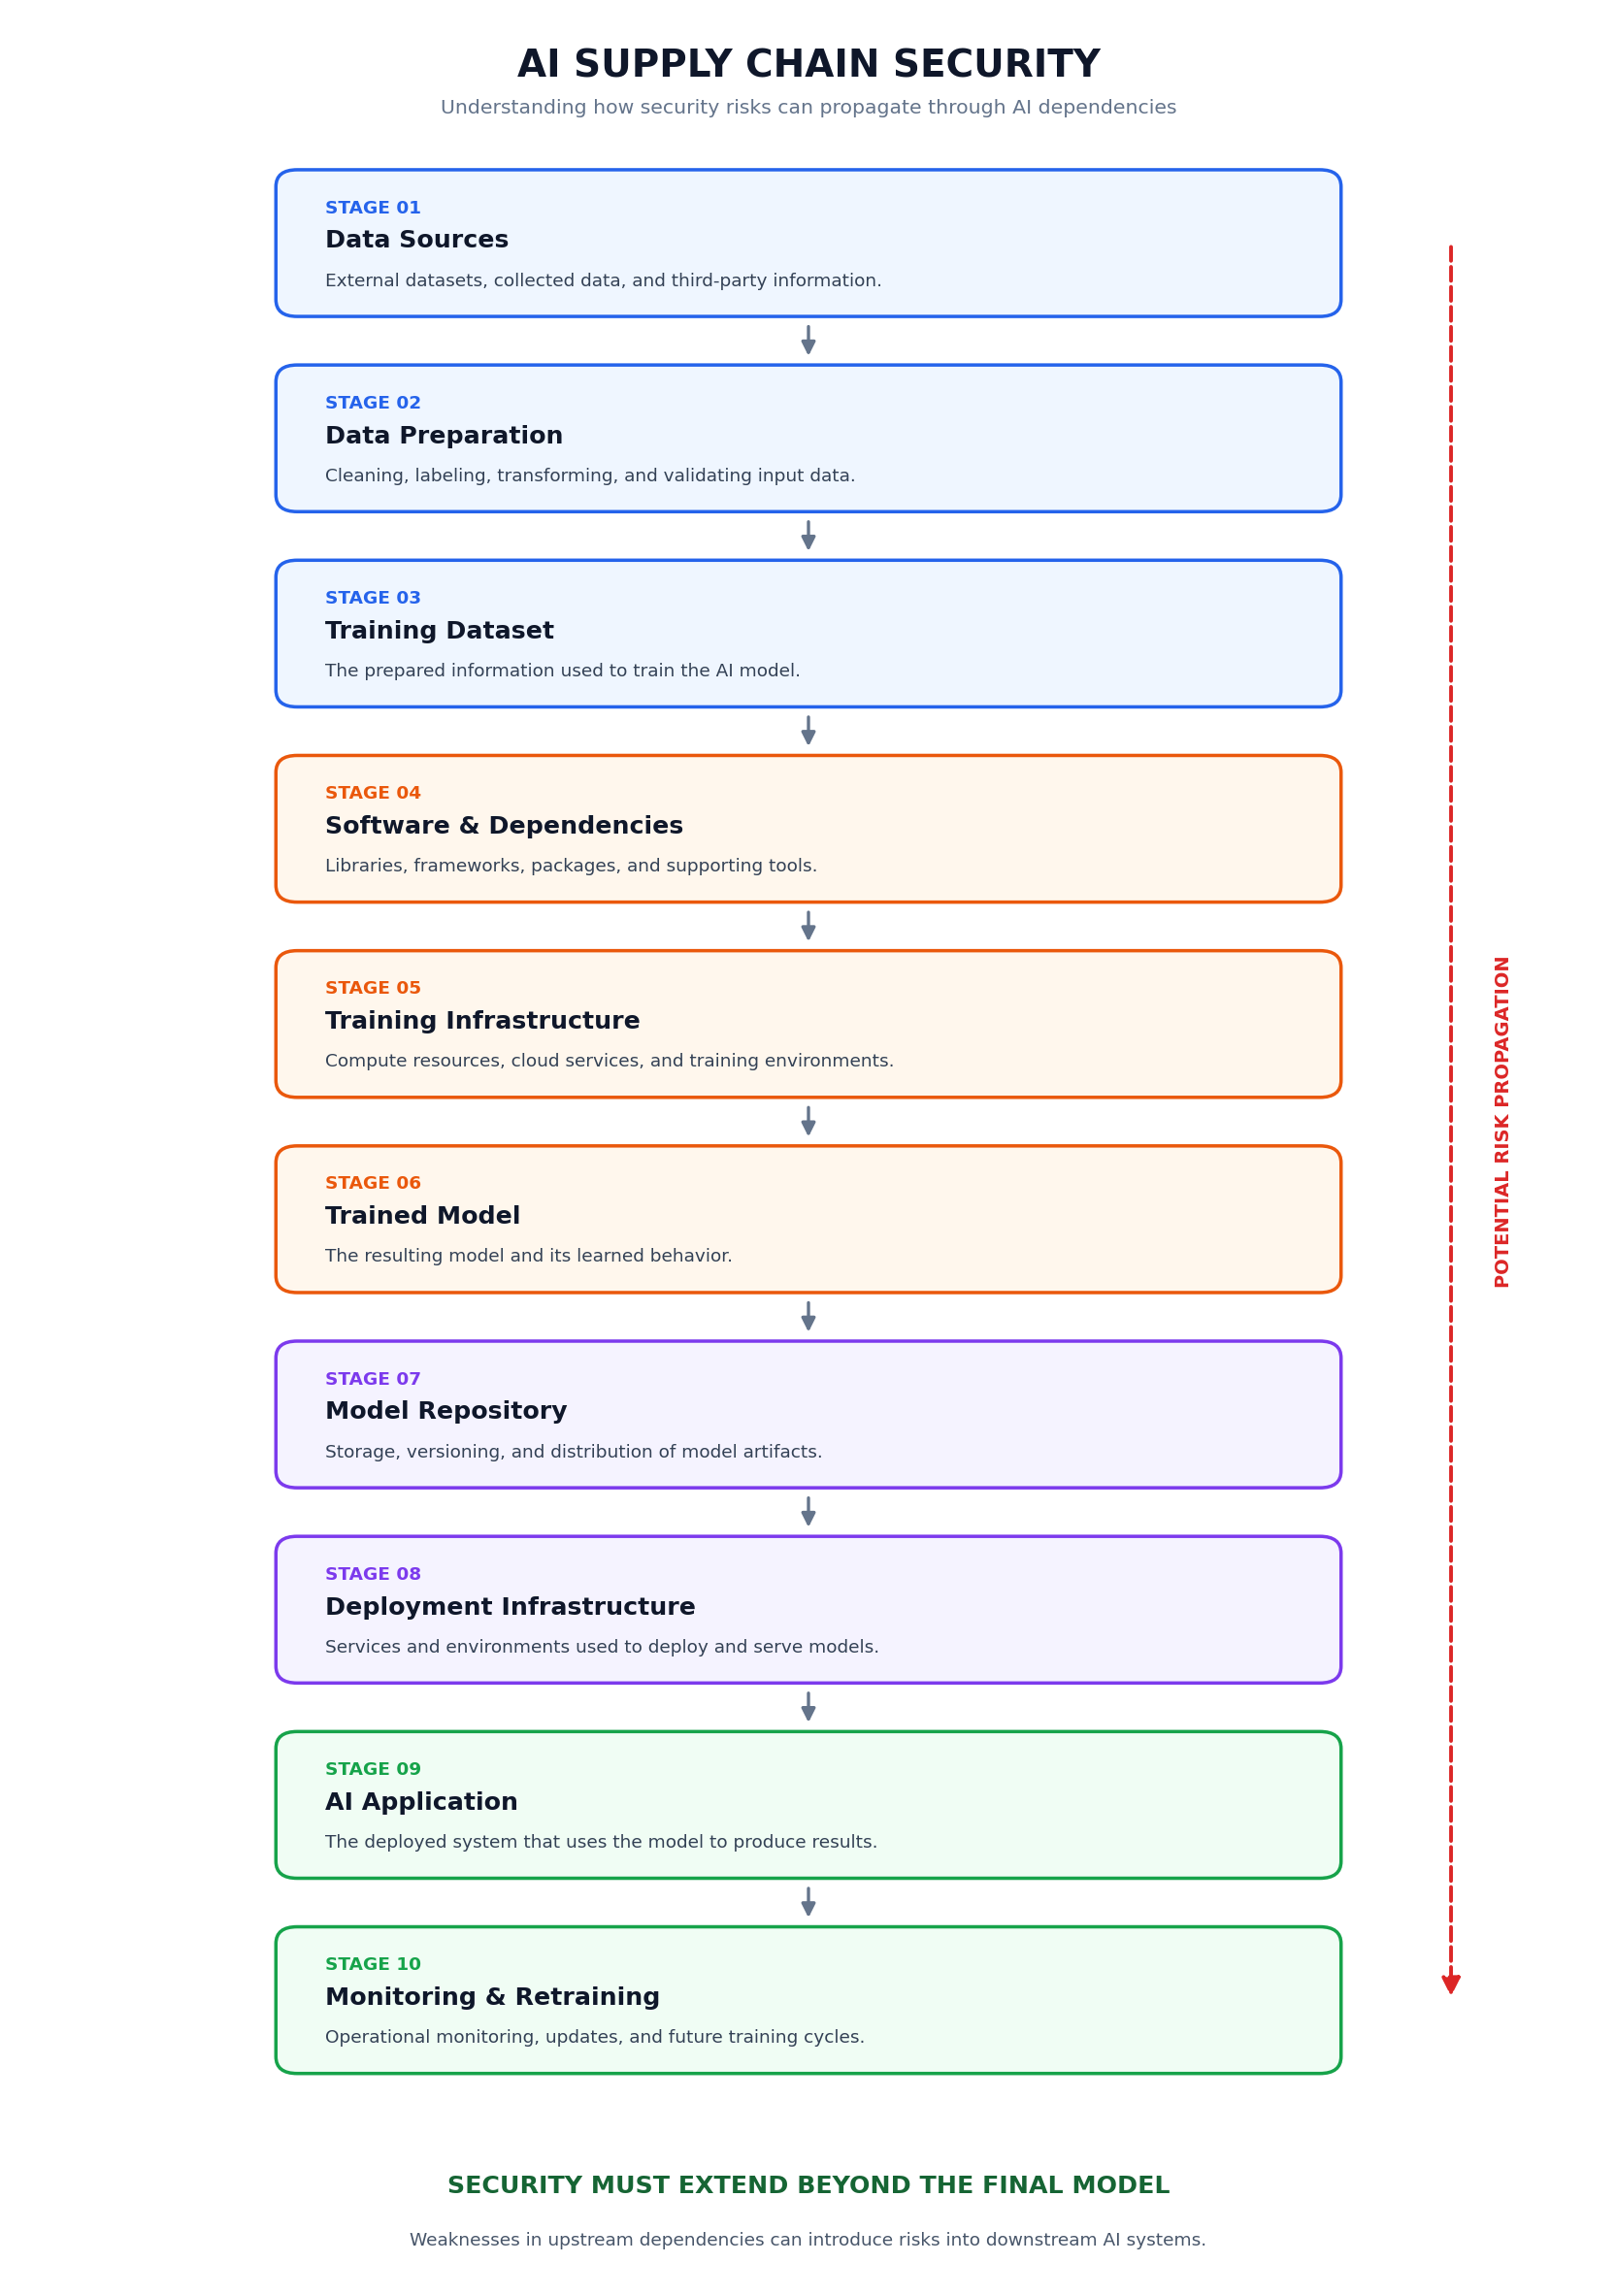

In [ ]:
# @title 1.8 — Why AI Supply Chain Security Matters { display-mode: "form" }

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64
import textwrap

# ============================================================
# SUPPLY CHAIN WORKFLOW CONTENT
# ============================================================

steps = [
    ("01", "Data Sources",
     "External datasets, collected data, and third-party information."),

    ("02", "Data Preparation",
     "Cleaning, labeling, transforming, and validating input data."),

    ("03", "Training Dataset",
     "The prepared information used to train the AI model."),

    ("04", "Software & Dependencies",
     "Libraries, frameworks, packages, and supporting tools."),

    ("05", "Training Infrastructure",
     "Compute resources, cloud services, and training environments."),

    ("06", "Trained Model",
     "The resulting model and its learned behavior."),

    ("07", "Model Repository",
     "Storage, versioning, and distribution of model artifacts."),

    ("08", "Deployment Infrastructure",
     "Services and environments used to deploy and serve models."),

    ("09", "AI Application",
     "The deployed system that uses the model to produce results."),

    ("10", "Monitoring & Retraining",
     "Operational monitoring, updates, and future training cycles.")
]

# Color groups:
# Blue   = Data supply chain
# Orange = Development and training
# Purple = Model storage and deployment
# Green  = Operation and continuous improvement

colors = [
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#FFF7ED", "#EA580C"),
    ("#FFF7ED", "#EA580C"),
    ("#FFF7ED", "#EA580C"),
    ("#F5F3FF", "#7C3AED"),
    ("#F5F3FF", "#7C3AED"),
    ("#F0FDF4", "#16A34A"),
    ("#F0FDF4", "#16A34A")
]

# ============================================================
# CREATE DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(12, 17))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 12)
ax.set_ylim(0, 21.5)
ax.axis("off")

ax.text(
    6, 21.0,
    "AI SUPPLY CHAIN SECURITY",
    ha="center",
    va="center",
    fontsize=20,
    fontweight="bold",
    color="#0F172A"
)

ax.text(
    6, 20.55,
    "Understanding how security risks can propagate through AI dependencies",
    ha="center",
    fontsize=10.5,
    color="#64748B"
)

# ============================================================
# DRAW SUPPLY CHAIN STAGES
# ============================================================

card_x = 2.0
card_width = 8.0
card_height = 1.35
step_spacing = 1.85
first_y = 18.65

for i, (number, title, description) in enumerate(steps):

    y = first_y - i * step_spacing
    bg, accent = colors[i]

    card = FancyBboxPatch(
        (card_x, y),
        card_width,
        card_height,
        boxstyle="round,pad=0.02,rounding_size=0.16",
        facecolor=bg,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        card_x + 0.35,
        y + 0.96,
        f"STAGE {number}",
        fontsize=9.5,
        fontweight="bold",
        color=accent
    )

    ax.text(
        card_x + 0.35,
        y + 0.63,
        title,
        fontsize=13,
        fontweight="bold",
        color="#0F172A"
    )

    ax.text(
        card_x + 0.35,
        y + 0.27,
        description,
        fontsize=9.5,
        color="#334155"
    )

    # Arrow to next stage
    if i < len(steps) - 1:

        ax.add_patch(
            FancyArrowPatch(
                (6, y - 0.08),
                (6, y - 0.43),
                arrowstyle="-|>",
                mutation_scale=15,
                linewidth=1.7,
                color="#64748B"
            )
        )

# ============================================================
# RISK PROPAGATION INDICATOR
# ============================================================

# Dashed red arrow indicates that a compromised upstream
# dependency may affect downstream stages.

top_y = first_y + card_height / 2
bottom_y = first_y - 9 * step_spacing + card_height / 2

risk_x = 10.85

ax.add_patch(
    FancyArrowPatch(
        (risk_x, top_y),
        (risk_x, bottom_y),
        arrowstyle="-|>",
        mutation_scale=20,
        linewidth=2,
        linestyle="--",
        color="#DC2626"
    )
)

ax.text(
    11.25,
    (top_y + bottom_y) / 2,
    "POTENTIAL RISK PROPAGATION",
    rotation=90,
    ha="center",
    va="center",
    fontsize=10,
    fontweight="bold",
    color="#DC2626",
    bbox=dict(
        facecolor="white",
        edgecolor="none",
        pad=5
    )
)

# ============================================================
# FINAL TAKEAWAY
# ============================================================

ax.text(
    6,
    0.85,
    "SECURITY MUST EXTEND BEYOND THE FINAL MODEL",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#166534"
)

ax.text(
    6,
    0.35,
    "Weaknesses in upstream dependencies can introduce risks into downstream AI systems.",
    ha="center",
    fontsize=9.5,
    color="#475569"
)

plt.tight_layout()

# ============================================================
# CONVERT DIAGRAM TO EMBEDDED IMAGE
# ============================================================

buffer = BytesIO()

fig.savefig(
    buffer,
    format="png",
    dpi=140,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)

image_data = base64.b64encode(
    buffer.getvalue()
).decode("utf-8")

buffer.close()

# ============================================================
# DISPLAY COLLAPSIBLE WORKFLOW
# ============================================================

display(HTML(f"""
<details style="
    margin:12px 0;
    border:1px solid #bfdbfe;
    border-radius:10px;
    overflow:hidden;
">

    <summary style="
        cursor:pointer;
        font-size:16px;
        font-weight:bold;
        padding:16px;
        background:#eff6ff;
        color:#1e3a8a;
        border-left:5px solid #2563eb;
    ">
        1.8 — Why AI Supply Chain Security Matters — Click to Expand
    </summary>

    <div style="
        padding:15px;
        background:white;
        text-align:center;
    ">

        <img
            src="data:image/png;base64,{image_data}"
            style="
                width:100%;
                max-width:900px;
                height:auto;
            "
        >

        <div style="
            max-width:750px;
            margin:15px auto;
            padding:16px;
            background:#f8fafc;
            border-radius:8px;
            color:#334155;
            font-size:14px;
            line-height:1.7;
            text-align:left;
        ">

            The final AI application is influenced by the
            security of its upstream dependencies.

            <br><br>

            Compromised datasets, malicious dependencies,
            stolen credentials, or altered model artifacts
            can introduce risks that affect later stages
            of the AI lifecycle.

            <br><br>

            However, a weakness in one component does not
            automatically compromise every downstream system.
            The outcome depends on the attack, dependencies,
            and security controls in place.

            <br><br>

            <b style="color:#2563eb;">
                The key takeaway: Protecting only the final
                model leaves much of the AI supply chain
                unexamined.
            </b>

        </div>

    </div>

</details>
"""))

In [ ]:
# @title ▶ Section 1 Checkpoint — Understanding the AI Supply Chain { display-mode: "form" }

questions = [
    {
        "question": "1. Which statement BEST describes the AI supply chain?",
        "options": [
            "A. Only the final trained model and its predictions",
            "B. The interconnected data, models, software, infrastructure, people, and services used throughout the AI lifecycle",
            "C. Only third-party cloud services",
            "D. Only the datasets used during training"
        ],
        "answer": "B"
    },
    {
        "question": "2. Why is training data considered an important AI supply chain asset?",
        "options": [
            "A. The model learns its behavior from the training data",
            "B. Training data is only needed after deployment",
            "C. Training data cannot be modified",
            "D. Training data automatically protects the model"
        ],
        "answer": "A"
    },
    {
        "question": "3. Which of the following could be an AI supply chain attack point?",
        "options": [
            "A. Training datasets",
            "B. Pretrained models",
            "C. Software dependencies",
            "D. All of the above"
        ],
        "answer": "D"
    },
    {
        "question": "4. Why can a compromised pretrained model create risk for another AI system?",
        "options": [
            "A. The downstream system may inherit unwanted or malicious behavior from the model",
            "B. Pretrained models cannot be tested",
            "C. Pretrained models cannot be modified",
            "D. Using a pretrained model always exposes the training dataset"
        ],
        "answer": "A"
    },
    {
        "question": "5. What should defenders consider when deciding whether to trust an AI supply chain component?",
        "options": [
            "A. Only whether the component is popular",
            "B. Only whether the component is free",
            "C. Its origin, integrity, modification access, dependencies, and potential impact if compromised",
            "D. Whether the component increases model accuracy"
        ],
        "answer": "C"
    },
    {
        "question": "6. What is one reason supply chain attacks can affect multiple organizations?",
        "options": [
            "A. Multiple organizations may depend on the same dataset, model, or software component",
            "B. All organizations use identical AI systems",
            "C. AI systems cannot use authentication",
            "D. Supply chain attacks only occur in public cloud environments"
        ],
        "answer": "A"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 1 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready to continue.")
else:
    print("Consider reviewing Section 1 before continuing.")

print("=" * 55)

---

<details>

<summary><b>Section 2 — Introduction to Data Poisoning — Click to Expand</b></summary>

<br>

In Section 1, you learned that training data is one of the most important assets in the AI supply chain. Machine learning models use training data to learn patterns that determine how they behave when they encounter new information.

This creates an important security problem. If an attacker can influence the information used during training, the attacker may also be able to influence what the model learns.

This type of attack is known as **data poisoning**.

Data poisoning attacks target the **training process** rather than waiting until the finished model has been deployed. An attacker intentionally manipulates some portion of the training data with the goal of changing the behavior of the resulting model.

The remainder of this module will allow you to experiment with several forms of data poisoning. Before performing those attacks, it is important to understand what poisoning is, what an attacker is trying to accomplish, and how defenders can determine whether an attack was successful.

<br>

<details>

<summary><b>2.1 — What Is Data Poisoning?</b></summary>

<br>

A machine learning model learns by examining examples contained within its training dataset. During training, the learning algorithm attempts to identify relationships between the input features and the expected outputs.

Consider a simple email classifier.

The training dataset might contain examples such as:

    "Claim your FREE prize now!"       → Spam

    "Meeting moved to 2 PM."           → Legitimate

    "Verify your account immediately." → Spam

    "Here are today's meeting notes."  → Legitimate

The model examines many examples like these and attempts to learn patterns that distinguish spam messages from legitimate messages.

A **data poisoning attack** occurs when an attacker intentionally influences the training data in an attempt to manipulate this learning process.

Instead of directly modifying the trained model, the attacker modifies the information from which the model learns.

The attack can be represented as:

    Clean Training Data
            ↓
      Attacker Influence
            ↓
      Poisoned Dataset
            ↓
       Model Training
            ↓
    Altered Model Behavior

The important idea is that the learning algorithm may operate exactly as designed. The problem is that it is learning from information that can no longer be completely trusted.

This makes data poisoning fundamentally different from many traditional software attacks. The attacker does not necessarily need to modify the program's source code or directly change the final model. Manipulating the model's **learning environment** may be enough to influence its behavior.

</details>

<br>

<details>

<summary><b>2.2 — How Can Training Data Be Poisoned?</b></summary>

<br>

There is no single method for poisoning a dataset. Attackers may manipulate different parts of the training information depending on the system, their access, and their objective.

Possible poisoning techniques include:

- **Changing labels** so that training examples are associated with the wrong class.
- **Adding malicious samples** designed to influence what the model learns.
- **Modifying existing samples** while keeping them inside the training dataset.
- **Duplicating selected samples** so that particular patterns become overrepresented.
- **Manipulating the data distribution** so that the training dataset no longer accurately represents the real environment.
- **Introducing triggers** that teach the model to behave differently when a particular pattern appears.

For example, suppose a malware classifier is trained using files labeled either **Malicious** or **Benign**.

An attacker who can manipulate the training dataset might change some malicious samples from:

    Malicious → Benign

The model would then receive incorrect information during training.

Instead of learning that the characteristics of those samples are associated with malicious software, the model is being taught that those characteristics may belong to benign software.

The exact effect depends on many factors, including how much data is poisoned, which samples are selected, the model being trained, and the attacker's objective.

Later mini labs will allow you to observe these effects directly.

</details>

<br>

<details>

<summary><b>2.3 — Clean Data vs. Poisoned Data</b></summary>

<br>

Throughout this module, we will frequently compare a **clean dataset** with a **poisoned dataset**.

A clean dataset represents the original training information before the attack is introduced.

The poisoned dataset is a modified version containing the attacker's changes.

A simple experiment might therefore use:

    Original Dataset
         /     \
        /       \
       ↓         ↓
    Clean      Poisoned
    Dataset    Dataset
       ↓         ↓
    Train      Train
    Model A    Model B
       ↓         ↓
       Compare Results

This comparison is extremely useful because it provides a **baseline**.

The clean model shows approximately how the system behaves without the attack. The poisoned model can then be compared against that baseline to determine what changed.

For example:

| Measurement | Clean Model | Poisoned Model |
|---|---:|---:|
| Accuracy | 91% | 82% |
| Class 1 Recall | 89% | 55% |
| Class 0 Recall | 92% | 91% |

Looking only at the poisoned model's 82% accuracy tells us something went wrong, but comparing it with the clean model provides much more context.

More importantly, notice that **Class 1 recall changed much more dramatically than Class 0 recall**.

This demonstrates why evaluating poisoning attacks often requires looking deeper than one overall accuracy number.

</details>

<br>

<details>

<summary><b>2.4 — Targeted vs. Untargeted Poisoning</b></summary>

<br>

One important way to categorize poisoning attacks is based on the attacker's intended outcome.

An **untargeted poisoning attack** attempts to reduce the model's overall reliability or performance. The attacker is not necessarily concerned with one specific prediction. Instead, the goal may be to make the model generally less useful.

For example, an attacker could introduce large amounts of incorrectly labeled data that cause the model to make more mistakes across several classes.

The attacker's goal might be:

> **Make the model less accurate overall.**

A **targeted poisoning attack** has a more specific objective.

Instead of trying to damage the entire model, the attacker may want particular inputs, classes, users, or patterns to be handled incorrectly.

Consider a malware classifier.

The attacker may not care whether the classifier still detects most malware correctly. Instead, the attacker's goal could be:

> **Cause malware from one particular family to be classified as benign.**

The model could therefore continue performing well on most inputs while failing specifically on the attacker's target.

This distinction becomes extremely important when evaluating model security.

A model with high overall accuracy is not automatically secure.

If an attacker successfully causes a specific target class to behave incorrectly, the poisoning attack may still be successful even though most predictions remain correct.

You will experiment with both targeted and broader poisoning behavior later in this module.

</details>

<br>

<details>

<summary><b>2.5 — Poisoning Rate</b></summary>

<br>

Attackers do not always need to manipulate an entire training dataset.

The **poisoning rate** describes the portion of the training data affected by the poisoning attack.

For example, suppose a dataset contains **10,000 training samples**.

If an attacker manipulates 500 of those samples:

    Poisoning Rate = 500 / 10,000

    Poisoning Rate = 0.05

    Poisoning Rate = 5%

This means that 5% of the training dataset has been poisoned.

During the hands-on labs later in this module, you will frequently experiment with different poisoning rates.

For example:

| Poisoning Rate | Meaning |
|---:|---|
| 0% | Clean baseline |
| 5% | Small portion manipulated |
| 10% | Larger poisoning attack |
| 25% | One-quarter of relevant data manipulated |
| 50% | Half of relevant data manipulated |

It may seem reasonable to assume that increasing the poisoning rate will always make the attack more successful. In practice, the relationship can be more complicated.

More poisoned data may create a stronger influence on model behavior, but it may also make the attack easier to notice. Large changes in class distributions, feature patterns, or model performance can create warning signs for defenders.

Attackers may therefore face a tradeoff between **attack effectiveness and stealth**.

</details>

<br>

<details>

<summary><b>2.6 — What Does a Poisoning Attacker Need?</b></summary>

<br>

The effectiveness of a poisoning attack depends partly on the attacker's ability to influence the training process.

Not every attacker will have direct access to an organization's training database. However, direct database access is not the only way training information can be influenced.

Possible attacker capabilities could include:

- Directly modifying training records
- Contributing information to a public dataset
- Manipulating a data collection source
- Compromising a labeling process
- Uploading samples that may later become training data
- Compromising a third-party data provider
- Influencing feedback that is later used for retraining

Consider a system that continuously collects user submissions and periodically uses them to retrain its model.

An attacker may not have access to the internal training server.

However, if the attacker can submit large amounts of carefully selected information that eventually enters the training dataset, the attacker may still have **indirect influence over training**.

This is why data provenance and control over the data collection pipeline are important parts of AI supply chain security.

Defenders should understand not only who can directly modify a dataset, but also **who can influence the sources from which that dataset is created**.

</details>

<br>

<details>

<summary><b>2.7 — Measuring the Impact of a Poisoning Attack</b></summary>

<br>

One of the most important skills you will develop in this module is learning how to determine whether a poisoning attack actually worked.

Simply running an attack script is not enough.

You need evidence that the attack changed model behavior.

The most obvious measurement is **accuracy**, which describes the proportion of predictions the model classified correctly.

Suppose:

    Clean Model Accuracy    = 90%

    Poisoned Model Accuracy = 72%

That large decrease provides evidence that the poisoning attack negatively affected the model.

However, overall accuracy does not always tell the complete story.

Imagine instead:

    Clean Model Accuracy    = 92%

    Poisoned Model Accuracy = 89%

A three-percentage-point decrease might initially appear minor.

But suppose we examine one particular class:

    Clean Class Recall      = 94%

    Poisoned Class Recall   = 48%

The attack has dramatically affected one class while leaving enough of the remaining predictions correct that overall accuracy still appears relatively strong.

For this reason, the labs in this module may examine several measurements, including:

- Overall accuracy
- Precision
- Recall
- F1-score
- Balanced accuracy
- Confusion matrices
- Class-specific performance
- Targeted misclassification rates
- Attack success rate

You do not need to memorize every metric immediately.

The important concept is that **different attacks require different measurements**.

An untargeted attack may be visible through a large decrease in overall performance. A targeted attack may require examining a specific class. A backdoor attack may require testing the model using the attacker's trigger.

Security evaluation asks more than:

> **"Is the model accurate?"**

It also asks:

> **"Where does the model fail, under what conditions does it fail, and could an attacker intentionally create those conditions?"**

</details>

<br>

<details>

<summary><b>2.8 — Why Data Poisoning Can Be Difficult to Detect</b></summary>

<br>

Some poisoning attacks create obvious warning signs. If half of a dataset suddenly contains incorrect labels and model accuracy collapses, defenders may quickly realize that something is wrong.

More subtle poisoning attacks can be significantly harder to detect.

An attacker may modify only a small percentage of the training data or target a specific class. The majority of the dataset can remain completely legitimate.

Consider a dataset containing 50,000 training examples.

If an attacker modifies only 500 carefully selected examples, then:

    49,500 examples are legitimate.

       500 examples are poisoned.

Only **1% of the dataset** has been manipulated.

Manually reviewing every record may be unrealistic, especially when the dataset is large or frequently updated.

Some attacks are even more difficult because the poisoned examples may appear legitimate during basic inspection. **Clean-label poisoning**, which you will examine later, attempts to manipulate training samples while retaining labels that appear correct.

Backdoor attacks create another challenge. A backdoored model may perform normally on ordinary inputs and only behave maliciously when a specific trigger appears.

These attacks demonstrate why defenders cannot rely on a single security control or metric.

Protecting training data may require a combination of provenance tracking, access controls, integrity checks, statistical analysis, model testing, monitoring, and careful evaluation of unexpected behavior.

</details>

<br>

<details>

<summary><b>2.9 — Data Poisoning in the AI Supply Chain</b></summary>

<br>

Data poisoning connects directly back to the AI supply chain discussed in Section 1.

The attack may occur long before the model reaches production.

Consider the following pipeline:

    External Data Source
            ↓
      Data Collection
            ↓
       Data Labeling
            ↓
      Training Dataset
            ↓
       Model Training
            ↓
      Model Evaluation
            ↓
        Deployment

An attacker may attempt to influence the pipeline at several different points.

A public dataset could already contain poisoned samples before the organization downloads it. A compromised labeling service could assign incorrect labels. A data collection system could accept attacker-controlled submissions. An insider could directly modify records before training.

In each case, the final model may be trained normally.

The security failure happened earlier.

This is why securing training data requires understanding its **provenance**—where the data came from, how it was collected, who handled it, and what changes occurred before it reached the training process.

The integrity of the training process depends partly on the integrity of the information entering that process.

</details>

<br>

<details>

<summary><b>Section 2 — Key Takeaways</b></summary>

<br>

Data poisoning attacks attempt to influence a machine learning model by manipulating the information used during training. Instead of directly modifying the final model, the attacker interferes with the learning process.

Poisoning can take several forms, including:

- Changing labels
- Adding malicious samples
- Modifying existing samples
- Manipulating data distributions
- Introducing backdoor triggers

The attacker's objective is also important. **Untargeted poisoning** generally attempts to reduce overall model reliability, while **targeted poisoning** attempts to cause specific inputs, classes, or behaviors to fail.

The amount of manipulated training data can be described using a **poisoning rate**, but attack effectiveness cannot be evaluated using the poisoning rate alone.

Defenders must examine what happened to the model after poisoning.

Overall accuracy can reveal broad performance degradation, but targeted attacks may require examining class-specific metrics, confusion matrices, targeted misclassification, or attack success rates.

The most important concept to carry into the upcoming hands-on activities is:

> **A poisoning attack should be evaluated based on whether it achieved the attacker's objective, not simply whether overall model accuracy decreased.**

In the upcoming sections, you will begin modifying datasets and training models yourself so that you can observe how different poisoning strategies affect model behavior.

</details>

</details>


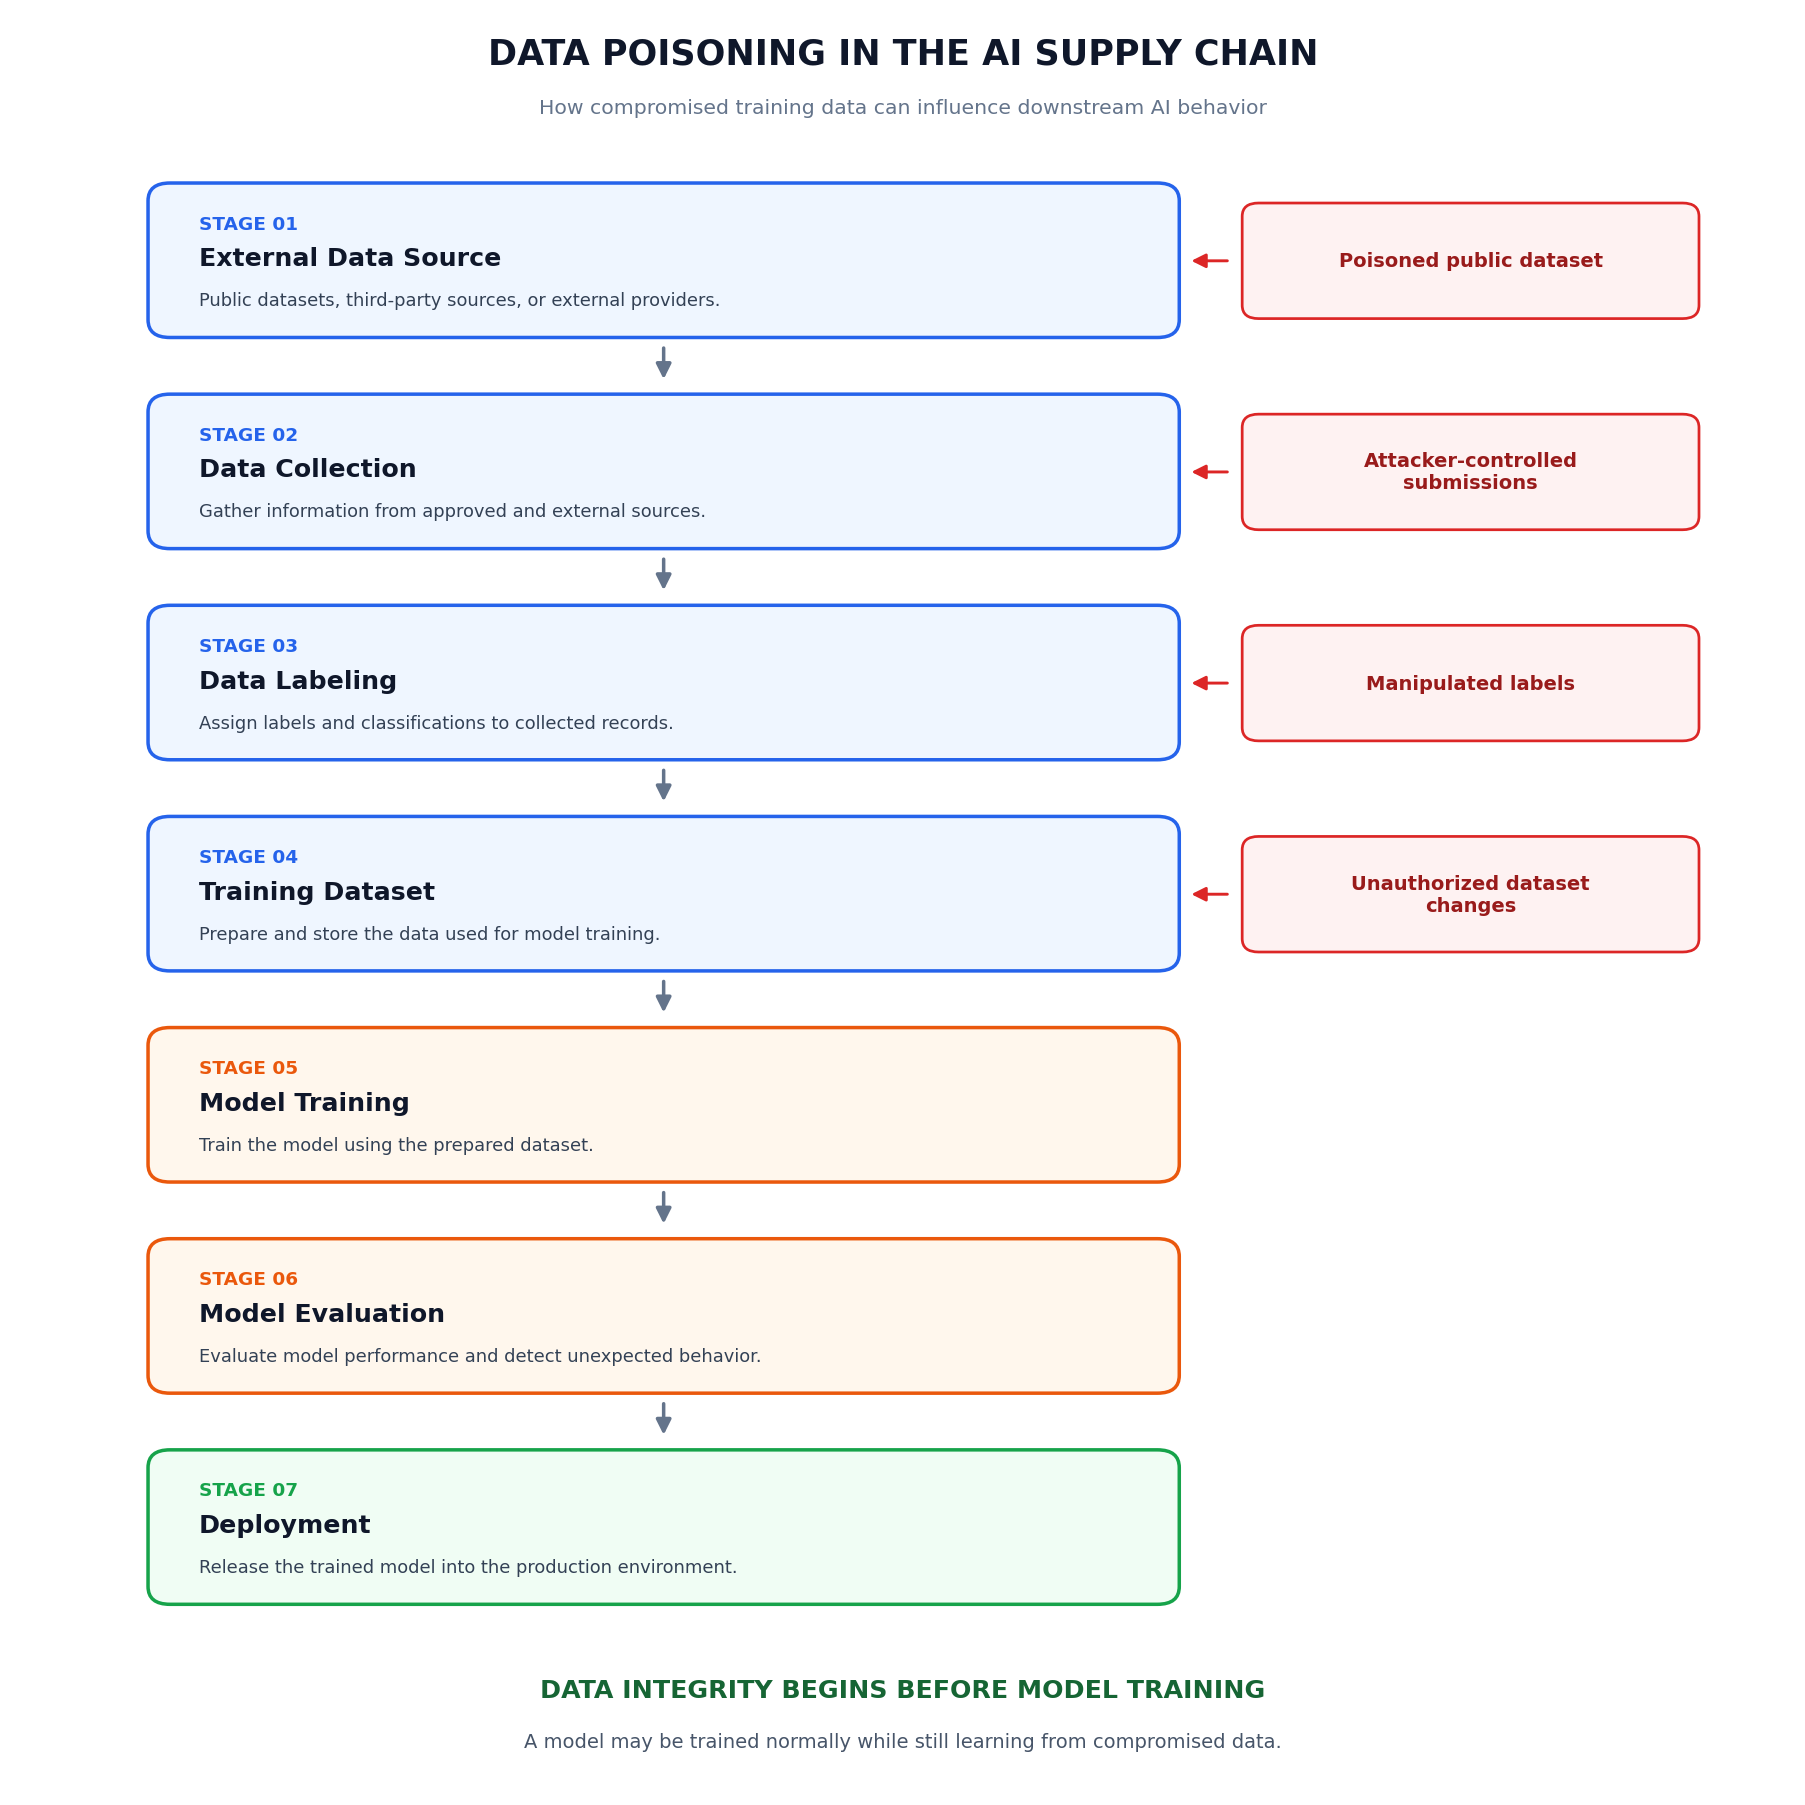

In [ ]:
# @title 2.9 — Data Poisoning in the AI Supply Chain { display-mode: "form" }

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64
import textwrap

# ============================================================
# WORKFLOW CONTENT
# ============================================================

steps = [
    ("01", "External Data Source",
     "Public datasets, third-party sources, or external providers."),

    ("02", "Data Collection",
     "Gather information from approved and external sources."),

    ("03", "Data Labeling",
     "Assign labels and classifications to collected records."),

    ("04", "Training Dataset",
     "Prepare and store the data used for model training."),

    ("05", "Model Training",
     "Train the model using the prepared dataset."),

    ("06", "Model Evaluation",
     "Evaluate model performance and detect unexpected behavior."),

    ("07", "Deployment",
     "Release the trained model into the production environment.")
]

# Potential attack entry points
attack_points = {
    0: "Poisoned public dataset",
    1: "Attacker-controlled submissions",
    2: "Manipulated labels",
    3: "Unauthorized dataset changes"
}

# Blue = Data acquisition and preparation
# Orange = Training and evaluation
# Green = Deployment

colors = [
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#EFF6FF", "#2563EB"),
    ("#FFF7ED", "#EA580C"),
    ("#FFF7ED", "#EA580C"),
    ("#F0FDF4", "#16A34A")
]

# ============================================================
# CREATE WORKFLOW DIAGRAM
# ============================================================

fig, ax = plt.subplots(figsize=(13, 13))
fig.patch.set_facecolor("white")

ax.set_xlim(0, 13)
ax.set_ylim(0, 16)
ax.axis("off")

ax.text(
    6.5, 15.55,
    "DATA POISONING IN THE AI SUPPLY CHAIN",
    ha="center",
    fontsize=18,
    fontweight="bold",
    color="#0F172A"
)

ax.text(
    6.5, 15.10,
    "How compromised training data can influence downstream AI behavior",
    ha="center",
    fontsize=10.5,
    color="#64748B"
)

# ============================================================
# DRAW PIPELINE
# ============================================================

card_x = 1.0
card_width = 7.5
card_height = 1.35
step_spacing = 1.90
first_y = 13.10

for i, (number, title, description) in enumerate(steps):

    y = first_y - i * step_spacing
    bg, accent = colors[i]

    card = FancyBboxPatch(
        (card_x, y),
        card_width,
        card_height,
        boxstyle="round,pad=0.02,rounding_size=0.16",
        facecolor=bg,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        card_x + 0.35,
        y + 0.96,
        f"STAGE {number}",
        fontsize=9.5,
        fontweight="bold",
        color=accent
    )

    ax.text(
        card_x + 0.35,
        y + 0.63,
        title,
        fontsize=13,
        fontweight="bold",
        color="#0F172A"
    )

    ax.text(
        card_x + 0.35,
        y + 0.27,
        description,
        fontsize=9.2,
        color="#334155"
    )

    # Pipeline arrows
    if i < len(steps) - 1:

        ax.add_patch(
            FancyArrowPatch(
                (4.75, y - 0.08),
                (4.75, y - 0.43),
                arrowstyle="-|>",
                mutation_scale=16,
                linewidth=1.8,
                color="#64748B"
            )
        )

    # ========================================================
    # ATTACK ENTRY POINTS
    # ========================================================

    if i in attack_points:

        attack_x = 9.0
        attack_width = 3.3

        attack_box = FancyBboxPatch(
            (attack_x, y + 0.17),
            attack_width,
            1.0,
            boxstyle="round,pad=0.02,rounding_size=0.12",
            facecolor="#FEF2F2",
            edgecolor="#DC2626",
            linewidth=1.4
        )

        ax.add_patch(attack_box)

        ax.text(
            attack_x + attack_width / 2,
            y + 0.67,
            "\n".join(textwrap.wrap(attack_points[i], 24)),
            ha="center",
            va="center",
            fontsize=10,
            fontweight="bold",
            color="#991B1B"
        )

        ax.add_patch(
            FancyArrowPatch(
                (attack_x - 0.10, y + 0.67),
                (card_x + card_width + 0.08, y + 0.67),
                arrowstyle="-|>",
                mutation_scale=15,
                linewidth=1.5,
                color="#DC2626"
            )
        )

# ============================================================
# FINAL TAKEAWAY
# ============================================================

ax.text(
    6.5,
    0.85,
    "DATA INTEGRITY BEGINS BEFORE MODEL TRAINING",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#166534"
)

ax.text(
    6.5,
    0.40,
    "A model may be trained normally while still learning from compromised data.",
    ha="center",
    fontsize=10,
    color="#475569"
)

plt.tight_layout()

# ============================================================
# CONVERT DIAGRAM TO EMBEDDED IMAGE
# ============================================================

buffer = BytesIO()

fig.savefig(
    buffer,
    format="png",
    dpi=140,
    bbox_inches="tight",
    facecolor="white"
)

plt.close(fig)

image_data = base64.b64encode(
    buffer.getvalue()
).decode("utf-8")

buffer.close()

# ============================================================
# DISPLAY COLLAPSIBLE WORKFLOW
# ============================================================

display(HTML(f"""
<details style="
    margin:12px 0;
    border:1px solid #bfdbfe;
    border-radius:10px;
    overflow:hidden;
">

    <summary style="
        cursor:pointer;
        font-size:16px;
        font-weight:bold;
        padding:16px;
        background:#eff6ff;
        color:#1e3a8a;
        border-left:5px solid #2563eb;
    ">
        2.9 — Data Poisoning in the AI Supply Chain — Click to Expand
    </summary>

    <div style="
        padding:15px;
        background:white;
        text-align:center;
    ">

        <img
            src="data:image/png;base64,{image_data}"
            style="
                width:100%;
                max-width:950px;
                height:auto;
            "
        >

        <div style="
            max-width:750px;
            margin:15px auto;
            padding:16px;
            background:#f8fafc;
            border-radius:8px;
            color:#334155;
            font-size:14px;
            line-height:1.7;
            text-align:left;
        ">

            Data poisoning can occur long before an AI model
            reaches production.

            <br><br>

            Attackers may introduce manipulated data through
            external datasets, collection systems, labeling
            services, or unauthorized dataset modifications.

            <br><br>

            In many cases, the training process itself may
            operate normally. The security failure occurred
            earlier in the supply chain.

            <br><br>

            <b>Data provenance</b> helps defenders understand
            where training data originated, how it was collected,
            who handled it, and what modifications occurred
            before training.

            <br><br>

            <b style="color:#2563eb;">
                The key takeaway: The integrity of an AI model
                depends partly on the integrity of the data
                entering its training process.
            </b>

        </div>

    </div>

</details>
"""))

In [ ]:
# @title ▶ Section 2 Checkpoint — Introduction to Data Poisoning { display-mode: "form" }

questions = [
    {
        "question": "1. What is the primary goal of a data poisoning attack?",
        "options": [
            "A. Physically damage the training computer",
            "B. Influence model behavior by manipulating information used during training",
            "C. Prevent users from accessing the model API",
            "D. Steal the model after deployment"
        ],
        "answer": "B"
    },
    {
        "question": "2. What is the main difference between targeted and untargeted poisoning?",
        "options": [
            "A. Targeted poisoning has a specific intended behavior or class, while untargeted poisoning generally attempts to reduce overall model reliability",
            "B. Targeted poisoning only works on images",
            "C. Untargeted poisoning occurs after deployment",
            "D. There is no difference"
        ],
        "answer": "A"
    },
    {
        "question": "3. A dataset contains 10,000 samples and an attacker poisons 1,000 of them. What is the poisoning rate?",
        "options": [
            "A. 1%",
            "B. 5%",
            "C. 10%",
            "D. 100%"
        ],
        "answer": "C"
    },
    {
        "question": "4. Why do we train a clean baseline model before evaluating a poisoning attack?",
        "options": [
            "A. To guarantee the attack will succeed",
            "B. To provide normal model behavior that can be compared with the poisoned model",
            "C. To remove the need for a test dataset",
            "D. To automatically detect poisoned samples"
        ],
        "answer": "B"
    },
    {
        "question": "5. Why might overall accuracy fail to reveal a successful targeted poisoning attack?",
        "options": [
            "A. Accuracy cannot be calculated for machine learning models",
            "B. The attack may strongly affect one target class while most other predictions remain correct",
            "C. Targeted attacks always increase accuracy",
            "D. Accuracy only measures training speed"
        ],
        "answer": "B"
    },
    {
        "question": "6. Which measurement could help reveal that one particular class is being affected by an attack?",
        "options": [
            "A. Class-specific recall",
            "B. Training time alone",
            "C. Dataset filename",
            "D. Number of code cells"
        ],
        "answer": "A"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 2 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready to continue.")
else:
    print("Consider reviewing Section 2 before continuing.")

print("=" * 55)

---

<details>

<summary><b>Section 3 — Label-Flipping Attacks — Click to Expand</b></summary>

<br>

In the previous section, you learned that data poisoning attempts to influence a model by manipulating the information used during training. One of the simplest ways to demonstrate this idea is through a **label-flipping attack**.

Labels tell a supervised machine learning model what each training example is supposed to represent. If those labels are intentionally changed, the model receives incorrect information during training.

This makes label flipping useful for understanding a fundamental principle of data poisoning:

> **The model does not know that the attacker changed the labels. It simply attempts to learn from the training information it receives.**

In this section, you will examine how label flipping works, how targeted and untargeted versions differ, how poisoning rate influences an attack, and what measurements can reveal that the model has been affected.

<br>

<details>

<summary><b>3.1 — Understanding Training Labels</b></summary>

<br>

Supervised machine learning depends on training examples that contain both an **input** and an expected **label**.

Consider a simple malware classifier.

A training dataset might contain:

    File A → Benign
    File B → Malicious
    File C → Benign
    File D → Malicious

The input contains information about the file, while the label tells the learning algorithm which category the file belongs to.

During training, the model attempts to discover patterns that connect the input features with these labels.

For example, after examining many samples, the model might learn that certain combinations of file characteristics are frequently associated with malicious software.

The relationship can be simplified as:

    Training Example
          ↓
    Input Features + Label
          ↓
      Model Training
          ↓
     Learned Pattern

The model assumes that the labels provided during training are trustworthy.

This assumption creates an opportunity for an attacker.

If the attacker can change some of those labels, the underlying input may remain exactly the same while the information describing what that input represents becomes incorrect.

</details>

<br>

<details>

<summary><b>3.2 — What Is a Label-Flipping Attack?</b></summary>

<br>

A **label-flipping attack** is a form of data poisoning in which an attacker changes the labels associated with selected training examples.

Suppose a malicious file originally appears in the dataset as:

    Malware Sample → Malicious

An attacker might change the label to:

    Malware Sample → Benign

The actual file has not changed.

Only the label has changed.

The training algorithm now receives misleading information. Characteristics that should have been associated with malicious software are instead presented as examples of benign software.

If this occurs repeatedly, the model may begin learning an incorrect relationship between those characteristics and the target class.

A simplified attack looks like:

    Original Training Sample

    Features X → Class A

              ↓
         Attacker

              ↓

    Poisoned Training Sample

    Features X → Class B

The attacker has changed the **meaning presented to the learning algorithm** without necessarily modifying the underlying features.

</details>

<br>

<details>

<summary><b>3.3 — Untargeted Label Flipping</b></summary>

<br>

Label flipping can be performed with different objectives.

An **untargeted label-flipping attack** attempts to broadly disrupt the model's ability to learn correct relationships from the training dataset.

Instead of focusing on one particular class, the attacker may flip labels across different parts of the dataset.

For a binary classifier, this might look like:

    Original                 Poisoned

    Benign    →              Malicious
    Malicious →              Benign
    Benign    →              Malicious
    Malicious →              Benign

As the number of incorrect labels increases, the relationship between the features and their correct classes becomes less reliable.

The learning algorithm is effectively receiving conflicting instructions.

Some examples tell the model:

> "These features represent benign behavior."

Other poisoned examples may tell it:

> "Those same kinds of features represent malicious behavior."

If enough training information is corrupted, the model may have difficulty learning a reliable decision boundary between the classes.

The attacker's objective in this case is generally broad degradation rather than one specific misclassification.

For this reason, measurements such as overall accuracy, balanced accuracy, precision, recall, and F1-score can help show whether model performance has degraded.

</details>

<br>

<details>

<summary><b>3.4 — Targeted Label Flipping</b></summary>

<br>

A **targeted label-flipping attack** is more selective.

Instead of attempting to damage the model across every class, the attacker chooses a particular **source class** and attempts to influence how the model handles that class.

For example:

    SOURCE CLASS = Malicious
    TARGET CLASS = Benign

The attacker selects some training samples belonging to the malicious class and changes their labels to benign.

The poisoned training information becomes:

    Malicious Sample → Benign Label

The attacker's goal is not necessarily to make the entire classifier fail.

Instead, the attacker may want the model to become less reliable when identifying malicious samples.

This creates an important security situation.

Suppose the clean model achieves:

    Overall Accuracy: 91%

After targeted poisoning:

    Overall Accuracy: 87%

At first glance, the model may still appear reasonably effective.

However, suppose we examine recall for the malicious class:

    Clean Malicious Recall:     93%

    Poisoned Malicious Recall:  58%

The overall accuracy decreased by only four percentage points, but the model became dramatically worse at detecting the class the attacker wanted to affect.

This is why targeted attacks require **target-specific evaluation**.

</details>

<br>

<details>

<summary><b>3.5 — Source Classes and Target Classes</b></summary>

<br>

When working with targeted poisoning, two terms become especially important: the **source class** and the **target class**.

The **source class** is the original class that the attacker wants to manipulate.

The **target class** is the class the attacker wants those poisoned examples to appear as during training.

Suppose a dataset contains handwritten digits from 0 through 9.

An attacker could define:

    SOURCE_CLASS = 1

    TARGET_CLASS = 0

The poisoning process would select some training examples that are actually the digit **1** and change their training labels to **0**.

Conceptually:

    Image of "1"
         ↓
    Correct Label = 1
         ↓
      Attacker
         ↓
    Poisoned Label = 0

The image itself can remain unchanged.

Only the label provided to the model is modified.

During training, the model is therefore shown images that visually resemble the digit 1 while being told that those examples belong to class 0.

The attacker hopes this causes the learned boundary between the two classes to become less reliable.

These terms will appear directly in the code used during the hands-on activities, so understanding them now will make the attack code easier to follow.

</details>

<br>

<details>

<summary><b>3.6 — Poisoning Rate and Attack Strength</b></summary>

<br>

The **poisoning rate** determines how much of the available training information is manipulated.

Suppose the source class contains 1,000 training examples.

At a poisoning rate of 10%:

    100 source-class examples are modified.

At a poisoning rate of 50%:

    500 source-class examples are modified.

A larger poisoning rate generally gives the attacker greater influence over the training data, but it may also make the attack easier to notice.

For example, defenders examining class distributions might discover that the number of samples belonging to one class suddenly decreased while another class increased.

Imagine the original dataset contains:

| Class | Before Attack |
|---|---:|
| Class 0 | 1,000 |
| Class 1 | 1,000 |

If 500 examples from Class 1 are relabeled as Class 0:

| Class | After Attack |
|---|---:|
| Class 0 | 1,500 |
| Class 1 | 500 |

That is a significant change in the class distribution.

The attacker therefore faces a tradeoff.

A higher poisoning rate may increase the influence of the attack, while a lower poisoning rate may be more difficult for defenders to notice.

During the hands-on labs, you will experiment with this value rather than treating the poisoning rate as a fixed number.

</details>

<br>

<details>

<summary><b>3.7 — What Happens During Model Training?</b></summary>

<br>

It is important to understand that the training algorithm does not recognize a poisoned label as an attack.

From the model's perspective, the poisoned example is simply another training record.

Suppose an image clearly contains the digit 1, but the attacker changes its training label to 0.

The model receives:

    Input: Image resembling "1"

    Expected Answer: "0"

During training, the optimization process attempts to adjust the model so that its prediction moves closer to the expected answer.

The problem is that the **expected answer was intentionally made incorrect by the attacker**.

If enough poisoned examples are introduced, the model repeatedly receives misleading feedback.

Conceptually:

    Real Pattern
        ↓
    Poisoned Label
        ↓
    Training Algorithm
        ↓
    Parameter Updates
        ↓
    Altered Decision Boundary

The model is not being "hacked" in the same way an attacker might exploit a traditional software vulnerability.

Instead, the attacker is manipulating the information used by the learning process.

That distinction is one of the most important ideas in adversarial machine learning.

</details>

<br>

<details>

<summary><b>3.8 — Measuring Whether the Attack Worked</b></summary>

<br>

After performing a label-flipping attack, we need to determine whether the attack actually changed model behavior.

The first comparison is usually between a **clean baseline model** and the **poisoned model**.

For example:

| Metric | Clean | Poisoned |
|---|---:|---:|
| Accuracy | 0.91 | 0.83 |
| Precision | 0.90 | 0.82 |
| Recall | 0.91 | 0.81 |
| F1 | 0.90 | 0.81 |

For an untargeted attack, broad decreases across these measurements may indicate that poisoning damaged the model's general performance.

For a targeted attack, we need to examine more specific behavior.

Useful measurements can include:

- Source-class recall
- Source-to-target misclassification rate
- Per-class precision and recall
- Confusion matrix
- Overall accuracy
- Balanced accuracy

Suppose the attacker flipped labels from Class 1 to Class 0.

A particularly important question becomes:

> **How often are real Class 1 examples now predicted as Class 0?**

If that rate increases significantly compared with the clean baseline, the targeted poisoning attack may be achieving its objective.

The **confusion matrix** is especially useful because it shows which classes are being confused with one another rather than reducing the model's behavior to a single number.

</details>

<br>

<details>

<summary><b>3.9 — Why Label Flipping Matters for Security</b></summary>

<br>

Label flipping may appear simple, but it demonstrates a realistic security problem: **training labels are part of the attack surface**.

Organizations may obtain labels from many sources. Some labels may be created internally, while others may come from contractors, crowdsourcing systems, automated processes, user feedback, or external datasets.

Possible attack points include:

- Compromised labeling accounts
- Malicious insiders
- Third-party labeling services
- Untrusted public datasets
- User-generated feedback
- Automated labeling pipelines
- Compromised dataset storage
- Weak access controls on training records

An attacker does not necessarily need to control the entire dataset.

If the attacker can influence enough important training records, they may be able to alter what the model learns.

This connects directly to the supply chain concepts from Section 1.

A model may be trained using trusted code on trusted infrastructure and deployed to a secure server. However, if the labels entering the training pipeline were manipulated, the resulting model may still be untrustworthy.

The security of the training process therefore depends on both the **data itself and the integrity of the labels describing that data**.

</details>

<br>

<details>

<summary><b>3.10 — What to Watch for in the Hands-On Labs</b></summary>

<br>

The upcoming hands-on activities will allow you to perform label-flipping attacks against a simplified machine learning system.

Do not focus only on getting the code to run.

Instead, pay attention to the relationship between the **attack configuration and the resulting model behavior**.

In particular, watch what happens when the poisoning rate changes. Compare the clean model with the poisoned model and determine whether the attack causes broad performance degradation or affects one class more strongly than others.

When examining the results, ask yourself:

- Did overall accuracy change?
- Did one class suffer more than the others?
- Did source-class recall decrease?
- Did source-to-target misclassification increase?
- What does the confusion matrix reveal?
- Would the attack be obvious if you only looked at overall accuracy?
- Would the poisoning be visible by examining the dataset?

These questions are more important than simply producing a particular accuracy value.

The purpose of the lab is to understand **how manipulated labels become altered model behavior**.

</details>

<br>

<details>

<summary><b>Section 3 — Key Takeaways</b></summary>

<br>

A label-flipping attack manipulates the labels associated with training examples. The underlying inputs may remain unchanged, but the learning algorithm is given incorrect information about what those inputs represent.

Untargeted label flipping generally attempts to disrupt overall model performance, while targeted label flipping focuses on a particular source class and attempts to influence how that class is handled.

For targeted attacks, the **source class** represents the class being manipulated and the **target class** represents the label the attacker wants the poisoned examples to receive.

The poisoning rate controls how much training information is manipulated. Increasing the rate may strengthen the attack, but large changes may also create warning signs that defenders could detect.

Most importantly, evaluating a poisoning attack requires more than looking at overall model accuracy. Targeted attacks may require class-specific recall, confusion matrices, and source-to-target misclassification measurements to reveal what actually happened.

The main idea to remember before beginning the hands-on activities is:

> **The model trusts the labels it receives during training. If an attacker can manipulate those labels, the model may learn exactly what the attacker wants it to learn.**

</details>

</details>

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

In this mini lab, you will perform a simple **label-flipping attack** against a machine learning classifier.

The goal is not to create a sophisticated or highly effective attack. Instead, this experiment is designed to show you exactly how changing training labels can influence what a model learns.

We will use the **Wine dataset**, a small dataset included with Scikit-learn. Because the dataset is small, the entire experiment should run very quickly. This allows you to change the attack settings and repeat the experiment several times.

The dataset contains three classes. For this experiment, the attacker will select samples belonging to one **source class** and change some of their labels to a **target class**.

For example:

    Original:

    Sample → Class 1

             ↓

        Label Flipping

             ↓

    Poisoned:

    Same Sample → Class 0

Notice that the features describing the sample are not changed. Only the label is modified.

You will first train a **clean baseline model**. This gives you a reference showing how the classifier behaves before the attack.

Next, you will copy the training labels and poison only the copy. This is important because it allows us to compare the clean and poisoned experiments fairly.

You will then retrain the same type of model using the poisoned labels.

Finally, you will compare the two models using overall accuracy and the confusion matrix.

When examining the results, do not focus only on whether the poisoned model has lower accuracy. Pay attention to **which classes are being confused**.

Try running the experiment several times while changing the poisoning rate.

For example, compare:

    POISON_RATE = 0.10

    POISON_RATE = 0.25

    POISON_RATE = 0.50

    POISON_RATE = 0.75

Ask yourself:

> **As more source-class labels are changed, how does the behavior of the model change?**

</details>

In [ ]:
# @title ▶ Part 1 — Load and Prepare the Dataset { display-mode: "form" }

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Load the built-in Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Scale the features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset ready!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Number of classes: {len(set(y))}")
print(f"Classes: {wine.target_names}")

Dataset ready!
Training samples: 124
Testing samples:  54
Number of classes: 3
Classes: ['class_0' 'class_1' 'class_2']


<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

This cell prepares the dataset that will be used throughout the experiment.

The **Wine dataset** contains numerical measurements describing different wine samples. Each sample belongs to one of three classes.

We divide the dataset into two parts.

The **training set** is the information the model is allowed to learn from. This is where the poisoning attack will occur.

The **test set** is kept separate and remains clean. We need a clean test set because we want to determine how a model trained on manipulated information behaves when it encounters legitimate examples.

The `stratify=y` option helps preserve approximately the same class distribution in the training and testing sets.

We also standardize the numerical features using `StandardScaler`. This places features with different numerical ranges onto comparable scales and helps the Logistic Regression model train reliably.

Most importantly:

> **We will poison the training labels, but we will not poison the test labels.**

This allows us to evaluate the effect of the attack against clean data.

</details>

In [ ]:
# @title ▶ Part 2 — Train the Clean Baseline { display-mode: "form" }

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Train using the original clean labels
clean_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

clean_model.fit(X_train, y_train)

# Test the model
clean_predictions = clean_model.predict(X_test)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

print("=== CLEAN BASELINE ===")
print(f"Accuracy: {clean_accuracy:.3f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, clean_predictions))

=== CLEAN BASELINE ===
Accuracy: 0.981

Confusion Matrix:
[[18  0  0]
 [ 1 20  0]
 [ 0  0 15]]


<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

Before performing the attack, we train a model using the original **clean training data**.

This creates our **baseline**.

A baseline is important because simply training a poisoned model and obtaining an accuracy score does not tell us how much damage the attack caused.

For example, suppose the poisoned model achieves 80% accuracy. Is that good or bad?

If the clean model achieved 82%, the attack had relatively little effect.

If the clean model achieved 98%, the same poisoned accuracy would represent a much larger change.

The confusion matrix provides additional information by showing which true classes are being predicted as which classes.

Save these results mentally because we will compare them with the poisoned model after the attack.

</details>

In [ ]:
# @title ▶ Part 3 — Configure and Run the Label-Flipping Attack { display-mode: "form" }

import numpy as np

# ==========================================
# STUDENT-EDITABLE ATTACK SETTINGS
# ==========================================

SOURCE_CLASS = 1
TARGET_CLASS = 0

POISON_RATE = 0.50

# ==========================================

# Always start with a fresh copy of the clean labels
y_poisoned = y_train.copy()

# Find training samples belonging to the source class
source_indices = np.where(y_train == SOURCE_CLASS)[0]

# Determine how many labels to poison
num_to_poison = int(
    len(source_indices) * POISON_RATE
)

# Make the experiment reproducible
rng = np.random.default_rng(42)

poison_indices = rng.choice(
    source_indices,
    size=num_to_poison,
    replace=False
)

# Flip source labels to the target class
y_poisoned[poison_indices] = TARGET_CLASS

print("=== LABEL-FLIPPING ATTACK ===")

print(f"\nSource Class: {SOURCE_CLASS}")
print(f"Target Class: {TARGET_CLASS}")
print(f"Poison Rate: {POISON_RATE:.0%}")

print(
    f"\nSource-class training samples: "
    f"{len(source_indices)}"
)

print(
    f"Labels flipped: "
    f"{num_to_poison}"
)

print("\nExample attack:")

print(
    f"Class {SOURCE_CLASS}"
    f"  →  "
    f"Class {TARGET_CLASS}"
)

=== LABEL-FLIPPING ATTACK ===

Source Class: 1
Target Class: 0
Poison Rate: 50%

Source-class training samples: 50
Labels flipped: 25

Example attack:
Class 1  →  Class 0


<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

This cell performs the actual **label-flipping attack**.

Three values control the attack.

`SOURCE_CLASS` identifies the class the attacker wants to manipulate.

`TARGET_CLASS` identifies the incorrect class that the attacker wants the selected training examples to receive.

`POISON_RATE` controls how much of the source-class training data is manipulated.

With:

    SOURCE_CLASS = 1
    TARGET_CLASS = 0
    POISON_RATE = 0.50

the attacker selects **50% of the Class 1 training samples** and changes their labels to Class 0.

The important part is that we do **not** modify `X_train`.

The features describing each sample remain exactly the same.

Only the labels change:

    Features from Class 1

            +

    Original Label = 1

            ↓

       Attacker

            ↓

    Features from Class 1

            +

    Poisoned Label = 0

This means the model will later see legitimate Class 1 characteristics while being told that those examples actually belong to Class 0.

Also notice this line:

    y_poisoned = y_train.copy()

Every time you run the attack cell, the experiment starts from the original clean labels.

This is important when experimenting with different poisoning rates. Otherwise, rerunning the cell could accidentally poison labels that had already been poisoned during a previous experiment.

</details>

In [ ]:
# @title ▶ Part 4 — Train the Poisoned Model { display-mode: "form" }

poisoned_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

# Same training features
# Different (poisoned) labels
poisoned_model.fit(
    X_train,
    y_poisoned
)

poisoned_predictions = poisoned_model.predict(
    X_test
)

poisoned_accuracy = accuracy_score(
    y_test,
    poisoned_predictions
)

print("=== POISONED MODEL ===")

print(
    f"Accuracy: "
    f"{poisoned_accuracy:.3f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        poisoned_predictions
    )
)

=== POISONED MODEL ===
Accuracy: 0.778

Confusion Matrix:
[[18  0  0]
 [12  9  0]
 [ 0  0 15]]


<details>

<summary><b>Part 4 Explanation — Click to Expand</b></summary>

<br>

Now we train a second Logistic Regression model.

The model architecture has not changed.

The test data has not changed.

The training features have not changed.

The major difference is:

    Clean Model
        ↓
    Original Labels

versus

    Poisoned Model
        ↓
    Manipulated Labels

This is important experimentally because it helps isolate the effect of the poisoning attack.

The model does not know which labels were changed by the attacker. It treats every training label as legitimate and attempts to learn from the poisoned dataset.

After training, we evaluate the model using the same **clean test set** that was used for the baseline.

Any major differences between the two models therefore provide evidence about how the poisoned training information influenced what the second model learned.

</details>

In [ ]:
# @title ▶ Part 5 — Compare Clean vs. Poisoned Models { display-mode: "form" }

from sklearn.metrics import recall_score

# Overall change
accuracy_change = (
    poisoned_accuracy - clean_accuracy
)

# Recall for the attacked source class
clean_source_recall = recall_score(
    y_test,
    clean_predictions,
    labels=[SOURCE_CLASS],
    average=None
)[0]

poisoned_source_recall = recall_score(
    y_test,
    poisoned_predictions,
    labels=[SOURCE_CLASS],
    average=None
)[0]

# How often true source-class samples become target class
source_test_indices = np.where(
    y_test == SOURCE_CLASS
)[0]

clean_target_rate = np.mean(
    clean_predictions[source_test_indices]
    == TARGET_CLASS
)

poisoned_target_rate = np.mean(
    poisoned_predictions[source_test_indices]
    == TARGET_CLASS
)

print("=" * 55)
print("CLEAN vs. POISONED")
print("=" * 55)

print(
    f"\nClean Accuracy:    "
    f"{clean_accuracy:.3f}"
)

print(
    f"Poisoned Accuracy: "
    f"{poisoned_accuracy:.3f}"
)

print(
    f"Accuracy Change:   "
    f"{accuracy_change:+.3f}"
)

print("\n--- Targeted Behavior ---")

print(
    f"\nClass {SOURCE_CLASS} Recall"
)

print(
    f"Clean:    "
    f"{clean_source_recall:.3f}"
)

print(
    f"Poisoned: "
    f"{poisoned_source_recall:.3f}"
)

print(
    f"\nClass {SOURCE_CLASS} → "
    f"Class {TARGET_CLASS} Misclassification"
)

print(
    f"Clean:    "
    f"{clean_target_rate:.3f}"
)

print(
    f"Poisoned: "
    f"{poisoned_target_rate:.3f}"
)

CLEAN vs. POISONED

Clean Accuracy:    0.981
Poisoned Accuracy: 0.778
Accuracy Change:   -0.204

--- Targeted Behavior ---

Class 1 Recall
Clean:    0.952
Poisoned: 0.429

Class 1 → Class 0 Misclassification
Clean:    0.048
Poisoned: 0.571


<details>

<summary><b>Part 5 Results — What Should You Look For? — Click to Expand</b></summary>

<br>

This final comparison is the most important part of the experiment.

It would be easy to look only at the two accuracy values:

    Clean Accuracy

    vs.

    Poisoned Accuracy

However, remember that our attacker selected a specific source class and target class.

The attack was:

    Class 1 → Class 0

Because the attack has a specific target, we should examine the model's behavior toward that target.

### Source-Class Recall

The first additional measurement is **source-class recall**.

This asks:

> **Of all the real Class 1 examples in the clean test set, how many can the model still correctly identify as Class 1?**

If Class 1 recall decreases after poisoning, the model has become worse at recognizing the class the attacker manipulated.

### Source-to-Target Misclassification

We also measure how often real Class 1 test examples are incorrectly predicted as Class 0.

This directly evaluates the behavior the attacker attempted to create:

    True Class 1
          ↓
    Model Prediction
          ↓
       Class 0

If this value increases after poisoning, the attack has moved the model toward the attacker's intended behavior.

### Experiment With the Attack

Now return to **Part 3** and change only:

    POISON_RATE

Try several values such as:

    0.10
    0.25
    0.50
    0.75

After changing the value, rerun:

    Part 3
      ↓
    Part 4
      ↓
    Part 5

The experiment is intentionally small so that you can repeat it quickly.

Do not expect every increase in poisoning rate to produce a perfectly predictable change. Machine learning behavior can vary depending on the dataset and decision boundary.

Instead, look for the overall relationship between:

    Poisoning Rate
          ↓
    Training Labels Changed
          ↓
    Model Learning Changes
          ↓
    Prediction Behavior Changes

The most important lesson is not that poisoning always reduces accuracy by a specific percentage.

The important lesson is:

> **Changing the information presented during training can change what the model learns, and targeted measurements may reveal effects that overall accuracy does not clearly show.**

</details>

In [ ]:
# @title ▶ Section 3 Checkpoint — Label-Flipping Attacks { display-mode: "form" }

questions = [
    {
        "question": "1. What did the label-flipping attack modify in the mini lab?",
        "options": [
            "A. The test features",
            "B. The training labels",
            "C. The model source code",
            "D. The test labels"
        ],
        "answer": "B"
    },
    {
        "question": "2. Why did we create y_poisoned as a copy of y_train?",
        "options": [
            "A. To preserve the original clean labels for comparison and repeated experiments",
            "B. To increase model accuracy",
            "C. To modify the test dataset",
            "D. To increase the number of training samples"
        ],
        "answer": "A"
    },
    {
        "question": "3. In the experiment, what does SOURCE_CLASS represent?",
        "options": [
            "A. The class the attacker wants to manipulate",
            "B. The class containing the most samples",
            "C. The model's predicted class",
            "D. The clean test class"
        ],
        "answer": "A"
    },
    {
        "question": "4. What does TARGET_CLASS represent?",
        "options": [
            "A. The class removed from the test set",
            "B. The incorrect label assigned to selected source-class training examples",
            "C. The class with the highest accuracy",
            "D. The original correct label"
        ],
        "answer": "B"
    },
    {
        "question": "5. What does increasing POISON_RATE do?",
        "options": [
            "A. Changes more selected source-class training labels",
            "B. Adds more features to the dataset",
            "C. Changes the test labels",
            "D. Changes the machine learning algorithm"
        ],
        "answer": "A"
    },
    {
        "question": "6. Why did the test labels remain clean?",
        "options": [
            "A. So the poisoned model could be evaluated against legitimate examples",
            "B. Because test labels cannot be modified",
            "C. To make the attack stronger",
            "D. To reduce training time"
        ],
        "answer": "A"
    },
    {
        "question": "7. Why is source-class recall useful when evaluating this attack?",
        "options": [
            "A. It measures how quickly the model trained",
            "B. It shows how well the model still recognizes the class the attacker manipulated",
            "C. It determines how many features exist",
            "D. It automatically removes poisoned samples"
        ],
        "answer": "B"
    },
    {
        "question": "8. The poisoned model still has high overall accuracy, but source-class recall drops significantly. What does this suggest?",
        "options": [
            "A. The attack definitely failed",
            "B. The model became more secure",
            "C. The attack may have successfully affected its target even though overall performance still looks strong",
            "D. The dataset was not poisoned"
        ],
        "answer": "C"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 3 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready to continue.")
else:
    print("Consider reviewing Section 3 and rerunning the mini lab.")

print("=" * 55)

<details>

<summary><b>Section 3 — Practical Takeaways — Click to Expand</b></summary>

<br>

In this section, you moved from learning about data poisoning conceptually to actually performing a simple poisoning attack.

The label-flipping experiment demonstrated that an attacker does not necessarily need to modify a model directly. By changing the **labels used during training**, the attacker can change the information the model learns from.

You also saw why establishing a **clean baseline** is important. Without the clean model, it would be difficult to determine how much of the poisoned model's behavior was actually caused by the attack.

The experiment also introduced three variables that will continue to appear throughout this module:

- **Source Class** — The class the attacker wants to manipulate.
- **Target Class** — The class the attacker wants selected examples to be associated with.
- **Poisoning Rate** — The amount of relevant training data affected by the attack.

Most importantly, you should not judge the success of a targeted poisoning attack using overall accuracy alone.

A poisoned model may continue making most predictions correctly while becoming significantly worse at recognizing the specific class targeted by the attacker. Measurements such as **source-class recall, source-to-target misclassification, and confusion matrices** can reveal behavior that a single accuracy score may hide.

The main lesson from the experiment is:

> **Changing a relatively small part of the information used during training can influence what a machine learning model learns, and the effects of that manipulation may not always be obvious from overall model performance.**

As you continue through the module, the poisoning techniques will become more subtle. Instead of simply changing labels, you will see how attackers can manipulate training data in ways that may be much more difficult for defenders to recognize.

</details>

---

<details>

<summary><b>Section 4 — Clean-Label Poisoning — Click to Expand</b></summary>

<br>

In Section 3, you performed a label-flipping attack by deliberately changing the labels associated with selected training examples. This demonstrated how an attacker can influence what a model learns by providing incorrect information during training.

However, label flipping has an important weakness from an attacker's perspective: **the incorrect labels may be detectable**.

If defenders inspect the training dataset and discover that an obvious image of the digit 1 has been labeled as 0, they have a strong indication that something is wrong.

More sophisticated poisoning attacks attempt to avoid creating such obvious inconsistencies.

One example is **clean-label poisoning**.

In a clean-label poisoning attack, the attacker manipulates the training examples while keeping their labels consistent with what a human reviewer would reasonably expect. Instead of attacking the label, the attacker changes the **input itself** in a way intended to influence the model's learning process.

This creates a more difficult security problem because a poisoned sample can potentially pass a basic inspection of the dataset.

<br>

<details>

<summary><b>4.1 — From Label Flipping to Clean-Label Poisoning</b></summary>

<br>

To understand why clean-label poisoning matters, first consider the label-flipping attack from Section 3.

Suppose the training dataset contains an image of the digit 1:

    Image: "1"

    Correct Label: 1

A label-flipping attacker changes the training record to:

    Image: "1"

    Poisoned Label: 0

The model receives incorrect information, but a human reviewing the record could potentially recognize the problem immediately.

The image clearly looks like a 1 while the dataset claims it is a 0.

Clean-label poisoning attempts to avoid this obvious mismatch.

Instead of changing:

    Label 1 → Label 0

the attacker modifies the **features of the training example** while leaving the label unchanged.

Conceptually:

    Original Sample
          ↓
    Modify Features
          ↓
    Poisoned Sample
          ↓
    Keep Original Label
          ↓
      Model Training

The resulting training example may still appear consistent with its assigned class even though it has been intentionally manipulated.

This makes the poisoning more difficult to detect through simple label inspection.

</details>

<br>

<details>

<summary><b>4.2 — What Makes an Attack "Clean-Label"?</b></summary>

<br>

The term **clean-label** refers to the fact that the label attached to the poisoned example remains plausible or correct.

Imagine an image classifier containing pictures of cats and dogs.

A traditional label-flipping attack might take an obvious picture of a cat and change:

    Cat Image → Dog Label

A reviewer examining the dataset may notice that the label does not match the image.

A clean-label attack instead keeps:

    Cat Image → Cat Label

but subtly modifies the image itself.

The modified image should ideally remain recognizable as a cat to a human while containing changes intended to influence what the machine learning model learns from the sample.

The attacker is therefore attempting to satisfy two objectives at the same time:

1. The poisoned example should still appear legitimate.
2. The poisoned example should influence model behavior.

This makes clean-label poisoning more subtle than straightforward label manipulation.

The defender cannot simply ask:

> **"Does the label match what this example appears to be?"**

The answer may be yes even though the sample was intentionally manipulated.

</details>

<br>

<details>

<summary><b>4.3 — Manipulating Features Instead of Labels</b></summary>

<br>

Machine learning models do not interpret training examples in exactly the same way humans do.

A human looking at an image may recognize an object based on its overall shape and appearance. A machine learning model processes numerical features and learns statistical relationships between those features and the provided labels.

This difference can create opportunities for an attacker.

Suppose a training sample belongs to **Class A**.

The attacker keeps:

    Label = Class A

but modifies some of the sample's features so that its numerical representation moves closer to examples associated with **Class B**.

Conceptually:

    Normal Class A Sample

             ↓

      Modify Features

             ↓

    Still Labeled Class A

             ↓

    Feature Representation Moves
    Toward Another Region

             ↓

       Model Retraining

The model is now being asked to learn that this modified feature pattern still belongs to Class A.

If carefully selected samples are manipulated, these changes may influence the decision boundary learned by the model.

This is different from label flipping.

With label flipping:

    Features remain the same
    Label changes

With clean-label poisoning:

    Features change
    Label remains the same

Understanding this distinction is essential before performing the hands-on experiment.

</details>

<br>

<details>

<summary><b>4.4 — Feature Space and Decision Boundaries</b></summary>

<br>

To understand how clean-label poisoning can influence a model, it helps to think about **feature space**.

Machine learning models represent each sample using numerical features.

Imagine a dataset containing only two features:

    Feature 2
        ↑
        |
    A A A
     A A
        |
        |           B B
        |         B B B
        +----------------→ Feature 1

Samples belonging to Class A tend to occupy one region, while samples belonging to Class B occupy another.

A classifier attempts to learn a **decision boundary** separating these regions.

Conceptually:

    A A A
     A A
          \
           \  ← Decision Boundary
            \
             B B
            B B B

Now imagine that an attacker modifies selected Class A training samples so that their features move closer to the region occupied by Class B.

The labels still say:

    Class A

but the feature representation has shifted.

The model must now account for these unusual Class A examples when learning its decision boundary.

The attacker's goal is to influence that boundary enough that certain future examples become more difficult for the model to classify correctly.

This is one reason clean-label poisoning can be effective without changing labels.

</details>

<br>

<details>

<summary><b>4.5 — Why Would an Attacker Use Clean-Label Poisoning?</b></summary>

<br>

The primary advantage of clean-label poisoning is **stealth**.

Simple defenses against training-data poisoning may involve searching for incorrect labels or manually reviewing suspicious records.

That approach may work reasonably well against obvious label flipping.

For example:

    Image clearly shows "7"
    Label says "2"

A reviewer could flag the record.

Clean-label poisoning makes this type of inspection less effective because the label may still appear reasonable.

Possible attacker objectives include influencing a particular decision boundary, reducing the model's ability to correctly recognize selected inputs, or creating targeted errors while keeping most model behavior unchanged.

The attacker generally wants to create enough influence to affect the model while avoiding obvious signs that the training dataset has been manipulated.

This creates a recurring tradeoff in poisoning attacks:

    Stronger Manipulation
            ↕
         Stealth

Very aggressive modifications may influence the model more strongly, but they may also make poisoned samples easier to detect.

Small modifications may be more difficult to notice, but they may have less influence on training.

</details>

<br>

<details>

<summary><b>4.6 — Clean-Label Poisoning and Targeted Attacks</b></summary>

<br>

Clean-label poisoning is particularly interesting when the attacker has a **specific target**.

Instead of attempting to reduce the accuracy of the entire model, the attacker may want to influence how the model handles one particular class or group of inputs.

For example, suppose the attacker wants a model to have difficulty recognizing examples from Class 1.

The attacker could manipulate selected training examples while retaining their legitimate labels.

The objective might be represented as:

    Selected Training Samples
              ↓
       Feature Manipulation
              ↓
       Labels Stay Correct
              ↓
         Model Training
              ↓
    Decision Boundary Changes
              ↓
    Target Behavior Degrades

If successful, the resulting model may still perform well on most of the test dataset.

This creates the same evaluation challenge introduced in Section 3.

A model could maintain strong **overall accuracy** while performing significantly worse on the attacker's target.

For this reason, evaluating clean-label poisoning may require examining:

- Overall accuracy
- Target-class recall
- Per-class performance
- Confusion matrices
- Targeted misclassification behavior

The success of the attack should be measured against the attacker's objective rather than using only one overall performance number.

</details>

<br>

<details>

<summary><b>4.7 — Why Clean-Label Poisoning Can Be Difficult to Detect</b></summary>

<br>

Label-flipping attacks create a direct inconsistency between the input and its assigned label.

Clean-label poisoning removes that obvious warning sign.

Consider these two records:

    Sample A → Class A

    Sample B → Class A

Both labels may appear completely reasonable.

However, Sample B may have been intentionally modified before entering the training dataset.

This means a defender may need to examine more than the label itself.

Possible indicators could include:

- Unusual feature values
- Samples that are statistical outliers
- Unexpected clusters within a class
- Suspicious similarity between examples
- Sudden changes in feature distributions
- Differences between trusted and newly collected data
- Unusual model behavior associated with particular samples

None of these automatically proves that poisoning occurred.

Legitimate datasets naturally contain unusual examples, noise, and variation.

This makes the defender's job more difficult. Removing every unusual sample could eliminate valuable legitimate training data, while ignoring unusual samples could allow poisoned data to remain.

Later in the module, you will examine defensive techniques designed to identify suspicious training samples.

</details>

<br>

<details>

<summary><b>4.8 — Data Provenance Becomes More Important</b></summary>

<br>

Clean-label poisoning demonstrates why **data provenance** is important for AI security.

Data provenance describes information about where data came from and what happened to it before it reached the training pipeline.

For an important training dataset, defenders may want to understand:

- Where the sample originated
- When it was collected
- Who or what created its label
- Whether the sample was modified
- Which system processed it
- Whether its integrity was verified
- Whether it came from a trusted source

Imagine that two training samples appear almost identical during inspection.

One came from a verified internal data collection system.

The other came from an unknown external contributor shortly before model retraining.

The provenance information provides security context that the raw sample alone does not provide.

This becomes increasingly important as poisoning attacks become more subtle.

When defenders cannot easily identify malicious data based on appearance or labels, understanding the **history and origin of the data** becomes another layer of defense.

</details>

<br>

<details>

<summary><b>4.9 — Evaluating a Clean-Label Attack</b></summary>

<br>

When performing the upcoming mini lab, we need a clear way to determine whether the attack actually had the intended effect.

We will first train a **clean baseline model**.

The baseline establishes how the model behaves before any training samples are manipulated.

We will then create a poisoned copy of the training data, modify selected features while keeping their labels unchanged, and train another model using that poisoned dataset.

The comparison becomes:

    Clean Training Data
            ↓
       Clean Model
            ↓
      Baseline Results

            VS.

    Modified Training Data
    Labels Remain Correct
            ↓
      Poisoned Model
            ↓
       Attack Results

The attack should not be considered successful merely because the code executed.

We need to compare the resulting model against the clean baseline.

For the hands-on experiment, we will pay particular attention to the performance of the **class targeted by the attack**.

If the attack is behaving as intended, the poisoned model should perform worse on the relevant attack metric than the clean baseline.

For example:

    Clean Target Recall:     0.90

    Poisoned Target Recall:  0.70

This provides clearer evidence of attack impact than simply assuming that changing the training data must have harmed the model.

If the expected degradation does not occur, the experiment should report that the attack effect was not demonstrated rather than incorrectly claiming that the attack succeeded.

</details>

<br>

<details>

<summary><b>4.10 — What to Watch for in the Mini Lab</b></summary>

<br>

The upcoming mini lab will intentionally use a small dataset and a fast machine learning model so that you can repeat the experiment several times.

You will begin with clean training data and establish a baseline.

Next, you will manipulate the **features** of selected training samples while keeping their labels unchanged.

Pay close attention to the difference from Section 3:

    SECTION 3 — LABEL FLIPPING

    Features: unchanged
    Labels:   changed


    SECTION 4 — CLEAN-LABEL POISONING

    Features: changed
    Labels:   unchanged

You will then train another model using the poisoned dataset and compare its behavior with the clean baseline.

The experiment will include adjustable attack settings so that you can observe how changing the amount or strength of the poisoning influences the result.

When examining the output, focus on whether the attacked model actually performs worse on the metric associated with the attacker's objective.

The goal is not simply to produce a different number.

The goal is to understand the relationship:

    Feature Manipulation
            ↓
    Poisoned Training Data
            ↓
      Changed Learning
            ↓
     Changed Predictions

This will demonstrate why checking labels alone is not enough to determine whether a training dataset can be trusted.

</details>

<br>

<details>

<summary><b>Section 4 — Key Takeaways</b></summary>

<br>

Clean-label poisoning is a data poisoning technique in which the attacker manipulates training examples while keeping their labels plausible or correct.

This differs from the label-flipping attack you performed in Section 3.

    Label Flipping:
    Features stay the same → Labels change

    Clean-Label Poisoning:
    Features change → Labels stay the same

Because the labels remain valid, basic label inspection may fail to reveal the poisoned samples.

The attacker attempts to influence how the model learns from the modified features while maintaining enough similarity to legitimate data that the poisoned examples are difficult to identify.

This makes concepts such as **feature distributions, outliers, data provenance, class-specific performance, and decision boundaries** increasingly important for defenders.

The most important lesson from this section is:

> **Correct labels do not guarantee trustworthy training data. An attacker may manipulate what the model learns without changing the labels at all.**

In the upcoming mini lab, you will perform a simplified clean-label poisoning experiment and directly compare the resulting model against a clean baseline.

</details>

</details>


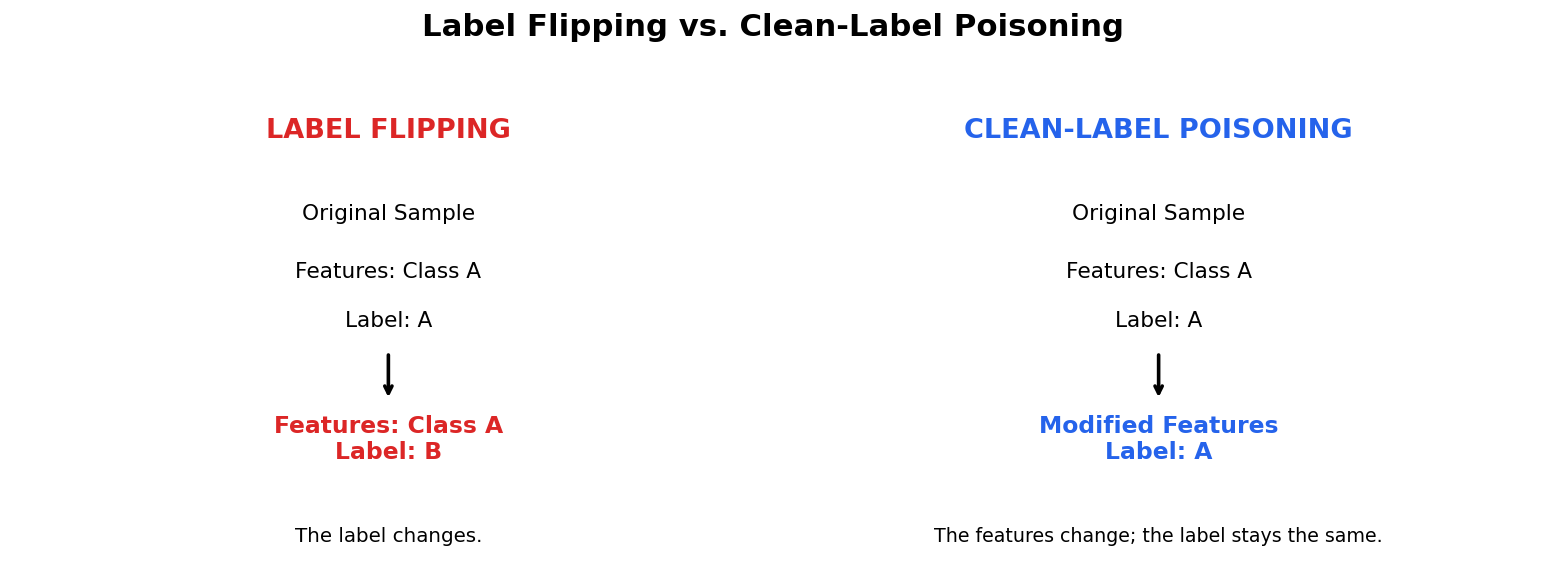


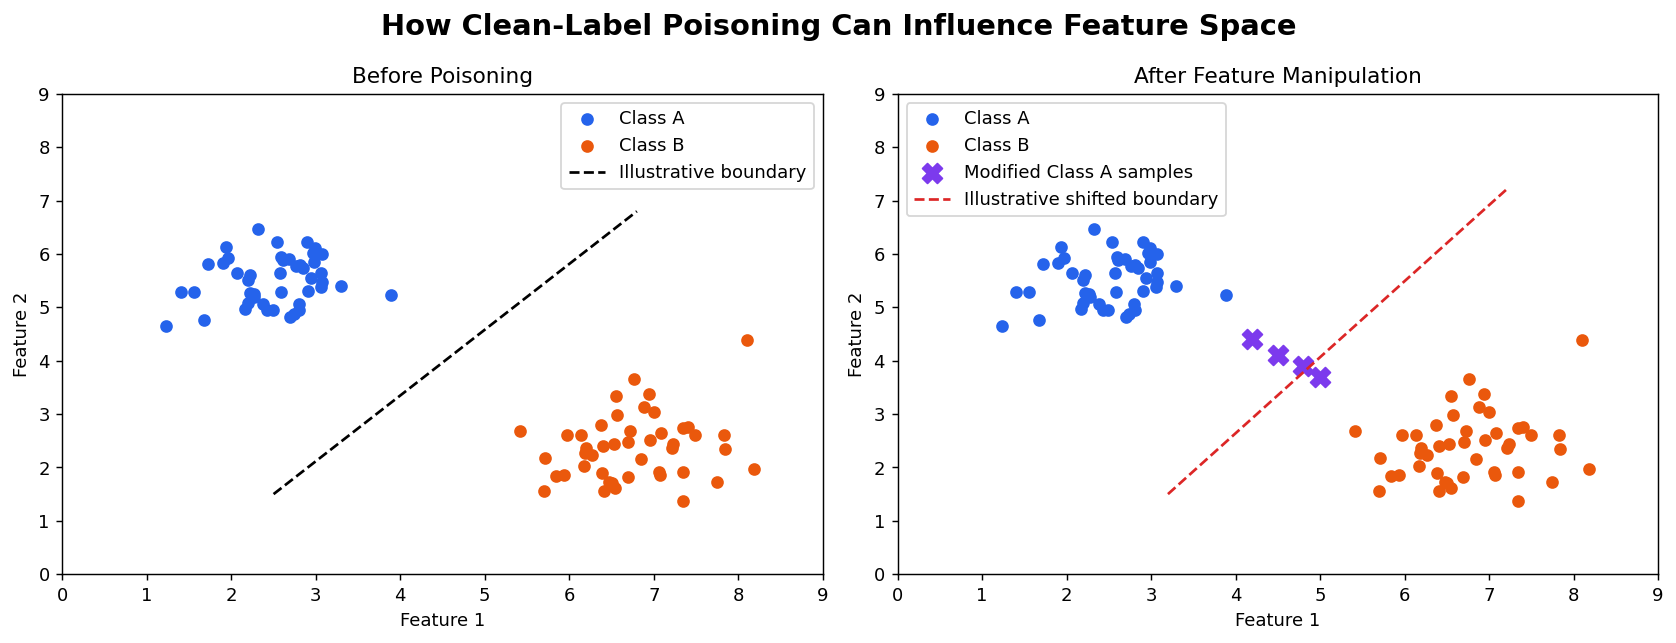


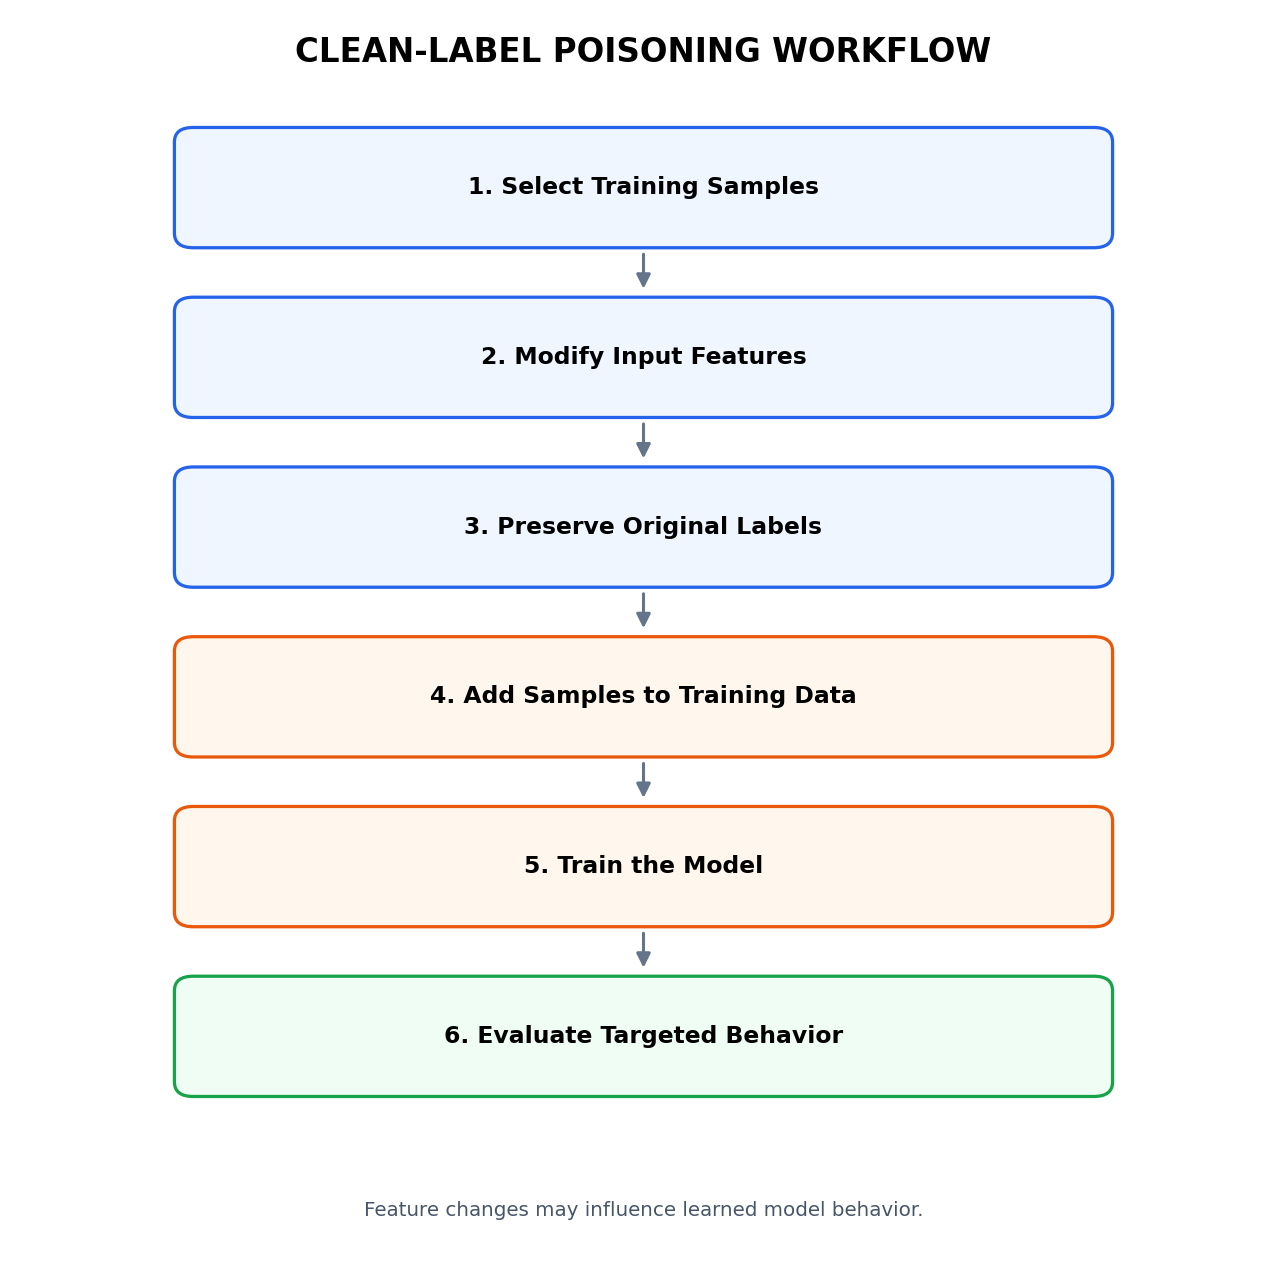


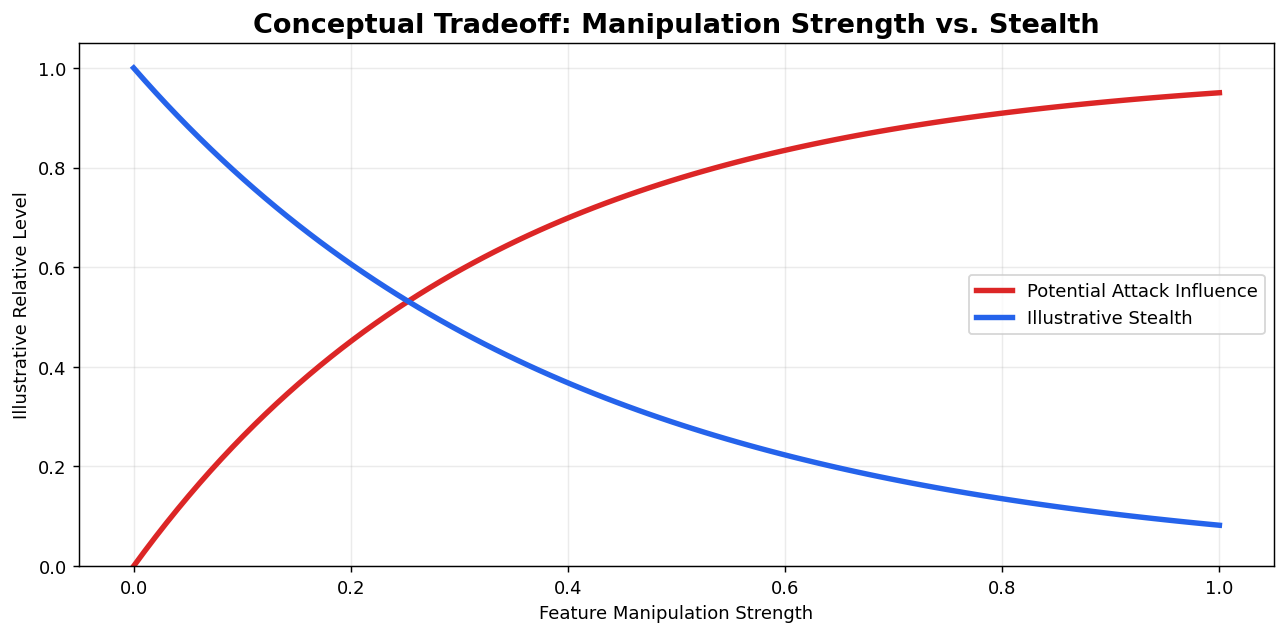


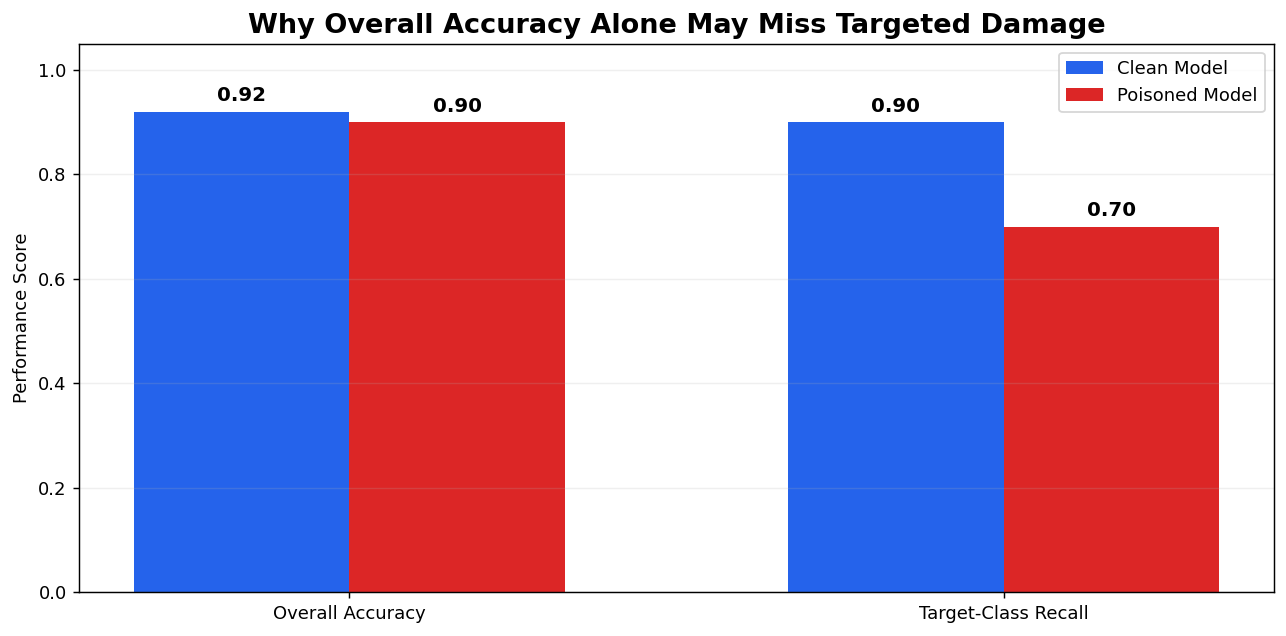

Section 4 visualizations ready.
Expand any diagram above to review its explanation.


In [ ]:
# @title Section 4 — Clean-Label Poisoning Visualizations { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64

# ============================================================
# DISPLAY HELPER
# ============================================================

def show_collapsible_figure(title, fig, explanation, color="#2563EB"):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=130,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    image_data = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    buffer.close()

    display(HTML(f"""
    <details style="
        margin:12px 0;
        border:1px solid #cbd5e1;
        border-radius:10px;
        overflow:hidden;
    ">

        <summary style="
            cursor:pointer;
            padding:15px;
            font-size:16px;
            font-weight:bold;
            background:#eff6ff;
            border-left:5px solid {color};
            color:#1e3a8a;
        ">
            {title} — Click to Expand
        </summary>

        <div style="
            padding:15px;
            background:white;
            text-align:center;
        ">

            <img
                src="data:image/png;base64,{image_data}"
                style="max-width:100%; height:auto;"
            >

            <div style="
                margin:15px auto;
                max-width:850px;
                padding:15px;
                background:#f8fafc;
                border-radius:8px;
                color:#334155;
                text-align:left;
                line-height:1.7;
                font-size:14px;
            ">
                {explanation}
            </div>

        </div>
    </details>
    """))


# ============================================================
# GRAPHIC 1 — LABEL FLIPPING VS CLEAN-LABEL POISONING
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

fig.suptitle(
    "Label Flipping vs. Clean-Label Poisoning",
    fontsize=17,
    fontweight="bold"
)

# Label flipping
ax = axes[0]

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

ax.text(
    5, 5.2,
    "LABEL FLIPPING",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#DC2626"
)

ax.text(5, 4.2, "Original Sample", ha="center", fontsize=12)
ax.text(5, 3.5, "Features: Class A", ha="center", fontsize=12)
ax.text(5, 2.9, "Label: A", ha="center", fontsize=12)

ax.annotate(
    "",
    xy=(5, 2.0),
    xytext=(5, 2.6),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(
    5, 1.3,
    "Features: Class A\nLabel: B",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#DC2626"
)

ax.text(
    5, 0.3,
    "The label changes.",
    ha="center",
    fontsize=11
)

# Clean-label
ax = axes[1]

ax.set_xlim(0, 10)
ax.set_ylim(0, 6)
ax.axis("off")

ax.text(
    5, 5.2,
    "CLEAN-LABEL POISONING",
    ha="center",
    fontsize=15,
    fontweight="bold",
    color="#2563EB"
)

ax.text(5, 4.2, "Original Sample", ha="center", fontsize=12)
ax.text(5, 3.5, "Features: Class A", ha="center", fontsize=12)
ax.text(5, 2.9, "Label: A", ha="center", fontsize=12)

ax.annotate(
    "",
    xy=(5, 2.0),
    xytext=(5, 2.6),
    arrowprops=dict(arrowstyle="->", lw=2)
)

ax.text(
    5, 1.3,
    "Modified Features\nLabel: A",
    ha="center",
    fontsize=13,
    fontweight="bold",
    color="#2563EB"
)

ax.text(
    5, 0.3,
    "The features change; the label stays the same.",
    ha="center",
    fontsize=10.5
)

plt.tight_layout()

show_collapsible_figure(
    "4.1–4.3 — Label Flipping vs. Clean-Label Poisoning",
    fig,
    """
    Label flipping changes the assigned class while leaving
    the input unchanged.

    <br><br>

    Clean-label poisoning modifies the input features while
    preserving the legitimate label.

    <br><br>

    This makes clean-label poisoning more difficult to detect
    through basic label inspection.
    """
)


# ============================================================
# GRAPHIC 2 — FEATURE SPACE AND DECISION BOUNDARIES
# ============================================================

rng = np.random.default_rng(42)

class_a = rng.normal(
    loc=[2.5, 5.5],
    scale=[0.65, 0.65],
    size=(45, 2)
)

class_b = rng.normal(
    loc=[6.8, 2.5],
    scale=[0.65, 0.65],
    size=(45, 2)
)

poisoned = np.array([
    [4.2, 4.4],
    [4.5, 4.1],
    [4.8, 3.9],
    [5.0, 3.7]
])

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "How Clean-Label Poisoning Can Influence Feature Space",
    fontsize=16,
    fontweight="bold"
)

# Before poisoning
ax = axes[0]

ax.scatter(
    class_a[:, 0],
    class_a[:, 1],
    color="#2563EB",
    label="Class A"
)

ax.scatter(
    class_b[:, 0],
    class_b[:, 1],
    color="#EA580C",
    label="Class B"
)

ax.plot(
    [2.5, 6.8],
    [1.5, 6.8],
    "--",
    color="black",
    label="Illustrative boundary"
)

ax.set_title("Before Poisoning")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.legend()

# After poisoning
ax = axes[1]

ax.scatter(
    class_a[:, 0],
    class_a[:, 1],
    color="#2563EB",
    label="Class A"
)

ax.scatter(
    class_b[:, 0],
    class_b[:, 1],
    color="#EA580C",
    label="Class B"
)

ax.scatter(
    poisoned[:, 0],
    poisoned[:, 1],
    color="#7C3AED",
    marker="X",
    s=120,
    label="Modified Class A samples"
)

ax.plot(
    [3.2, 7.2],
    [1.5, 7.2],
    "--",
    color="#DC2626",
    label="Illustrative shifted boundary"
)

ax.set_title("After Feature Manipulation")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.legend()

plt.tight_layout()

show_collapsible_figure(
    "4.4 — Feature Space and Decision Boundaries",
    fig,
    """
    Class A and Class B occupy different regions of feature space.

    <br><br>

    The purple X markers represent Class A samples whose
    features have been modified toward another region.

    Their labels remain Class A.

    <br><br>

    The dashed boundaries are conceptual illustrations,
    not boundaries calculated from trained models.

    <br><br>

    In a real attack, modified samples may influence
    the decision boundary learned during retraining,
    but the outcome is not guaranteed.
    """
)


# ============================================================
# GRAPHIC 3 — CLEAN-LABEL POISONING WORKFLOW
# ============================================================

workflow = [
    "Select Training Samples",
    "Modify Input Features",
    "Preserve Original Labels",
    "Add Samples to Training Data",
    "Train the Model",
    "Evaluate Targeted Behavior"
]

fig, ax = plt.subplots(figsize=(10, 10))

ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis("off")

ax.text(
    5, 12.5,
    "CLEAN-LABEL POISONING WORKFLOW",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

for i, title in enumerate(workflow):

    y = 10.6 - i * 1.75

    if i < 3:
        bg, accent = "#EFF6FF", "#2563EB"
    elif i < 5:
        bg, accent = "#FFF7ED", "#EA580C"
    else:
        bg, accent = "#F0FDF4", "#16A34A"

    card = FancyBboxPatch(
        (1.3, y),
        7.4,
        1.2,
        boxstyle="round,pad=0.02,rounding_size=0.15",
        facecolor=bg,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        5,
        y + 0.6,
        f"{i+1}. {title}",
        ha="center",
        va="center",
        fontsize=13,
        fontweight="bold"
    )

    if i < len(workflow) - 1:

        ax.add_patch(
            FancyArrowPatch(
                (5, y - 0.05),
                (5, y - 0.48),
                arrowstyle="-|>",
                mutation_scale=16,
                linewidth=1.7,
                color="#64748B"
            )
        )

ax.text(
    5,
    0.6,
    "Feature changes may influence learned model behavior.",
    ha="center",
    fontsize=11,
    color="#475569"
)

plt.tight_layout()

show_collapsible_figure(
    "4.3 & 4.6 — Clean-Label Poisoning Process",
    fig,
    """
    The attacker selects training samples and modifies
    their features while preserving their original labels.

    <br><br>

    The modified samples are included in training data.

    <br><br>

    After retraining, defenders compare the resulting
    model against a clean baseline to determine whether
    the manipulation had the intended effect.
    """
)


# ============================================================
# GRAPHIC 4 — STEALTH VS ATTACK STRENGTH
# ============================================================

strength = np.linspace(0, 1, 100)

# Illustrative relationships only
potential_influence = 1 - np.exp(-3 * strength)
stealth = np.exp(-2.5 * strength)

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    strength,
    potential_influence,
    linewidth=3,
    color="#DC2626",
    label="Potential Attack Influence"
)

ax.plot(
    strength,
    stealth,
    linewidth=3,
    color="#2563EB",
    label="Illustrative Stealth"
)

ax.set_title(
    "Conceptual Tradeoff: Manipulation Strength vs. Stealth",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Feature Manipulation Strength")
ax.set_ylabel("Illustrative Relative Level")

ax.set_ylim(0, 1.05)
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()

show_collapsible_figure(
    "4.5 & 4.7 — Stealth vs. Manipulation Strength",
    fig,
    """
    Attackers may face a tradeoff between manipulating
    samples strongly enough to influence learning and
    keeping those changes difficult to detect.

    <br><br>

    Stronger manipulation can sometimes increase attack
    influence while making modified samples more noticeable.

    <br><br>

    These curves are conceptual, not measured experimental
    results. Actual attack success and detectability depend
    on the dataset, model, and poisoning method.
    """
)


# ============================================================
# GRAPHIC 5 — EVALUATING CLEAN-LABEL ATTACK EFFECTIVENESS
# ============================================================

# Example values from the section reading.
# These are illustrative, not measured results.

metrics = [
    "Overall Accuracy",
    "Target-Class Recall"
]

clean_results = [0.92, 0.90]
poisoned_results = [0.90, 0.70]

x = np.arange(len(metrics))
width = 0.33

fig, ax = plt.subplots(figsize=(10, 5))

bars1 = ax.bar(
    x - width / 2,
    clean_results,
    width,
    label="Clean Model",
    color="#2563EB"
)

bars2 = ax.bar(
    x + width / 2,
    poisoned_results,
    width,
    label="Poisoned Model",
    color="#DC2626"
)

ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.set_ylabel("Performance Score")

ax.set_title(
    "Why Overall Accuracy Alone May Miss Targeted Damage",
    fontsize=15,
    fontweight="bold"
)

ax.legend()
ax.grid(axis="y", alpha=0.2)

for bars in [bars1, bars2]:
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.02,
            f"{bar.get_height():.2f}",
            ha="center",
            fontsize=11,
            fontweight="bold"
        )

plt.tight_layout()

show_collapsible_figure(
    "4.6 & 4.9–4.10 — Evaluating Attack Effectiveness",
    fig,
    """
    A targeted poisoning attack may affect a particular
    class more strongly than the overall dataset.

    <br><br>

    In this illustrative example, overall accuracy
    decreases only slightly, while target-class recall
    drops from 0.90 to 0.70.

    <br><br>

    This is why defenders should compare the clean
    baseline and poisoned model using per-class metrics,
    confusion matrices, and targeted misclassification rates.

    <br><br>

    The numbers shown are examples, not actual lab results.
    """
)

print("Section 4 visualizations ready.")
print("Expand any diagram above to review its explanation.")

<details>

<summary><b>Hands-On Learning Context — Click to Expand</b></summary>

<br>

In Section 3, you performed a label-flipping attack by changing the labels associated with selected training examples.

This mini lab demonstrates a different approach.

Instead of changing labels, you will manipulate the **features of selected training samples while leaving their labels unchanged**.

This is a simplified demonstration of the core idea behind **clean-label poisoning**.

The experiment will use the same small Wine dataset and Logistic Regression classifier so that the entire lab runs quickly. You should be able to change the attack settings and repeat the experiment several times without waiting for lengthy model training.

The attack will select samples belonging to a particular class and move their numerical features toward the feature region associated with another class.

However, their labels will remain unchanged.

Conceptually:

    Original Class 1 Sample
             ↓
      Modify Features
             ↓
    Move Features Toward
         Class 0
             ↓
       Keep Label = 1
             ↓
       Train Model

The model therefore receives unusual training examples whose features have been intentionally manipulated while their labels still identify them as members of their original class.

We will compare the poisoned model against a **clean baseline**.

The default attack settings have been selected so that the attack demonstrates measurable degradation under the fixed experimental configuration.

However, you will also be able to change the attack settings yourself.

When experimenting, remember:

> Changing an attack parameter does not guarantee that the attack will become more effective.

The notebook will therefore check the results rather than automatically assuming that the attack succeeded.

</details>

In [ ]:
# @title ▶ Part 1 — Load and Prepare the Dataset { display-mode: "form" }

import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    recall_score,
    confusion_matrix
)

# Load the built-in Wine dataset
wine = load_wine()

X = wine.data
y = wine.target

# Create a reproducible train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Standardize the numerical features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset ready!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Number of features: {X_train.shape[1]}")
print(f"Classes: {wine.target_names}")

<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

This cell prepares the Wine dataset for the experiment.

As before, the dataset is divided into **training data** and **testing data**.

The training data is the only information that the attacker will manipulate.

The test set remains completely clean.

This separation is important because we want to answer:

> **How does a model trained using poisoned information behave when it encounters legitimate data?**

The features are also standardized using `StandardScaler`.

Because the Wine dataset contains measurements with different numerical ranges, scaling places those features onto comparable scales.

This is particularly useful for this experiment because our poisoning attack will directly manipulate values in **feature space**.

The fixed `random_state=42` also ensures that students begin with the same train/test split each time the notebook is run.

</details>

In [ ]:
# @title ▶ Part 2 — Train the Clean Baseline { display-mode: "form" }

clean_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

clean_model.fit(
    X_train,
    y_train
)

clean_predictions = clean_model.predict(
    X_test
)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

print("=" * 55)
print("CLEAN BASELINE")
print("=" * 55)

print(f"\nAccuracy: {clean_accuracy:.3f}")

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        y_test,
        clean_predictions
    )
)

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

Before manipulating any training samples, we establish the **clean baseline**.

The Logistic Regression classifier is trained using the original training features and original training labels.

This tells us approximately how well the model should perform when its training data has not been manipulated.

With the default experimental configuration, you should see accuracy close to:

    Clean Accuracy ≈ 0.981

Small differences may occur if the code or environment is changed, which is why the notebook stores the actual result rather than assuming a particular value.

This baseline is extremely important.

Later, we will not say that the poisoning attack succeeded simply because the poisoned model produced a particular accuracy.

Instead, we will directly compare:

    Clean Model
         ↓
    Baseline Behavior

         VS.

    Poisoned Model
         ↓
    Attacked Behavior

The attack must produce measurable evidence supporting its intended effect.

</details>

In [ ]:
# @title ▶ Part 3 — Configure the Clean-Label Attack { display-mode: "form" }

# ==========================================
# STUDENT-EDITABLE ATTACK SETTINGS
# ==========================================

SOURCE_CLASS = 1
TARGET_CLASS = 0

POISON_FRACTION = 0.50
MOVE_STRENGTH = 1.50

# ==========================================

# Always begin with a fresh copy
X_poisoned = X_train.copy()

# IMPORTANT:
# Labels are copied but NEVER changed.
y_poisoned = y_train.copy()

# Find source-class samples
source_indices = np.where(
    y_train == SOURCE_CLASS
)[0]

# Determine how many samples to poison
num_to_poison = max(
    1,
    int(len(source_indices) * POISON_FRACTION)
)

# Reproducible sample selection
rng = np.random.default_rng(42)

poison_indices = rng.choice(
    source_indices,
    size=num_to_poison,
    replace=False
)

# Calculate the center of the target class
target_center = X_train[
    y_train == TARGET_CLASS
].mean(axis=0)

# Move selected source samples toward
# the target-class feature region
X_poisoned[poison_indices] = (
    X_poisoned[poison_indices]
    + MOVE_STRENGTH
    * (
        target_center
        - X_poisoned[poison_indices]
    )
)

print("=" * 55)
print("CLEAN-LABEL POISONING CONFIGURATION")
print("=" * 55)

print(f"\nSource Class:      {SOURCE_CLASS}")
print(f"Target Class:      {TARGET_CLASS}")
print(f"Poison Fraction:   {POISON_FRACTION:.0%}")
print(f"Move Strength:     {MOVE_STRENGTH}")

print(
    f"\nSource samples available: "
    f"{len(source_indices)}"
)

print(
    f"Samples manipulated: "
    f"{num_to_poison}"
)

# Verify that no labels changed
labels_changed = np.sum(
    y_train != y_poisoned
)

print(
    f"\nTraining labels changed: "
    f"{labels_changed}"
)

if labels_changed == 0:
    print("✓ Labels remained unchanged.")
else:
    print("⚠ WARNING: Labels were modified.")

<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

This cell performs the simplified clean-label poisoning attack.

Compare what happens here with the label-flipping experiment from Section 3.

Previously:

    X_train → unchanged

    y_train → changed

Now:

    X_train → changed

    y_train → unchanged

The attacker first identifies samples belonging to the `SOURCE_CLASS`.

With the default settings:

    SOURCE_CLASS = 1

The attacker then calculates the average feature position, or **center**, of:

    TARGET_CLASS = 0

Selected Class 1 training samples are then moved toward the Class 0 feature region.

The amount of movement is controlled by:

    MOVE_STRENGTH

The percentage of Class 1 samples manipulated is controlled by:

    POISON_FRACTION

The default configuration uses:

    POISON_FRACTION = 0.50

    MOVE_STRENGTH = 1.50

This means 50% of the available Class 1 training examples are selected and their feature representations are moved toward the Class 0 region.

However, notice this important line:

    y_poisoned = y_train.copy()

We never change those labels.

A manipulated Class 1 sample remains:

    Label = Class 1

even though its numerical features have been moved toward the region associated with Class 0.

The final check confirms this by displaying:

    Training labels changed: 0

This is the key difference between this experiment and the label-flipping attack.

</details>

In [ ]:
# @title ▶ Part 4 — Inspect the Poisoning { display-mode: "form" }

# Measure how much the selected samples changed
feature_changes = np.linalg.norm(
    X_poisoned[poison_indices]
    - X_train[poison_indices],
    axis=1
)

print("=" * 55)
print("POISONING VERIFICATION")
print("=" * 55)

print(
    f"\nSamples modified: "
    f"{len(poison_indices)}"
)

print(
    f"Average feature-space change: "
    f"{feature_changes.mean():.3f}"
)

print(
    f"Largest feature-space change: "
    f"{feature_changes.max():.3f}"
)

print(
    "\nLabels modified:",
    np.sum(y_train != y_poisoned)
)

print("\nAttack Summary:")

print(
    f"Class {SOURCE_CLASS} features"
    f" moved toward Class {TARGET_CLASS}"
)

print(
    f"Class {SOURCE_CLASS} labels"
    f" remained Class {SOURCE_CLASS}"
)

<details>

<summary><b>Part 4 Explanation — Click to Expand</b></summary>

<br>

This cell verifies what the attack actually changed.

The **feature-space change** measures how far each selected training example moved from its original numerical position.

A value greater than zero confirms that the features were modified.

At the same time, the notebook checks the labels again.

You should observe:

    Feature values changed: YES

    Labels changed: NO

This is an important experimental check.

Rather than simply trusting that our attack code did what we intended, we verify the manipulation before training the poisoned model.

This also reinforces the main difference between the two poisoning techniques you have now studied:

    Label Flipping
    -----------------------
    Features → unchanged
    Labels   → changed


    Clean-Label Poisoning
    -----------------------
    Features → changed
    Labels   → unchanged

Now that the poisoning has been verified, we can determine whether those manipulated features actually influence model behavior.

</details>

In [ ]:
# @title ▶ Part 5 — Train the Poisoned Model { display-mode: "form" }

poisoned_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

poisoned_model.fit(
    X_poisoned,
    y_poisoned
)

poisoned_predictions = poisoned_model.predict(
    X_test
)

poisoned_accuracy = accuracy_score(
    y_test,
    poisoned_predictions
)

print("=" * 55)
print("POISONED MODEL")
print("=" * 55)

print(
    f"\nAccuracy: "
    f"{poisoned_accuracy:.3f}"
)

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        poisoned_predictions
    )
)

<details>

<summary><b>Part 5 Explanation — Click to Expand</b></summary>

<br>

The poisoned model uses exactly the same type of classifier as the clean baseline.

The test dataset is also unchanged.

The important difference is the training data.

The clean model learned from:

    Original Features
          +
    Original Labels

The poisoned model learned from:

    Manipulated Features
          +
    Original Labels

The model does not know that some of the training features were intentionally manipulated.

It simply attempts to find a decision boundary that explains the information it receives.

The next step is therefore critical.

We need to determine whether this manipulation actually caused the model to perform worse than the clean baseline.

</details>

In [ ]:
# @title ▶ Part 6 — Evaluate the Attack { display-mode: "form" }

# Calculate source-class recall
clean_source_recall = recall_score(
    y_test,
    clean_predictions,
    labels=[SOURCE_CLASS],
    average=None
)[0]

poisoned_source_recall = recall_score(
    y_test,
    poisoned_predictions,
    labels=[SOURCE_CLASS],
    average=None
)[0]

# Overall accuracy change
accuracy_change = (
    poisoned_accuracy
    - clean_accuracy
)

# Source-class recall change
recall_change = (
    poisoned_source_recall
    - clean_source_recall
)

print("=" * 55)
print("CLEAN vs. POISONED RESULTS")
print("=" * 55)

print("\nOVERALL ACCURACY")

print(
    f"Clean:     "
    f"{clean_accuracy:.3f}"
)

print(
    f"Poisoned:  "
    f"{poisoned_accuracy:.3f}"
)

print(
    f"Change:    "
    f"{accuracy_change:+.3f}"
)

print(
    f"\nCLASS {SOURCE_CLASS} RECALL"
)

print(
    f"Clean:     "
    f"{clean_source_recall:.3f}"
)

print(
    f"Poisoned:  "
    f"{poisoned_source_recall:.3f}"
)

print(
    f"Change:    "
    f"{recall_change:+.3f}"
)

print("\n" + "=" * 55)
print("ATTACK VALIDATION")
print("=" * 55)

# Validate the metric tied to the attack objective
if poisoned_source_recall < clean_source_recall:

    print(
        "\n✓ Expected attack effect observed."
    )

    print(
        f"Class {SOURCE_CLASS} recall "
        "decreased after poisoning."
    )

else:

    print(
        "\n⚠ Expected target degradation "
        "was NOT observed."
    )

    print(
        "The experiment should not be "
        "interpreted as a successful attack."
    )

# Additional overall accuracy check
if poisoned_accuracy < clean_accuracy:

    print(
        "\n✓ Overall model accuracy also "
        "decreased."
    )

else:

    print(
        "\nNote: Overall accuracy did not "
        "decrease."
    )

    print(
        "Use the attack-specific metric "
        "when interpreting the result."
    )

<details>

<summary><b>Part 6 Results — What Should You Look For? — Click to Expand</b></summary>

<br>

This is the most important part of the experiment.

With the default settings, the experiment should produce approximately:

| Measurement | Clean Model | Poisoned Model |
|---|---:|---:|
| Overall Accuracy | 0.981 | 0.778 |
| Class 1 Recall | 0.952 | 0.714 |

Your output should therefore demonstrate that the poisoned model performs worse than the clean baseline.

However, notice that the notebook does not simply print:

    ATTACK SUCCESSFUL

because poisoning code was executed.

Instead, it tests the actual results.

The primary attack-specific measurement is **source-class recall**.

Our attacker manipulated Class 1 training examples. We therefore ask:

> **Did the model become worse at correctly recognizing real Class 1 examples?**

With the default configuration, the answer should be yes.

The notebook also compares overall accuracy. In this particular default experiment, overall accuracy should decrease substantially as well.

This gives us two pieces of evidence:

    Overall Performance ↓

            AND

    Target-Class Performance ↓

Together, these results demonstrate that the manipulated training features negatively influenced model behavior.

### Experiment With the Attack

Now return to **Part 3** and experiment with the two attack settings.

Try changing:

    POISON_FRACTION

and:

    MOVE_STRENGTH

For example, you might try:

    POISON_FRACTION = 0.25
    MOVE_STRENGTH = 1.50

or:

    POISON_FRACTION = 0.50
    MOVE_STRENGTH = 2.00

After changing the settings, rerun:

    Part 3
       ↓
    Part 4
       ↓
    Part 5
       ↓
    Part 6

Pay attention to the attack validation message.

If the poisoned model does **not** perform worse on the target metric, do not automatically conclude that the attack worked.

Instead, the correct conclusion is:

> **Those particular attack settings did not demonstrate the intended degradation in this experiment.**

This is an important part of experimental security research.

Running attack code does not prove that an attack succeeded.

**The results must demonstrate the effect.**

</details>

---

<details>

<summary><b>Section 5 — Data Injection and Duplication Attacks — Click to Expand</b></summary>

<br>

The previous sections examined poisoning attacks that manipulate existing training information. Label flipping changed the labels associated with training examples, while clean-label poisoning modified the features of selected examples while keeping their labels unchanged.

Attackers may also influence a model by changing **which examples appear in the training dataset and how frequently those examples appear**.

This introduces another category of poisoning: **data injection and duplication attacks**.

A data injection attack introduces additional samples into the training dataset. A duplication attack repeatedly adds copies of selected existing samples. In both cases, the attacker attempts to influence the distribution of information the model sees during training.

This section focuses primarily on **non-targeted poisoning**, where the attacker's objective is to disrupt the reliability of the model rather than cause one specific input to receive one specific prediction.

<br>

<details>

<summary><b>5.1 — What Is a Data Injection Attack?</b></summary>

<br>

A **data injection attack** occurs when an attacker introduces additional examples into the information used to train a machine learning model.

The attacker does not necessarily need to modify the legitimate examples already contained in the dataset.

Instead, the attack changes the dataset by adding new information.

Conceptually:

    Original Training Dataset
              ↓
       Attacker Adds Data
              ↓
       Expanded Dataset
              ↓
         Model Training
              ↓
      Altered Model Behavior

Consider a spam classifier that learns from messages collected from users.

The original training dataset might contain a mixture of legitimate and spam messages:

    Legitimate Messages
           +
       Spam Messages
           ↓
      Model Training

If an attacker can submit information that later becomes part of the training dataset, the attacker may be able to inject large numbers of carefully selected messages.

The resulting dataset could become:

    Legitimate Messages
           +
       Spam Messages
           +
    Attacker-Controlled Messages
           ↓
      Model Training

The model does not automatically know which records came from the attacker. Unless the collection and validation pipeline distinguishes trustworthy data from suspicious submissions, attacker-controlled samples may be treated like legitimate training information.

</details>

<br>

<details>

<summary><b>5.2 — Where Could Injected Data Come From?</b></summary>

<br>

An attacker does not always need direct access to the organization's training database to perform a data injection attack.

Many machine learning systems collect information from external sources. If that information is eventually incorporated into model training or retraining, the collection process itself can become part of the attack surface.

Possible sources of attacker-influenced data include:

- User submissions
- Customer feedback
- Public datasets
- Crowdsourced information
- Automated web collection
- Sensor data
- Community reports
- Third-party data providers
- Feedback used for model retraining

For example, imagine an organization operates a phishing detection system that allows users to report suspicious messages.

Those reports could provide valuable information for future model training.

However, if submitted reports are automatically trusted, an attacker may attempt to submit large amounts of misleading information.

The attack path could become:

    Attacker
        ↓
    User Submission
        ↓
    Data Collection System
        ↓
    Future Training Dataset
        ↓
    Model Retraining

The attacker never directly accesses the model or training server.

Instead, the attacker influences the **source from which future training information is collected**.

This connects directly to the supply chain concepts from Section 1. Defenders need to understand not only who can directly modify training files, but also who can influence the systems that produce those files.

</details>

<br>

<details>

<summary><b>5.3 — What Is a Duplication Attack?</b></summary>

<br>

A **duplication attack** repeatedly inserts copies of selected training examples into the dataset.

At first, duplicating a record may seem harmless. After all, the duplicated example may be completely legitimate and may even have the correct label.

The security problem is that machine learning models learn from the **distribution and frequency of examples** they encounter.

Consider a simple training dataset containing two classes:

    Class A: 100 samples
    Class B: 100 samples

The dataset is initially balanced.

Now suppose selected Class A samples are duplicated several times.

The new distribution might become:

    Class A: 500 samples
    Class B: 100 samples

The attacker has not necessarily changed a single label.

Instead, the attacker has changed how frequently the model encounters information associated with Class A.

The training distribution has therefore changed from:

    Class A  ██████████  50%
    Class B  ██████████  50%

to something closer to:

    Class A  █████████████████████████
    Class B  █████

The model now receives a distorted representation of the underlying environment.

This is why duplication can be considered a poisoning technique even when every duplicated example appears legitimate when inspected individually.

</details>

<br>

<details>

<summary><b>5.4 — Why Frequency Matters During Training</b></summary>

<br>

Machine learning models attempt to learn patterns from the examples available during training.

The frequency with which those patterns appear can influence the resulting model.

Suppose one class becomes heavily overrepresented because its samples have been duplicated.

The learning process encounters those examples much more frequently than examples from other classes. Depending on the model and dataset, this can influence the learned decision boundary and cause the classifier to favor the overrepresented information.

Consider:

    BEFORE ATTACK

    Class 0 = 500 examples
    Class 1 = 500 examples


    AFTER ATTACK

    Class 0 = 500 examples
    Class 1 = 2,500 examples

The individual Class 1 records may still appear completely legitimate.

However, the **distribution of the dataset is no longer representative of the original training environment**.

This introduces an important security principle:

> **Training-data integrity involves more than determining whether individual records are valid. The distribution of the dataset can also be manipulated.**

A dataset can therefore contain individually legitimate records while still being intentionally structured in a way that negatively influences training.

</details>

<br>

<details>

<summary><b>5.5 — Injection vs. Duplication</b></summary>

<br>

Data injection and duplication are closely related because both increase the amount of selected information in the training dataset.

The primary difference is **where the additional information comes from**.

In a data injection attack, the attacker introduces new samples.

For example:

    Original Dataset
          +
    New Attacker Samples
          ↓
    Poisoned Dataset

In a duplication attack, the attacker takes information already present in the dataset and increases how frequently it appears.

For example:

    Original Dataset
          +
    Copies of Existing Samples
          ↓
    Poisoned Dataset

Neither attack necessarily requires changing existing labels.

This makes these attacks different from the label-flipping experiment performed earlier.

The attacker is instead manipulating the **composition and distribution of the training dataset**.

</details>

<br>

<details>

<summary><b>5.6 — Non-Targeted Poisoning</b></summary>

<br>

For the experiments in this section, we will primarily treat injection and duplication as **non-targeted poisoning attacks**.

Recall that a targeted attack has a specific objective, such as causing Class 1 to be predicted as Class 0.

A non-targeted attack has a broader objective:

> **Reduce the overall reliability of the model.**

An attacker might attempt to distort the training distribution enough that the model learns a poorer representation of the underlying problem.

The attack does not necessarily need to force one specific prediction.

Instead, defenders may observe broader effects such as reduced balanced accuracy, lower recall for underrepresented classes, or increased confusion between classes.

This also means we need to think carefully about which metrics we use.

If the attack creates significant class imbalance, **overall accuracy can become misleading**.

A model might become very good at predicting the dominant class while becoming much worse at recognizing minority classes.

For example:

    Majority Class Accuracy = Very High

    Minority Class Recall = Very Low

The resulting overall accuracy might still appear acceptable even though the model has become significantly less reliable across the full classification problem.

</details>

<br>

<details>

<summary><b>5.7 — Why Balanced Accuracy Becomes Important</b></summary>

<br>

Because duplication attacks can intentionally change class distributions, **balanced accuracy** becomes particularly useful.

Normal accuracy asks:

> **What percentage of all predictions were correct?**

Balanced accuracy gives each class greater consideration by examining performance across the classes rather than allowing a large majority class to dominate the final measurement.

Consider a dataset where:

    Class A = 90% of examples
    Class B = 10% of examples

A poor classifier could predict Class A almost every time and still appear reasonably accurate overall.

For example:

    Overall Accuracy = 90%

At first glance, 90% sounds excellent.

However, suppose:

    Class A Recall = 100%
    Class B Recall = 0%

The model completely fails to recognize Class B.

Balanced accuracy would make this failure much more visible.

This is particularly relevant when evaluating distribution-based poisoning because the attack itself may create or increase imbalance.

For the upcoming mini lab, we will therefore compare both:

- **Overall accuracy**
- **Balanced accuracy**

We will also examine class-specific recall and a confusion matrix so that we can see **where the degradation occurs**.

</details>

<br>

<details>

<summary><b>5.8 — Detecting Injection and Duplication</b></summary>

<br>

Injection and duplication attacks can leave different indicators than attacks that directly modify labels.

A defender examining the labels may find that every record appears correctly labeled.

Instead, detection may require examining the structure and history of the dataset.

Possible warning signs include:

- Unexpected growth in dataset size
- Sudden changes in class distribution
- Large numbers of identical records
- Near-duplicate samples
- Unusual increases from one data source
- Unexpected changes in feature distributions
- Large changes between dataset versions
- Repeated submissions from the same source

For example, suppose a training dataset normally receives approximately 1,000 new records each week.

One week it receives 15,000 new records, with most belonging to the same class.

The individual records may appear legitimate, but the change in volume and distribution should still raise questions.

Defenders therefore need to monitor not only **what the dataset contains**, but also **how the dataset changes over time**.

</details>

<br>

<details>

<summary><b>5.9 — Why Simply Removing Duplicates Is Not Always Enough</b></summary>

<br>

An obvious defense against duplication might seem to be:

> **Just delete every duplicate.**

Exact duplicate detection can certainly be useful, but real datasets make the problem more complicated.

Some duplicates may be completely legitimate.

For example, the same type of transaction, network event, or sensor measurement may naturally occur many times.

An attacker could also make small modifications to injected records so that they are no longer exact copies.

Instead of:

    Sample A
    Sample A
    Sample A
    Sample A

the attacker could create:

    Sample A
    Sample A'
    Sample A''
    Sample A'''

Each sample may be slightly different while still representing nearly the same information.

These are sometimes described as **near-duplicates**.

Defenders may therefore need to combine duplicate detection with additional techniques such as statistical analysis, provenance tracking, clustering, source monitoring, and distribution analysis.

The larger lesson is that detecting poisoning usually requires **multiple forms of evidence** rather than one simple rule.

</details>

<br>

<details>

<summary><b>5.10 — Supply Chain Connection</b></summary>

<br>

Data injection and duplication attacks connect directly to the AI supply chain.

Consider a model that is periodically retrained using information collected from several sources:

    Internal Data
          +
    User Feedback
          +
    Public Dataset
          +
    Third-Party Provider
          ↓
    Combined Training Dataset
          ↓
      Model Retraining

Each source represents a trust relationship.

If one source becomes attacker-controlled, compromised, or unreliable, poisoned information may enter the combined dataset.

The organization may never see an obvious "attack" against the model.

Instead, the model may slowly become less reliable as its training distribution changes.

This makes **data provenance** important again.

Defenders should understand where training records came from and whether one source suddenly contributes an unusual amount of information.

The question is not only:

> **"Is this individual sample valid?"**

Defenders should also ask:

> **"Is the overall collection of training data still representative of what the model is supposed to learn?"**

</details>

<br>

<details>

<summary><b>5.11 — What to Watch for in the Mini Lab</b></summary>

<br>

The upcoming mini lab will demonstrate a simplified **duplication/flooding attack**.

You will begin by training a clean baseline model using the original training dataset.

The attacker will then select one portion of the training data and duplicate those samples multiple times.

Conceptually:

    Clean Dataset
         ↓
    Balanced Training
         ↓
     Clean Model


          VS.


    Clean Dataset
         +
    Repeated Samples
         ↓
    Distorted Distribution
         ↓
     Poisoned Model

Unlike Section 3:

    Labels will NOT be flipped.

Unlike Section 4:

    Existing feature values will NOT be intentionally moved.

Instead:

> **The attacker changes how frequently selected information appears during training.**

The experiment will be designed so that the default attack configuration produces measurable degradation relative to the clean baseline.

Because the attack changes the class distribution, we will pay particular attention to **balanced accuracy and class-specific recall**, not only overall accuracy.

The notebook will also contain an attack validation check.

If the attack-specific metric does not become worse than the clean baseline, the notebook will not incorrectly claim that the attack succeeded.

This continues an important rule for the remainder of the module:

> **Attack code executing successfully does not prove that the attack itself was successful. The measured results must support that conclusion.**

</details>

<br>

<details>

<summary><b>Section 5 — Key Takeaways</b></summary>

<br>

Data injection and duplication attacks manipulate the composition of a training dataset.

A **data injection attack** introduces additional attacker-influenced samples, while a **duplication attack** increases the frequency of selected existing samples.

These attacks demonstrate that training-data integrity involves more than checking whether individual records have correct labels.

An attacker may instead manipulate the **distribution of the dataset**.

Important indicators defenders may examine include:

- Changes in dataset size
- Changes in class distribution
- Duplicate and near-duplicate records
- Changes in feature distributions
- Unusual contributions from particular data sources

These attacks also demonstrate why overall accuracy is not always sufficient for evaluating model security.

If poisoning creates significant class imbalance, the model may perform well on an overrepresented class while becoming significantly worse at recognizing other classes.

For this reason, the upcoming experiment will examine **balanced accuracy, class-specific recall, confusion matrices, and overall accuracy**.

The central lesson from this section is:

> **A training dataset can contain correctly labeled and individually legitimate samples while still being maliciously manipulated through changes in frequency and distribution.**

</details>

</details>

In [ ]:
# @title Section 5 — Data Injection and Duplication Visualizations { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64

# ============================================================
# COLLAPSIBLE FIGURE HELPER
# ============================================================

def show_collapsible_figure(title, fig, explanation, color="#2563EB"):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=135,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    image_data = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    buffer.close()

    display(HTML(f"""
    <details style="
        margin:12px 0;
        border:1px solid #cbd5e1;
        border-radius:10px;
        overflow:hidden;
    ">

        <summary style="
            cursor:pointer;
            padding:16px;
            font-size:16px;
            font-weight:bold;
            background:#eff6ff;
            color:#1e3a8a;
            border-left:5px solid {color};
        ">
            {title} — Click to Expand
        </summary>

        <div style="
            padding:15px;
            background:white;
            text-align:center;
        ">

            <img
                src="data:image/png;base64,{image_data}"
                style="width:100%; max-width:950px; height:auto;"
            >

            <div style="
                max-width:850px;
                margin:15px auto;
                padding:16px;
                background:#f8fafc;
                border-radius:8px;
                color:#334155;
                font-size:14px;
                line-height:1.7;
                text-align:left;
            ">
                {explanation}
            </div>

        </div>

    </details>
    """))


# ============================================================
# GRAPHIC 1 — DATA INJECTION VS DUPLICATION
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Data Injection vs. Duplication",
    fontsize=18,
    fontweight="bold"
)

titles = [
    "DATA INJECTION",
    "DUPLICATION ATTACK"
]

descriptions = [
    [
        "Original Dataset",
        "New Attacker-Controlled Samples",
        "Expanded Training Dataset"
    ],
    [
        "Original Dataset",
        "Copies of Existing Samples",
        "Repeated Training Information"
    ]
]

colors = ["#2563EB", "#EA580C"]

for j, ax in enumerate(axes):

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    ax.text(
        5, 9.4,
        titles[j],
        ha="center",
        fontsize=15,
        fontweight="bold",
        color=colors[j]
    )

    for i, label in enumerate(descriptions[j]):

        y = 7.2 - i * 2.6

        card = FancyBboxPatch(
            (1.0, y),
            8.0,
            1.5,
            boxstyle="round,pad=0.02,rounding_size=0.15",
            facecolor="#F8FAFC",
            edgecolor=colors[j],
            linewidth=1.8
        )

        ax.add_patch(card)

        ax.text(
            5,
            y + 0.75,
            label,
            ha="center",
            va="center",
            fontsize=11.5,
            fontweight="bold"
        )

        if i < 2:
            ax.annotate(
                "",
                xy=(5, y - 0.65),
                xytext=(5, y - 0.10),
                arrowprops=dict(
                    arrowstyle="-|>",
                    lw=2,
                    color="#64748B"
                )
            )

plt.tight_layout()

show_collapsible_figure(
    "5.1 & 5.5 — Data Injection vs. Duplication",
    fig,
    """
    <b>Data injection</b> introduces new attacker-controlled
    samples into the training dataset.

    <br><br>

    <b>Duplication</b> increases the frequency of selected
    existing samples by adding repeated copies.

    <br><br>

    Neither attack necessarily requires changing the
    original labels or modifying existing feature values.

    <br><br>

    Both attacks can manipulate the composition of the
    dataset used for training.
    """
)


# ============================================================
# GRAPHIC 2 — CLASS DISTRIBUTION BEFORE AND AFTER DUPLICATION
# ============================================================

classes = ["Class A", "Class B"]

before = [100, 100]
after = [500, 100]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "How Duplication Changes Training Data Distribution",
    fontsize=17,
    fontweight="bold"
)

for ax, values, title in zip(
    axes,
    [before, after],
    ["Before Duplication", "After Duplication"]
):

    bars = ax.bar(
        classes,
        values,
        color=["#2563EB", "#EA580C"],
        width=0.55
    )

    ax.set_ylim(0, 600)
    ax.set_ylabel("Number of Training Samples")
    ax.set_title(title, fontsize=13)
    ax.grid(axis="y", alpha=0.2)

    total = sum(values)

    for bar, value in zip(bars, values):

        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 15,
            f"{value} ({value / total:.1%})",
            ha="center",
            fontweight="bold",
            fontsize=11
        )

plt.tight_layout()

show_collapsible_figure(
    "5.3–5.4 — Class Distribution Before and After Duplication",
    fig,
    """
    The original dataset contains 100 samples from
    Class A and 100 from Class B.

    <br><br>

    After selected Class A samples are duplicated,
    the dataset contains 500 Class A records and
    100 Class B records.

    <br><br>

    Class A now represents approximately 83.3%
    of the training records instead of 50%.

    <br><br>

    Even when the individual samples are correctly labeled,
    the distribution of training information can be distorted.
    """
)


# ============================================================
# GRAPHIC 3 — WHY FREQUENCY MATTERS
# ============================================================

rng = np.random.default_rng(42)

class_a = rng.normal(
    loc=[2.5, 5.5],
    scale=[0.65, 0.65],
    size=(35, 2)
)

class_b = rng.normal(
    loc=[6.5, 2.5],
    scale=[0.65, 0.65],
    size=(35, 2)
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "Why Repeated Samples Can Influence Model Learning",
    fontsize=17,
    fontweight="bold"
)

# Original distribution

ax = axes[0]

ax.scatter(
    class_a[:, 0],
    class_a[:, 1],
    color="#2563EB",
    alpha=0.8,
    label="Class A"
)

ax.scatter(
    class_b[:, 0],
    class_b[:, 1],
    color="#EA580C",
    alpha=0.8,
    label="Class B"
)

ax.set_title("Original Training Distribution")

# Duplicated distribution

ax2 = axes[1]

ax2.scatter(
    class_a[:, 0],
    class_a[:, 1],
    color="#2563EB",
    alpha=0.8,
    label="Class A"
)

ax2.scatter(
    class_b[:, 0],
    class_b[:, 1],
    color="#EA580C",
    alpha=0.8,
    label="Class B"
)

# Repeated samples are highlighted by larger circles.
# They occupy the same coordinates as the original records.

selected = class_a[:8]

ax2.scatter(
    selected[:, 0],
    selected[:, 1],
    s=380,
    facecolors="none",
    edgecolors="#7C3AED",
    linewidths=2.5,
    label="Repeated Samples"
)

ax2.set_title("After Selected Class A Samples Are Repeated")

for ax in axes:
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.legend()
    ax.grid(alpha=0.15)

plt.tight_layout()

show_collapsible_figure(
    "5.4 — Why Frequency Matters During Training",
    fig,
    """
    The purple circles highlight Class A samples that
    appear repeatedly in the training dataset.

    <br><br>

    Duplicated records occupy the same feature-space
    locations as their originals, so simply plotting
    every copy would hide the repetition.

    <br><br>

    Repeated samples can receive greater influence during
    training because they appear more frequently.

    <br><br>

    Depending on the model and training procedure,
    this may change the learned decision boundary
    or create a bias toward overrepresented information.
    """
)


# ============================================================
# GRAPHIC 4 — ACCURACY VS BALANCED ACCURACY
# ============================================================

# Illustrative example from Section 5:
#
# Class A = 90% of test samples
# Class B = 10% of test samples
#
# Classifier always predicts Class A.
#
# Overall Accuracy = 90%
# Balanced Accuracy = (100% + 0%) / 2 = 50%

overall_accuracy = 0.90
balanced_accuracy = 0.50

class_a_recall = 1.00
class_b_recall = 0.00

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Why Overall Accuracy Can Be Misleading",
    fontsize=17,
    fontweight="bold"
)

# Overall vs balanced accuracy

ax = axes[0]

bars = ax.bar(
    ["Overall\nAccuracy", "Balanced\nAccuracy"],
    [overall_accuracy, balanced_accuracy],
    color=["#2563EB", "#EA580C"],
    width=0.55
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("Score")
ax.set_title("Model Performance Metrics")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{bar.get_height():.0%}",
        ha="center",
        fontweight="bold"
    )

# Class-specific recall

ax = axes[1]

bars = ax.bar(
    ["Class A Recall", "Class B Recall"],
    [class_a_recall, class_b_recall],
    color=["#2563EB", "#DC2626"],
    width=0.55
)

ax.set_ylim(0, 1.1)
ax.set_title("Class-Specific Recall")

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.03,
        f"{bar.get_height():.0%}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()

show_collapsible_figure(
    "5.6–5.7 — Overall Accuracy vs. Balanced Accuracy",
    fig,
    """
    Imagine a test dataset containing 90% Class A
    and 10% Class B.

    <br><br>

    A classifier that always predicts Class A achieves
    90% overall accuracy.

    <br><br>

    However, it correctly identifies 0% of Class B.

    <br><br>

    Balanced accuracy gives both classes equal weight:

    <br><br>

    <b>Balanced Accuracy = (Class A Recall + Class B Recall) / 2</b>

    <br><br>

    In this example:

    <br>

    (100% + 0%) / 2 = <b>50%</b>

    <br><br>

    This demonstrates why balanced accuracy and
    class-specific recall are useful when evaluating
    distribution-based poisoning attacks.
    """
)


# ============================================================
# GRAPHIC 5 — DETECTING INJECTION AND DUPLICATION
# ============================================================

weeks = np.arange(1, 9)

# Illustrative weekly dataset growth
normal_growth = [950, 1020, 980, 1050, 1010, 990, 1030, 1000]
attack_growth = [950, 1020, 980, 1050, 1010, 15000, 1030, 1000]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "Detecting Suspicious Changes in Training Data",
    fontsize=17,
    fontweight="bold"
)

# Dataset growth

ax = axes[0]

ax.plot(
    weeks,
    normal_growth,
    marker="o",
    linewidth=2,
    color="#2563EB",
    label="Expected Growth"
)

ax.plot(
    weeks,
    attack_growth,
    marker="o",
    linewidth=2,
    color="#DC2626",
    label="Observed Growth"
)

ax.set_title("Unexpected Dataset Growth")
ax.set_xlabel("Week")
ax.set_ylabel("New Records")
ax.set_xticks(weeks)
ax.legend()
ax.grid(alpha=0.2)

# Exact and near duplicates

ax = axes[1]

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

examples = [
    ("Original", "Sample A"),
    ("Exact Copy", "Sample A"),
    ("Near-Duplicate", "Sample A'"),
    ("Near-Duplicate", "Sample A''")
]

for i, (category, sample) in enumerate(examples):

    y = 6.5 - i * 1.65

    accent = "#2563EB" if i == 0 else "#DC2626"

    card = FancyBboxPatch(
        (0.8, y),
        8.4,
        1.2,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="#F8FAFC",
        edgecolor=accent,
        linewidth=1.5
    )

    ax.add_patch(card)

    ax.text(
        1.2,
        y + 0.75,
        category,
        fontsize=10,
        fontweight="bold",
        color=accent
    )

    ax.text(
        1.2,
        y + 0.30,
        sample,
        fontsize=12,
        color="#0F172A"
    )

ax.set_title("Exact Copies vs. Near-Duplicates")

plt.tight_layout()

show_collapsible_figure(
    "5.8–5.9 — Detecting Injection and Duplication",
    fig,
    """
    Defenders can monitor dataset growth and compare
    new data against historical patterns.

    <br><br>

    A sudden increase in records, especially from one
    source or class, may justify further investigation.

    <br><br>

    Exact duplicate detection identifies identical records,
    but near-duplicates may differ slightly while carrying
    essentially the same information.

    <br><br>

    These indicators do not automatically prove an attack.
    Legitimate datasets can contain duplicates, unusual
    observations, and sudden increases in activity.

    <br><br>

    Detection is stronger when duplicate analysis is
    combined with source monitoring, provenance tracking,
    and distribution analysis.
    """
)


# ============================================================
# GRAPHIC 6 — AI SUPPLY CHAIN ATTACK PATH
# ============================================================

fig, ax = plt.subplots(figsize=(12, 10))

ax.set_xlim(0, 12)
ax.set_ylim(0, 12)
ax.axis("off")

ax.text(
    6,
    11.5,
    "DATA INJECTION THROUGH THE AI SUPPLY CHAIN",
    ha="center",
    fontsize=17,
    fontweight="bold"
)

sources = [
    ("Internal Data", "#2563EB"),
    ("User Feedback", "#DC2626"),
    ("Public Dataset", "#2563EB"),
    ("Third-Party Provider", "#2563EB")
]

# Source boxes

for i, (name, accent) in enumerate(sources):

    x = 0.4 + i * 3.0

    card = FancyBboxPatch(
        (x, 8.7),
        2.7,
        1.2,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="#F8FAFC",
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        x + 1.35,
        9.3,
        name,
        ha="center",
        va="center",
        fontsize=10.5,
        fontweight="bold"
    )

    # Arrow to combined dataset

    ax.add_patch(
        FancyArrowPatch(
            (x + 1.35, 8.65),
            (6, 7.25),
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.5,
            color=accent
        )
    )

# Downstream pipeline

pipeline = [
    ("Combined Training Dataset", 6.0, "#2563EB"),
    ("Model Retraining", 3.8, "#EA580C"),
    ("Updated AI Model", 1.6, "#16A34A")
]

for title, y, accent in pipeline:

    card = FancyBboxPatch(
        (3.0, y),
        6.0,
        1.2,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        facecolor="#F8FAFC",
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    ax.text(
        6,
        y + 0.6,
        title,
        ha="center",
        va="center",
        fontsize=12.5,
        fontweight="bold"
    )

for start_y, end_y in [(5.95, 5.05), (3.75, 2.85)]:

    ax.add_patch(
        FancyArrowPatch(
            (6, start_y),
            (6, end_y),
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.7,
            color="#64748B"
        )
    )

ax.text(
    6,
    0.65,
    "Untrusted input can influence future training without direct model access.",
    ha="center",
    fontsize=11,
    color="#475569"
)

plt.tight_layout()

show_collapsible_figure(
    "5.2 & 5.10–5.11 — AI Supply Chain Attack Path",
    fig,
    """
    AI systems may combine information from internal systems,
    user feedback, public datasets, and third-party providers.

    <br><br>

    The red source represents an example of attacker-influenced
    user feedback entering the collection pipeline.

    <br><br>

    If untrusted submissions are accepted into future training
    data without appropriate validation, an attacker may
    influence model retraining without directly accessing
    the model or training infrastructure.

    <br><br>

    Defenders should track data provenance, validate incoming
    information, and monitor how much data each source
    contributes.

    <br><br>

    <b style="color:#2563eb;">
        The key takeaway: A dataset can contain individually
        legitimate records while still being manipulated
        through changes in frequency and distribution.
    </b>
    """,
    color="#7C3AED"
)

print("Section 5 visualizations are ready.")
print("Expand any diagram above to review its explanation.")

<details>

<summary><b>Section 5 Lab — Click to Expand</b></summary>

<br>

In the previous mini labs, you changed either the **labels** or the **features** of existing training examples.

This experiment is different.

You will leave both the features and labels of the original samples intact. Instead, you will manipulate **how frequently selected training information appears**.

The attack will repeatedly duplicate samples belonging to one class:

    Original Dataset
           ↓
    Select One Class
           ↓
    Duplicate Its Samples
           ↓
    Distorted Training Distribution
           ↓
       Train Model

The duplicated records are not incorrectly labeled. Individually, they are legitimate training examples.

The problem is their **frequency**.

By repeatedly showing the learning algorithm examples from one class, the attacker changes the distribution of information used during training.

We will use the small Wine dataset again so that the experiment runs in only a few seconds.

The default attack configuration has been tested to produce lower **balanced accuracy** than the clean baseline.

You will then change the duplication strength and determine whether weaker or stronger flooding produces the same effect.

The experiment will not automatically assume that the attack worked. The final cell will compare the clean and attacked models and verify whether measurable degradation actually occurred.

</details>

In [ ]:
# @title ▶ Part 1 — Load and Prepare the Dataset { display-mode: "form" }

import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix
)

wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset ready!")
print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")

print("\nOriginal Training Distribution:")

unique, counts = np.unique(
    y_train,
    return_counts=True
)

for cls, count in zip(unique, counts):
    print(f"Class {cls}: {count}")

<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

As in the previous experiments, we divide the Wine dataset into separate training and testing sets.

Only the **training dataset** will be manipulated.

The test dataset remains clean so that both models can be evaluated against the same legitimate information.

This cell also displays the original number of training examples belonging to each class.

That information is especially important in this experiment because the attack will deliberately change the training distribution.

Before continuing, look at the number of examples belonging to each class. This gives you a baseline for comparing the dataset before and after duplication.

</details>

In [ ]:
# @title ▶ Part 2 — Train the Clean Baseline { display-mode: "form" }

clean_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

clean_model.fit(
    X_train,
    y_train
)

clean_predictions = clean_model.predict(
    X_test
)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

clean_balanced_accuracy = balanced_accuracy_score(
    y_test,
    clean_predictions
)

clean_recall = recall_score(
    y_test,
    clean_predictions,
    average=None
)

print("=" * 55)
print("CLEAN BASELINE")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{clean_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{clean_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(clean_recall):
    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        clean_predictions
    )
)

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

The clean model establishes normal performance before the dataset is manipulated.

This time we record both **accuracy** and **balanced accuracy**.

Accuracy measures the percentage of all predictions that were correct.

Balanced accuracy is especially useful for this experiment because the upcoming attack will deliberately distort the class distribution of the training dataset.

We also calculate recall separately for every class.

This will help us determine whether flooding the training dataset with one class causes performance on another class to suffer.

With the default configuration, the clean model should achieve approximately:

    Accuracy ≈ 0.981

    Balanced Accuracy ≈ 0.984

These values provide the baseline that the attacked model must be compared against.

</details>

In [ ]:
# @title ▶ Part 3 — Configure the Duplication Attack { display-mode: "form" }

# ==========================================
# STUDENT-EDITABLE ATTACK SETTINGS
# ==========================================

DUPLICATE_CLASS = 1

DUPLICATION_FACTOR = 20

# ==========================================

# Find samples belonging to the selected class
duplicate_indices = np.where(
    y_train == DUPLICATE_CLASS
)[0]

X_selected = X_train[
    duplicate_indices
]

y_selected = y_train[
    duplicate_indices
]

# DUPLICATION_FACTOR represents the total
# number of times these samples appear.
additional_copies = DUPLICATION_FACTOR - 1

X_flooded = np.concatenate([
    X_train,
    np.repeat(
        X_selected,
        additional_copies,
        axis=0
    )
])

y_flooded = np.concatenate([
    y_train,
    np.repeat(
        y_selected,
        additional_copies
    )
])

print("=" * 55)
print("DUPLICATION / FLOODING ATTACK")
print("=" * 55)

print(
    f"\nDuplicated Class:   "
    f"{DUPLICATE_CLASS}"
)

print(
    f"Duplication Factor: "
    f"{DUPLICATION_FACTOR}x"
)

print(
    f"\nOriginal Dataset Size: "
    f"{len(X_train)}"
)

print(
    f"Flooded Dataset Size:  "
    f"{len(X_flooded)}"
)

print("\nNEW TRAINING DISTRIBUTION")

unique, counts = np.unique(
    y_flooded,
    return_counts=True
)

for cls, count in zip(unique, counts):

    percentage = (
        count / len(y_flooded)
    ) * 100

    print(
        f"Class {cls}: "
        f"{count} "
        f"({percentage:.1f}%)"
    )

<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

This cell performs the duplication attack.

The attacker selects:

    DUPLICATE_CLASS = 1

and repeatedly adds copies of those training examples.

The default:

    DUPLICATION_FACTOR = 20

means that each selected Class 1 sample appears **20 times in total** in the flooded training set.

Notice what we did **not** change.

    Feature values → unchanged

    Labels → unchanged

Instead:

    Frequency → changed

This produces a very different training distribution.

Before the attack, the classes occur in relatively similar quantities.

After the attack, Class 1 becomes heavily overrepresented.

Look carefully at the **NEW TRAINING DISTRIBUTION** printed by the cell.

This is the attack.

The individual duplicated samples are legitimate, but the overall dataset no longer represents the same distribution as the original training data.

</details>

In [ ]:
# @title ▶ Part 4 — Train on the Flooded Dataset { display-mode: "form" }

flooded_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

flooded_model.fit(
    X_flooded,
    y_flooded
)

flooded_predictions = flooded_model.predict(
    X_test
)

flooded_accuracy = accuracy_score(
    y_test,
    flooded_predictions
)

flooded_balanced_accuracy = balanced_accuracy_score(
    y_test,
    flooded_predictions
)

flooded_recall = recall_score(
    y_test,
    flooded_predictions,
    average=None
)

print("=" * 55)
print("FLOODED MODEL")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{flooded_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{flooded_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(flooded_recall):

    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        flooded_predictions
    )
)

<details>

<summary><b>Part 4 Explanation — Click to Expand</b></summary>

<br>

The second model is trained using the flooded dataset.

The machine learning algorithm itself has not changed.

The clean and attacked experiments use the same type of Logistic Regression classifier and the same clean test set.

The important difference is the **distribution of the training information**.

The clean model saw the original dataset.

The attacked model saw Class 1 examples far more frequently.

The model does not understand that this imbalance was intentionally created by an attacker. It simply learns from the information it receives.

Now we need to determine whether that manipulated distribution actually reduced model performance.

</details>

In [ ]:
# @title ▶ Part 5 — Compare and Validate the Attack { display-mode: "form" }

accuracy_change = (
    flooded_accuracy
    - clean_accuracy
)

balanced_change = (
    flooded_balanced_accuracy
    - clean_balanced_accuracy
)

print("=" * 60)
print("CLEAN vs. FLOODED RESULTS")
print("=" * 60)

print("\nOVERALL ACCURACY")

print(
    f"Clean:     "
    f"{clean_accuracy:.3f}"
)

print(
    f"Flooded:   "
    f"{flooded_accuracy:.3f}"
)

print(
    f"Change:    "
    f"{accuracy_change:+.3f}"
)

print("\nBALANCED ACCURACY")

print(
    f"Clean:     "
    f"{clean_balanced_accuracy:.3f}"
)

print(
    f"Flooded:   "
    f"{flooded_balanced_accuracy:.3f}"
)

print(
    f"Change:    "
    f"{balanced_change:+.3f}"
)

print("\nRECALL BY CLASS")

for cls in range(len(clean_recall)):

    change = (
        flooded_recall[cls]
        - clean_recall[cls]
    )

    print(
        f"Class {cls}: "
        f"{clean_recall[cls]:.3f}"
        f" → "
        f"{flooded_recall[cls]:.3f}"
        f" ({change:+.3f})"
    )

print("\n" + "=" * 60)
print("ATTACK VALIDATION")
print("=" * 60)

if (
    flooded_balanced_accuracy
    < clean_balanced_accuracy
):

    print(
        "\n✓ Expected attack effect observed."
    )

    print(
        "Balanced accuracy decreased "
        "after the duplication attack."
    )

else:

    print(
        "\n⚠ Expected degradation was "
        "NOT observed."
    )

    print(
        "This configuration should not "
        "be interpreted as a successful "
        "poisoning attack."
    )

if flooded_accuracy < clean_accuracy:

    print(
        "\n✓ Overall accuracy also decreased."
    )

else:

    print(
        "\nNote: Overall accuracy did not "
        "decrease."
    )

    print(
        "Examine balanced accuracy and "
        "class-specific recall instead."
    )

<details>

<summary><b>Part 5 Results — What Should You Look For? — Click to Expand</b></summary>

<br>

The final comparison determines whether the duplication attack actually affected the model.

With the default configuration, you should see results approximately like:

| Metric | Clean Model | Flooded Model |
|---|---:|---:|
| Accuracy | 0.981 | 0.944 |
| Balanced Accuracy | 0.984 | 0.943 |

Both measurements should become worse under the default attack.

However, the class-specific results tell us more about **where the damage occurred**.

The duplicated class may remain easy for the model to recognize because the model saw that class extremely frequently during training.

At the same time, performance on other classes may become worse.

This demonstrates an important characteristic of distribution-based poisoning:

> **The attacker can distort what the model learns by changing how frequently particular information appears.**

### Why Balanced Accuracy Matters

Suppose one class becomes overwhelmingly common during training.

Overall accuracy alone may not clearly represent how well the classifier handles every class.

Balanced accuracy gives us another view by considering performance across the classes.

This is why the notebook uses balanced accuracy as the primary validation metric for this experiment.

### Experiment With the Duplication Factor

Return to Part 3 and try:

    DUPLICATION_FACTOR = 2

Then try:

    DUPLICATION_FACTOR = 5

Then:

    DUPLICATION_FACTOR = 10

Finally, compare those results with:

    DUPLICATION_FACTOR = 20

After each change, rerun:

    Part 3
       ↓
    Part 4
       ↓
    Part 5

You may notice that small amounts of duplication produce little or no measurable degradation.

That is an important result.

It demonstrates that:

> **Introducing poisoned data does not automatically guarantee a successful attack.**

The attacker needs enough influence over the training distribution to meaningfully affect what the model learns.

The validation message should always be used when interpreting your experiment.

If it reports that the expected degradation was not observed, the correct conclusion is that **the tested attack configuration did not demonstrate the intended effect**.

</details>

<details>

<summary><b>Section 5 — Practical Takeaways — Click to Expand</b></summary>

<br>

This experiment demonstrated that poisoning does not always require changing labels or modifying individual feature values.

Instead, an attacker can manipulate the **frequency and distribution of training information**.

The duplicated samples in this experiment were still legitimate examples with correct labels. The security problem came from showing the learning algorithm selected information far more frequently than it appeared in the original dataset.

You also saw why evaluating an attack requires choosing a metric that matches the type of manipulation being performed.

Because duplication created an intentionally distorted training distribution, **balanced accuracy and class-specific recall** provided important information alongside ordinary accuracy.

Across the three poisoning experiments so far, you have now seen three different ways training information can be manipulated:

| Attack | Features | Labels | Distribution |
|---|---|---|---|
| **Label Flipping** | Unchanged | Changed | May change |
| **Clean-Label Poisoning** | Changed | Unchanged | May change |
| **Duplication/Flooding** | Unchanged | Unchanged | Changed |

The important lesson is that training-data integrity involves more than asking whether individual examples have correct labels.

Defenders must also consider **where the data came from, whether its features were manipulated, and whether the overall distribution of the dataset still represents the environment the model is supposed to learn**.

</details>

In [ ]:
# @title ▶ Section 5 Checkpoint — Data Injection & Duplication { display-mode: "form" }

questions = [
    {
        "question": "1. What is the primary difference between data injection and duplication?",
        "options": [
            "A. Injection adds new samples, while duplication repeats existing samples",
            "B. Injection changes labels, while duplication changes features",
            "C. Duplication only affects test data",
            "D. There is no difference"
        ],
        "answer": "A"
    },
    {
        "question": "2. Why can duplicating correctly labeled samples still affect a model?",
        "options": [
            "A. It automatically changes their labels",
            "B. It changes how frequently certain information appears during training",
            "C. It deletes the test set",
            "D. It changes the machine learning algorithm"
        ],
        "answer": "B"
    },
    {
        "question": "3. Why might balanced accuracy be useful when evaluating a duplication attack?",
        "options": [
            "A. Duplication may create class imbalance that ordinary accuracy can hide",
            "B. Balanced accuracy measures training speed",
            "C. It counts duplicate records",
            "D. It prevents poisoning"
        ],
        "answer": "A"
    },
    {
        "question": "4. Which could indicate a possible injection or duplication attack?",
        "options": [
            "A. Sudden changes in class distribution",
            "B. Unexpected dataset growth",
            "C. Large numbers of duplicate or near-duplicate samples",
            "D. All of the above"
        ],
        "answer": "D"
    },
    {
        "question": "5. Does a duplicated sample need an incorrect label to influence training?",
        "options": [
            "A. Yes, duplication requires label flipping",
            "B. No, correctly labeled samples can still distort the training distribution",
            "C. Yes, but only for image classifiers",
            "D. No, because duplicated samples are ignored automatically"
        ],
        "answer": "B"
    },
    {
        "question": "6. If attack code runs but the attack metric does not worsen, what should you conclude?",
        "options": [
            "A. The attack was automatically successful",
            "B. The clean model must be incorrect",
            "C. The tested configuration did not demonstrate the intended attack effect",
            "D. The metric should be ignored"
        ],
        "answer": "C"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 5 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready for the mini lab.")
else:
    print("Consider reviewing Section 5 before continuing.")

print("=" * 55)

---

<details>

<summary><b>Section 6 — Data Drift & Distribution Manipulation — Click to Expand</b></summary>

<br>

The previous section demonstrated that an attacker can influence machine learning by changing the **distribution of samples** in a training dataset. By duplicating selected examples, the attacker caused some information to appear much more frequently than it did in the original dataset.

Distribution manipulation can also occur in a broader way.

Instead of simply duplicating records, the statistical characteristics of the data itself may change.

This concept is closely related to **data drift**.

Data drift occurs when the characteristics of the data encountered by a machine learning system change over time. Drift can happen naturally as the real-world environment changes, but similar changes may also be intentionally created or exploited by an attacker.

This creates an important challenge for defenders:

> **A change in data distribution may be a normal change in the environment, a problem with the data pipeline, or intentional manipulation.**

Understanding the difference requires monitoring both the data and the resulting model behavior.

<br>

<details>

<summary><b>6.1 — What Is a Data Distribution?</b></summary>

<br>

A machine learning dataset is more than a collection of individual records.

The dataset also has statistical characteristics that describe how its values are distributed.

Consider a simple network security dataset containing features such as:

    Connection Duration
    Packet Count
    Bytes Transferred
    Failed Login Attempts
    Destination Port

Each feature has a distribution.

For example, most legitimate network connections might transfer relatively small amounts of data, while only a small number transfer extremely large amounts.

We could represent this conceptually as:

    Common Values
        ███████████████

    Less Common Values
        ███████

    Rare Values
        ██

A machine learning model learns relationships based partly on these patterns.

If the distribution changes significantly, the information the model encounters may no longer resemble the information from which it originally learned.

</details>

<br>

<details>

<summary><b>6.2 — What Is Data Drift?</b></summary>

<br>

**Data drift** occurs when the statistical characteristics of data change over time.

Suppose a phishing classifier was originally trained using messages collected several years ago.

At the time, phishing messages might frequently contain certain words, URLs, formatting patterns, or grammatical characteristics.

Over time, attackers change their techniques.

The newer messages may use different language, different URL structures, and more convincing formatting.

The relationship might look like:

    Original Environment
            ↓
      Training Dataset
            ↓
         Model

            ↓

        Time Passes

            ↓

     Environment Changes
            ↓
       New Data Pattern

The model itself may not have changed.

Instead, the environment around it changed.

This can cause model performance to gradually decrease because the assumptions learned from the original training data may no longer represent current conditions.

</details>

<br>

<details>

<summary><b>6.3 — Natural Drift vs. Malicious Manipulation</b></summary>

<br>

An important security challenge is that **not every distribution change is an attack**.

Data naturally changes.

For example, network traffic may change when an organization deploys new software. Customer behavior may change during holidays. New malware families may appear. Email communication patterns may change as organizations adopt new services.

These are examples of legitimate environmental changes.

However, an attacker may also attempt to intentionally manipulate the information entering a data pipeline.

The defender may therefore observe:

    Distribution Changed

but still need to determine:

    Why?

Possible explanations include:

    Normal Environmental Change

    Data Collection Problem

    Software or Sensor Failure

    Dataset Processing Error

    Attacker Manipulation

This makes distribution monitoring useful for **detection**, but not necessarily sufficient for proving that an attack occurred.

A statistical anomaly should often be treated as a reason to investigate rather than automatic proof of malicious activity.

</details>

<br>

<details>

<summary><b>6.4 — Distribution Manipulation as an Attack</b></summary>

<br>

An attacker who can influence a training-data pipeline may attempt to deliberately change the statistical characteristics of the dataset.

Instead of changing labels, the attacker may manipulate feature values or introduce information designed to shift the distribution.

Consider a simple feature:

    Average Network Packet Size

The legitimate training distribution might center around one range of values.

An attacker who controls enough training records could introduce samples containing systematically different values.

Conceptually:

    Original Distribution

           █████
        ███████████
      ███████████████
        ███████████
           █████


    Manipulated Distribution

                      █████
                   ███████████
                 ███████████████
                   ███████████
                      █████

The distribution has shifted.

If enough training information is manipulated, the model may learn relationships that no longer accurately represent the legitimate environment.

</details>

<br>

<details>

<summary><b>6.5 — Feature Distribution Manipulation</b></summary>

<br>

A dataset often contains many features, and an attacker may not need to manipulate all of them.

Instead, the attacker could focus on selected features that strongly influence the model.

Suppose a security model uses:

    Feature 1 = Connection Duration
    Feature 2 = Bytes Transferred
    Feature 3 = Failed Login Attempts
    Feature 4 = Destination Port

An attacker might manipulate only:

    Feature 2

If enough training examples have altered values for that feature, its distribution could shift while the remaining features appear relatively normal.

This can make detection more difficult.

A defender examining only the overall size of the dataset would see nothing unusual.

The number of records could remain exactly the same.

Instead, the defender would need to examine how individual feature distributions changed.

This is why monitoring statistical properties of training data can be an important part of AI security.

</details>

<br>

<details>

<summary><b>6.6 — Distribution Shift and Model Decision Boundaries</b></summary>

<br>

The reason distribution manipulation matters is that machine learning models learn from the statistical relationships contained in their training data.

Consider two classes occupying different regions of feature space:

    Class A

    A A A A
      A A A

                  Class B

                  B B B
                B B B B

A classifier learns a boundary separating these regions.

Now suppose the training distribution for Class A is manipulated:

    Original A
        ↓
    Feature Shift
        ↓
    A Samples Move Toward B

The model must now learn from a different representation of Class A.

The resulting decision boundary may move.

This can cause legitimate test samples that were previously classified correctly to fall on the wrong side of the new boundary.

The important chain is:

    Training Distribution Changes
               ↓
       Learned Patterns Change
               ↓
      Decision Boundary Changes
               ↓
       Predictions May Change

This is the relationship you will explore in the mini lab.

</details>

<br>

<details>

<summary><b>6.7 — Drift During Deployment</b></summary>

<br>

Distribution changes are not only a training-time concern.

A model deployed in production may encounter data that gradually becomes different from its original training data.

Consider:

    TRAINING

    Historical Data
          ↓
        Model
          ↓
      Deployment


    SIX MONTHS LATER

    New Environment
          ↓
    Different Data
          ↓
        Model

The model may still function normally from a software perspective.

There may be no crash, error message, or obvious security alert.

However, its predictions may become less reliable because the input environment has changed.

This means model monitoring should not stop after deployment.

Defenders may need to continuously compare current data with trusted historical distributions and evaluate whether model performance is changing.

</details>

<br>

<details>

<summary><b>6.8 — Detecting Distribution Changes</b></summary>

<br>

Defenders can monitor datasets for unexpected statistical changes.

At a basic level, this might involve comparing measurements such as:

- Mean
- Median
- Standard deviation
- Minimum and maximum values
- Class frequencies
- Feature distributions

Suppose a trusted training dataset has:

    Feature Mean = 4.2

A newly collected batch has:

    Feature Mean = 9.8

That difference does not automatically prove an attack occurred.

However, it may justify further investigation.

Visualization can also help.

Histograms, box plots, and other distribution plots can reveal changes that are difficult to recognize by looking at raw records.

More advanced systems may use statistical tests or dedicated drift-detection algorithms to automatically identify meaningful distribution changes.

The important principle is:

> **Defenders should understand what normal training data looks like so that unexpected changes can be recognized.**

</details>

<br>

<details>

<summary><b>6.9 — Why Baselines Matter</b></summary>

<br>

Detecting drift requires something to compare against.

This makes **baselines** important for both model performance and dataset integrity.

A defender might maintain information describing a trusted dataset:

    Trusted Feature Means
    Trusted Feature Ranges
    Trusted Class Distribution
    Trusted Dataset Size
    Trusted Model Performance

When new data arrives, those measurements can be compared.

For example:

| Measurement | Trusted Data | New Data |
|---|---:|---:|
| Feature A Mean | 2.4 | 2.5 |
| Feature B Mean | 6.8 | 12.7 |
| Class 0 | 49% | 48% |
| Class 1 | 51% | 52% |

The class distribution appears almost unchanged.

However, Feature B has shifted substantially.

Without a baseline, that change may be difficult to recognize.

This is another reason the clean baseline used throughout these labs is important.

We are not simply asking:

> **"What performance did the attacked model achieve?"**

We are asking:

> **"How did the attacked model change compared with the trusted clean condition?"**

</details>

<br>

<details>

<summary><b>6.10 — Monitoring Does Not Automatically Explain the Cause</b></summary>

<br>

Distribution monitoring can tell defenders that something changed.

It cannot always explain **why** it changed.

Suppose an organization detects a large shift in one feature.

Several explanations may be possible:

    New legitimate user behavior

    New hardware or software

    Data collection failure

    Processing bug

    Sensor malfunction

    Attacker manipulation

The defender must investigate the surrounding context.

Useful information may include data provenance, collection timestamps, data sources, system logs, recent configuration changes, and whether the model's performance changed at approximately the same time.

This is an important distinction:

> **Detection identifies something worth investigating. Attribution attempts to determine the cause.**

AI security monitoring often requires both technical measurements and contextual information.

</details>

<br>

<details>

<summary><b>6.11 — Supply Chain Connection</b></summary>

<br>

Distribution manipulation once again connects to the AI supply chain.

Consider:

    Data Sources
        ↓
    Collection
        ↓
    Processing
        ↓
    Aggregation
        ↓
    Training
        ↓
    Deployment

A distribution change could enter at several points.

A compromised sensor could generate manipulated measurements.

An attacker could flood a collection system with carefully selected submissions.

A third-party provider could begin supplying data with different statistical characteristics.

A preprocessing error could accidentally transform feature values.

An attacker with direct dataset access could intentionally modify selected features.

The final model may have no way to determine why the training distribution changed.

Defenders therefore need visibility into the **entire data pipeline**, not only the final training file.

</details>

<br>

<details>

<summary><b>6.12 — What to Watch for in the Mini Lab</b></summary>

<br>

The upcoming experiment will demonstrate a simplified **distribution manipulation attack**.

You will first train a clean baseline model.

Next, selected feature values in the training dataset will be shifted.

The labels will remain unchanged.

The number of training records will also remain unchanged.

This makes the attack different from the previous experiments:

    LABEL FLIPPING

    Labels → Changed


    CLEAN-LABEL POISONING

    Selected Features → Moved Toward Another Class


    DUPLICATION / FLOODING

    Sample Frequency → Changed


    DISTRIBUTION MANIPULATION

    Feature Distribution → Shifted

You will examine the training data before and after the manipulation to verify that the statistical distribution actually changed.

Then you will train the attacked model and compare it with the clean baseline.

The experiment will use a fixed random seed and a tested default attack configuration.

The notebook will also verify that the attacked model performs worse than the clean baseline on the metric selected for the experiment.

If the expected degradation does not occur after you modify the attack settings, the notebook will report that the tested configuration did not demonstrate the intended effect.

As before:

> **Executing the attack is not enough. The measured results must demonstrate that the attack actually affected the model.**

</details>

<br>

<details>

<summary><b>Section 6 — Key Takeaways</b></summary>

<br>

Data drift describes changes in the statistical characteristics of data over time.

Drift can occur naturally as users, systems, threats, and environments change. However, similar distribution changes can also result from malicious manipulation, compromised data sources, collection failures, or processing errors.

This means that detecting a distribution change does **not automatically prove that an attack occurred**.

Defenders need additional context to understand the cause.

Distribution manipulation demonstrates another way attackers may influence machine learning without necessarily changing labels or adding obvious malicious records.

Across the attacks studied so far:

| Attack | Primary Manipulation |
|---|---|
| Label Flipping | Training labels |
| Clean-Label Poisoning | Training features while retaining labels |
| Duplication/Flooding | Frequency of training samples |
| Distribution Manipulation | Statistical characteristics of training features |

Defenders can monitor feature statistics, class distributions, dataset versions, data sources, and model performance to identify unexpected changes.

The central lesson from this section is:

> **AI security requires monitoring not only individual training records, but also whether the statistical characteristics of the data remain consistent with a trusted baseline.**

</details>

</details>

In [ ]:
# @title Section 6 — Data Drift & Distribution Manipulation Visualizations { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from IPython.display import display, HTML
from io import BytesIO
import base64

# ============================================================
# COLLAPSIBLE FIGURE HELPER
# ============================================================

def show_collapsible_figure(title, fig, explanation, color="#2563EB"):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=135,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    image_data = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    buffer.close()

    display(HTML(f"""
    <details style="
        margin:12px 0;
        border:1px solid #cbd5e1;
        border-radius:10px;
        overflow:hidden;
    ">

        <summary style="
            cursor:pointer;
            padding:16px;
            font-size:16px;
            font-weight:bold;
            background:#eff6ff;
            color:#1e3a8a;
            border-left:5px solid {color};
        ">
            {title} — Click to Expand
        </summary>

        <div style="
            padding:15px;
            background:white;
            text-align:center;
        ">

            <img
                src="data:image/png;base64,{image_data}"
                style="width:100%; max-width:950px; height:auto;"
            >

            <div style="
                max-width:850px;
                margin:15px auto;
                padding:16px;
                background:#f8fafc;
                border-radius:8px;
                color:#334155;
                font-size:14px;
                line-height:1.7;
                text-align:left;
            ">
                {explanation}
            </div>

        </div>

    </details>
    """))


# ============================================================
# GRAPHIC 1 — UNDERSTANDING DATA DISTRIBUTIONS
# ============================================================

rng = np.random.default_rng(42)

# Simulated network packet sizes
packet_sizes = rng.normal(
    loc=500,
    scale=100,
    size=1000
)

packet_sizes = np.clip(packet_sizes, 0, None)

fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(
    packet_sizes,
    bins=30,
    color="#2563EB",
    edgecolor="white",
    alpha=0.85
)

ax.axvline(
    np.mean(packet_sizes),
    color="#DC2626",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {np.mean(packet_sizes):.1f}"
)

ax.set_title(
    "Example Feature Distribution: Network Packet Size",
    fontsize=16,
    fontweight="bold"
)

ax.set_xlabel("Packet Size (Illustrative Units)")
ax.set_ylabel("Number of Records")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

show_collapsible_figure(
    "6.1 — Understanding Data Distributions",
    fig,
    """
    A feature distribution describes how frequently
    different values appear in a dataset.

    <br><br>

    In this example, most simulated packet sizes
    fall near the center of the distribution,
    while relatively few appear at the extremes.

    <br><br>

    Machine learning models learn from statistical
    relationships represented in training data.

    <br><br>

    If these relationships change substantially,
    the model may encounter information that differs
    from what it learned during training.
    """
)


# ============================================================
# GRAPHIC 2 — NATURAL DRIFT VS MALICIOUS MANIPULATION
# ============================================================

original = rng.normal(5, 1, 1200)
natural_drift = rng.normal(6, 1.1, 1200)
manipulated = rng.normal(8.5, 1, 1200)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "Distribution Changes: Natural Drift vs. Possible Manipulation",
    fontsize=16,
    fontweight="bold"
)

# Natural drift
ax = axes[0]

ax.hist(
    original,
    bins=30,
    density=True,
    alpha=0.55,
    color="#2563EB",
    label="Original Data"
)

ax.hist(
    natural_drift,
    bins=30,
    density=True,
    alpha=0.55,
    color="#16A34A",
    label="Natural Drift"
)

ax.set_title("Example: Environmental Change")
ax.set_xlabel("Feature Value")
ax.set_ylabel("Density")
ax.legend()

# Malicious manipulation
ax = axes[1]

ax.hist(
    original,
    bins=30,
    density=True,
    alpha=0.55,
    color="#2563EB",
    label="Original Data"
)

ax.hist(
    manipulated,
    bins=30,
    density=True,
    alpha=0.55,
    color="#DC2626",
    label="Manipulated Data"
)

ax.set_title("Example: Intentional Distribution Shift")
ax.set_xlabel("Feature Value")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()

show_collapsible_figure(
    "6.2–6.4 — Natural Drift vs. Malicious Manipulation",
    fig,
    """
    Data distributions may change because of legitimate
    environmental changes or intentional manipulation.

    <br><br>

    The left graph illustrates a natural shift in feature
    values over time.

    <br><br>

    The right graph illustrates a larger shift that could
    result from an attacker manipulating training data.

    <br><br>

    <b>Important:</b> The size or appearance of a shift
    does not establish whether it is malicious.

    <br><br>

    Natural drift can be large, and malicious changes
    can be subtle. Defenders need provenance, system
    logs, and operational context to investigate the cause.
    """
)


# ============================================================
# GRAPHIC 3 — FEATURE DISTRIBUTION MANIPULATION
# ============================================================

feature_names = [
    "Connection Duration",
    "Bytes Transferred",
    "Failed Login Attempts",
    "Destination Port"
]

# Standardized illustrative feature means
baseline_means = [0.0, 0.0, 0.0, 0.0]
shifted_means = [0.1, 2.5, -0.1, 0.05]

x = np.arange(len(feature_names))
width = 0.35

fig, ax = plt.subplots(figsize=(12, 5))

bars1 = ax.bar(
    x - width / 2,
    baseline_means,
    width,
    label="Trusted Baseline",
    color="#2563EB"
)

bars2 = ax.bar(
    x + width / 2,
    shifted_means,
    width,
    label="New Data",
    color="#DC2626"
)

ax.set_xticks(x)
ax.set_xticklabels(feature_names, rotation=12, ha="right")

ax.set_ylabel("Mean Relative to Baseline (Standardized Units)")

ax.set_title(
    "A Single Feature Can Shift While Others Remain Stable",
    fontsize=16,
    fontweight="bold"
)

ax.axhline(0, color="#64748B", linewidth=1)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

show_collapsible_figure(
    "6.5 — Feature Distribution Manipulation",
    fig,
    """
    An attacker may manipulate only one feature
    rather than modifying every field in a dataset.

    <br><br>

    In this example, the mean value for
    <b>Bytes Transferred</b> changes substantially
    while the other feature means remain close
    to their trusted baseline.

    <br><br>

    The total number of records could remain unchanged.

    <br><br>

    This demonstrates why defenders should monitor
    individual feature distributions instead of relying
    only on dataset size or class frequencies.

    <br><br>

    The chart uses illustrative standardized values,
    not actual network measurements.
    """
)


# ============================================================
# GRAPHIC 4 — DECISION BOUNDARY CHANGES
# ============================================================

from sklearn.linear_model import LogisticRegression

# Reproducible synthetic training data
class_a = rng.normal(
    loc=[2.5, 5.5],
    scale=[0.65, 0.65],
    size=(80, 2)
)

class_b = rng.normal(
    loc=[6.5, 2.5],
    scale=[0.65, 0.65],
    size=(80, 2)
)

X_clean = np.vstack([class_a, class_b])
y_clean = np.array([0] * 80 + [1] * 80)

# Shift Class A training features while preserving labels
class_a_shifted = class_a.copy()
class_a_shifted[:, 0] += 2.5

X_shifted = np.vstack([class_a_shifted, class_b])

clean_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

shifted_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

clean_model.fit(X_clean, y_clean)
shifted_model.fit(X_shifted, y_clean)

xx, yy = np.meshgrid(
    np.linspace(0, 9, 200),
    np.linspace(0, 9, 200)
)

grid = np.c_[xx.ravel(), yy.ravel()]

clean_predictions = clean_model.predict(grid).reshape(xx.shape)
shifted_predictions = shifted_model.predict(grid).reshape(xx.shape)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "How Training Distribution Changes Can Affect Decision Boundaries",
    fontsize=16,
    fontweight="bold"
)

for ax, X, predictions, title in [
    (axes[0], X_clean, clean_predictions, "Clean Training Data"),
    (axes[1], X_shifted, shifted_predictions, "Shifted Training Data")
]:

    ax.contour(
        xx,
        yy,
        predictions,
        levels=[0.5],
        colors=["#0F172A"],
        linewidths=2
    )

    ax.scatter(
        X[:80, 0],
        X[:80, 1],
        color="#2563EB",
        alpha=0.65,
        label="Class A"
    )

    ax.scatter(
        X[80:, 0],
        X[80:, 1],
        color="#EA580C",
        alpha=0.65,
        label="Class B"
    )

    ax.set_title(title)
    ax.set_xlabel("Feature 1")
    ax.set_ylabel("Feature 2")
    ax.set_xlim(0, 9)
    ax.set_ylim(0, 9)
    ax.legend()
    ax.grid(alpha=0.15)

plt.tight_layout()

show_collapsible_figure(
    "6.6 — Distribution Shift and Decision Boundaries",
    fig,
    """
    This example trains two simple classifiers
    using synthetic data.

    <br><br>

    The first model learns from the original
    Class A and Class B distributions.

    <br><br>

    The second model learns after Class A's
    first feature has been shifted while
    its labels remain unchanged.

    <br><br>

    The black lines show the actual decision
    boundaries learned by the two models.

    <br><br>

    Changing the training distribution can
    change the learned decision boundary,
    which may affect future predictions.

    <br><br>

    This demonstrates a possible mechanism
    of distribution manipulation, not proof
    of successful poisoning against a real system.
    """
)


# ============================================================
# GRAPHIC 5 — DETECTING DRIFT WITH TRUSTED BASELINES
# ============================================================

# Example values from Section 6
features = ["Feature A", "Feature B"]

trusted_means = [2.4, 6.8]
new_means = [2.5, 12.7]

x = np.arange(len(features))
width = 0.35

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Comparing New Data Against Trusted Baselines",
    fontsize=16,
    fontweight="bold"
)

# Feature means
ax = axes[0]

ax.bar(
    x - width / 2,
    trusted_means,
    width,
    label="Trusted Data",
    color="#2563EB"
)

ax.bar(
    x + width / 2,
    new_means,
    width,
    label="New Data",
    color="#DC2626"
)

ax.set_xticks(x)
ax.set_xticklabels(features)
ax.set_ylabel("Feature Mean")
ax.set_title("Feature Mean Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.2)

# Class proportions
class_names = ["Class 0", "Class 1"]

trusted_classes = [49, 51]
new_classes = [48, 52]

ax = axes[1]

ax.bar(
    x - width / 2,
    trusted_classes,
    width,
    label="Trusted Data",
    color="#2563EB"
)

ax.bar(
    x + width / 2,
    new_classes,
    width,
    label="New Data",
    color="#DC2626"
)

ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.set_ylabel("Percentage of Dataset")
ax.set_title("Class Distribution Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

show_collapsible_figure(
    "6.8–6.9 — Detecting Drift with Trusted Baselines",
    fig,
    """
    The trusted dataset provides a reference for
    understanding what normal data looks like.

    <br><br>

    In this example, Feature A changes only slightly,
    while Feature B increases from 6.8 to 12.7.

    <br><br>

    At the same time, the class distribution remains
    nearly unchanged.

    <br><br>

    A defender who only monitors class frequencies
    might overlook the feature-level change.

    <br><br>

    Comparing feature statistics, distributions,
    and model performance against trusted baselines
    helps identify changes worth investigating.

    <br><br>

    A detected change does not automatically
    establish that an attack occurred.
    """
)


# ============================================================
# GRAPHIC 6 — AI SUPPLY CHAIN AND DRIFT MONITORING
# ============================================================

fig, ax = plt.subplots(figsize=(12, 11))

ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis("off")

ax.text(
    6,
    13.45,
    "DISTRIBUTION CHANGES ACROSS THE AI SUPPLY CHAIN",
    ha="center",
    fontsize=16,
    fontweight="bold",
    color="#0F172A"
)

stages = [
    ("Data Sources", "Compromised or changing sources"),
    ("Collection", "Manipulated submissions or sensor issues"),
    ("Processing", "Incorrect transformations or processing bugs"),
    ("Aggregation", "Unexpected source or feature distributions"),
    ("Training", "Learning from shifted data"),
    ("Deployment", "Changed predictions or reduced reliability")
]

first_y = 11.4
spacing = 1.75

for i, (title, risk) in enumerate(stages):

    y = first_y - i * spacing

    accent = "#2563EB" if i < 4 else "#16A34A"

    card = FancyBboxPatch(
        (0.7, y),
        5.3,
        1.25,
        boxstyle="round,pad=0.02,rounding_size=0.13",
        facecolor="#F8FAFC",
        edgecolor=accent,
        linewidth=1.7
    )

    ax.add_patch(card)

    ax.text(
        3.35,
        y + 0.62,
        title,
        ha="center",
        va="center",
        fontsize=12.5,
        fontweight="bold"
    )

    # Risk indicator
    risk_card = FancyBboxPatch(
        (7.0, y + 0.12),
        4.3,
        1.0,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor="#FEF2F2",
        edgecolor="#DC2626",
        linewidth=1.2
    )

    ax.add_patch(risk_card)

    ax.text(
        9.15,
        y + 0.62,
        risk,
        ha="center",
        va="center",
        fontsize=9.5,
        color="#991B1B"
    )

    ax.add_patch(
        FancyArrowPatch(
            (6.95, y + 0.62),
            (6.05, y + 0.62),
            arrowstyle="-|>",
            mutation_scale=14,
            linewidth=1.4,
            color="#DC2626"
        )
    )

    if i < len(stages) - 1:

        ax.add_patch(
            FancyArrowPatch(
                (3.35, y - 0.05),
                (3.35, y - 0.45),
                arrowstyle="-|>",
                mutation_scale=15,
                linewidth=1.6,
                color="#64748B"
            )
        )

ax.text(
    6,
    0.95,
    "MONITOR DATA + INVESTIGATE CONTEXT + VALIDATE MODEL PERFORMANCE",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color="#166534"
)

ax.text(
    6,
    0.45,
    "A distribution shift is a detection signal, not automatic proof of an attack.",
    ha="center",
    fontsize=10,
    color="#475569"
)

plt.tight_layout()

show_collapsible_figure(
    "6.7 & 6.10–6.12 — AI Supply Chain and Drift Monitoring",
    fig,
    """
    Distribution changes can originate at several
    points in the AI data pipeline.

    <br><br>

    They may result from compromised sources,
    attacker-controlled submissions, processing
    errors, or legitimate environmental changes.

    <br><br>

    Once deployed, a model can also encounter
    new data distributions without its software
    or model parameters changing.

    <br><br>

    Defenders should monitor data provenance,
    feature statistics, collection systems,
    and model performance.

    <br><br>

    <b>Detection</b> identifies a change worth investigating.

    <br><br>

    <b>Attribution</b> attempts to determine the cause
    using additional evidence such as source histories,
    system logs, timestamps, and configuration changes.

    <br><br>

    <b style="color:#2563eb;">
        The key takeaway: AI security requires monitoring
        whether data remains consistent with trusted
        baselines throughout the AI lifecycle.
    </b>
    """,
    color="#7C3AED"
)

print("Section 6 visualizations are ready.")
print("Expand any diagram above to review its explanation.")

<details>

<summary><b>Section 6 Lab — Click to Expand</b></summary>

<br>

In this mini lab, you will perform a simplified **distribution manipulation attack** against a machine learning training dataset.

Unlike the previous duplication attack, you will not add additional records.

Unlike label flipping, you will not change any labels.

Instead, you will intentionally shift selected **feature values** belonging to part of the training dataset.

The attack can be represented as:

    Original Training Data
             ↓
      Select Samples
             ↓
    Shift Selected Features
             ↓
    Distribution Changes
             ↓
       Train Model
             ↓
    Compare Performance

The number of records remains the same.

The labels remain the same.

However, the statistical characteristics of the training data change.

You will measure this change by comparing feature means before and after the attack. You will also visualize one feature so that you can see how its distribution moves.

Finally, you will train a model using the manipulated dataset and compare it with a clean baseline.

The default attack configuration has been tested to produce measurable degradation under the fixed experimental setup.

As in the previous labs, the notebook will not automatically assume that an attack succeeded simply because the attack code ran.

The results must demonstrate the effect.

</details>

In [ ]:
# @title ▶ Part 1 — Load and Prepare the Dataset { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix
)

wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset ready!")

print(
    f"Training samples: "
    f"{len(X_train)}"
)

print(
    f"Testing samples:  "
    f"{len(X_test)}"
)

print(
    f"Features: "
    f"{X_train.shape[1]}"
)

print("\nFirst Five Features:")

for i in range(5):
    print(
        f"{i}: "
        f"{wine.feature_names[i]}"
    )

<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

This experiment uses the Wine dataset again so that training remains fast and the results can be reproduced easily.

The dataset contains numerical features describing each sample.

As before, we divide the information into:

    Training Data

and:

    Testing Data

Only the **training data** will be manipulated.

The test dataset remains clean.

This is important because we want to determine how a model trained on a manipulated distribution behaves when it encounters legitimate information.

The features are also standardized.

After standardization, a value near:

    0

is approximately near the training mean for that feature.

Positive and negative values indicate positions above or below that standardized mean.

This makes it easier for us to deliberately create and measure a feature shift.

</details>

In [ ]:
# @title ▶ Part 2 — Train the Clean Baseline { display-mode: "form" }

clean_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

clean_model.fit(
    X_train,
    y_train
)

clean_predictions = clean_model.predict(
    X_test
)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

clean_balanced_accuracy = balanced_accuracy_score(
    y_test,
    clean_predictions
)

clean_recall = recall_score(
    y_test,
    clean_predictions,
    average=None
)

print("=" * 55)
print("CLEAN BASELINE")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{clean_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{clean_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(clean_recall):
    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        clean_predictions
    )
)

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

The clean model establishes our trusted baseline.

Nothing has been manipulated yet.

With the default experimental configuration, you should see approximately:

    Accuracy ≈ 0.981

    Balanced Accuracy ≈ 0.984

The exact output is stored by the notebook so that the attacked model can be compared directly against the clean model.

We are again using **balanced accuracy** in addition to normal accuracy.

We also record recall for each individual class.

This gives us several ways to determine whether the distribution manipulation actually affected the classifier.

</details>

In [ ]:
# @title ▶ Part 3 — Examine the Original Feature Distribution { display-mode: "form" }

# We will manipulate Class 1 later.
ATTACK_CLASS = 1

# Features used in the attack
ATTACK_FEATURES = [0, 1, 2]

class_indices = np.where(
    y_train == ATTACK_CLASS
)[0]

print("=" * 60)
print("ORIGINAL CLASS 1 FEATURE STATISTICS")
print("=" * 60)

for feature in ATTACK_FEATURES:

    values = X_train[
        class_indices,
        feature
    ]

    print(
        f"\nFeature {feature}: "
        f"{wine.feature_names[feature]}"
    )

    print(
        f"Mean: "
        f"{values.mean():.3f}"
    )

    print(
        f"Standard Deviation: "
        f"{values.std():.3f}"
    )

<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

Before manipulating the dataset, we record statistics describing the original feature distribution.

The experiment will focus on:

    Class 1

and the first three numerical features.

For each feature, the notebook calculates its:

    Mean

and:

    Standard Deviation

The **mean** tells us approximately where the values are centered.

The **standard deviation** describes how spread out those values are.

These measurements create a simple statistical baseline.

After the attack, we will calculate the same measurements again.

This allows us to directly answer:

> **Did the statistical distribution of the training data actually change?**

This is important because we should verify the manipulation rather than simply assume that the attack code had the intended effect.

</details>

In [ ]:
# @title ▶ Part 4 — Configure the Distribution Attack { display-mode: "form" }

# ==========================================
# STUDENT-EDITABLE ATTACK SETTINGS
# ==========================================

ATTACK_CLASS = 1

POISON_FRACTION = 0.75

SHIFT_STRENGTH = 3.0

ATTACK_FEATURES = [0, 1, 2]

# ==========================================

# Always begin with fresh clean data
X_shifted = X_train.copy()

# Labels remain completely unchanged
y_shifted = y_train.copy()

# Find samples belonging to the attacked class
class_indices = np.where(
    y_train == ATTACK_CLASS
)[0]

# Determine how many samples to manipulate
num_to_shift = max(
    1,
    int(
        len(class_indices)
        * POISON_FRACTION
    )
)

# Reproducible selection
rng = np.random.default_rng(42)

shift_indices = rng.choice(
    class_indices,
    size=num_to_shift,
    replace=False
)

# Shift the selected features
for feature in ATTACK_FEATURES:

    X_shifted[
        shift_indices,
        feature
    ] += SHIFT_STRENGTH

print("=" * 60)
print("DISTRIBUTION MANIPULATION ATTACK")
print("=" * 60)

print(
    f"\nAttacked Class:   "
    f"{ATTACK_CLASS}"
)

print(
    f"Poison Fraction:  "
    f"{POISON_FRACTION:.0%}"
)

print(
    f"Shift Strength:   "
    f"{SHIFT_STRENGTH}"
)

print(
    f"Features Shifted: "
    f"{ATTACK_FEATURES}"
)

print(
    f"\nClass {ATTACK_CLASS} "
    f"samples available: "
    f"{len(class_indices)}"
)

print(
    f"Samples shifted: "
    f"{num_to_shift}"
)

print(
    f"Labels changed: "
    f"{np.sum(y_train != y_shifted)}"
)

<details>

<summary><b>Part 4 Explanation — Click to Expand</b></summary>

<br>

This cell performs the distribution manipulation.

The default attack selects:

    ATTACK_CLASS = 1

and manipulates:

    75%

of its training examples.

For those selected examples, the attack shifts the first three standardized features by:

    SHIFT_STRENGTH = 3.0

Remember that these features have been standardized.

A shift of 3.0 is therefore intentionally large so that the effect is easy to observe in this introductory experiment.

Notice what remains unchanged:

    Number of Records → Same

    Training Labels → Same

What changes is:

    Selected Feature Values → Shifted

This changes the statistical distribution of the training information.

The attack is intentionally exaggerated for educational purposes. A real attacker interested in remaining undetected might attempt a much more subtle manipulation.

The goal here is to make the relationship between **distribution change and model behavior** easy to observe.

</details>

In [ ]:
# @title ▶ Part 5 — Verify the Distribution Shift { display-mode: "form" }

print("=" * 60)
print("BEFORE vs. AFTER FEATURE MEANS")
print("=" * 60)

for feature in ATTACK_FEATURES:

    before = X_train[
        class_indices,
        feature
    ]

    after = X_shifted[
        class_indices,
        feature
    ]

    mean_change = (
        after.mean()
        - before.mean()
    )

    print(
        f"\nFeature {feature}: "
        f"{wine.feature_names[feature]}"
    )

    print(
        f"Before Mean: "
        f"{before.mean():.3f}"
    )

    print(
        f"After Mean:  "
        f"{after.mean():.3f}"
    )

    print(
        f"Mean Change: "
        f"{mean_change:+.3f}"
    )

<details>

<summary><b>Part 5 Explanation — Click to Expand</b></summary>

<br>

This cell verifies that the attack actually changed the statistical characteristics of the training data.

For each attacked feature, we compare:

    Mean Before Attack

with:

    Mean After Attack

The values should clearly move after the manipulation.

This gives us direct evidence that **distribution shift occurred**.

Notice that we are not yet claiming that the model was successfully attacked.

So far, we have only demonstrated:

> **The attacker successfully changed the training-data distribution.**

That does not automatically mean:

> **The attack successfully degraded the model.**

Those are two different questions.

We still need to train the model and measure its behavior.

</details>

In [ ]:
# @title ▶ Part 6 — Visualize Before vs. After { display-mode: "form" }

FEATURE_TO_VIEW = 0

before_values = X_train[
    class_indices,
    FEATURE_TO_VIEW
]

after_values = X_shifted[
    class_indices,
    FEATURE_TO_VIEW
]

plt.figure(figsize=(8, 5))

plt.hist(
    before_values,
    bins=12,
    alpha=0.6,
    label="Before Attack"
)

plt.hist(
    after_values,
    bins=12,
    alpha=0.6,
    label="After Attack"
)

plt.xlabel(
    wine.feature_names[
        FEATURE_TO_VIEW
    ]
)

plt.ylabel("Number of Samples")

plt.title(
    "Feature Distribution Before "
    "and After Manipulation"
)

plt.legend()

plt.show()

<details>

<summary><b>Part 6 Explanation — Click to Expand</b></summary>

<br>

The histogram provides a visual representation of the distribution shift.

One histogram represents the feature values before manipulation.

The other represents the same feature after the attack.

You should see that the attacked distribution has moved away from its original position.

This visualization represents the same change that was measured numerically in the previous cell.

Using both approaches is useful:

    Statistics
        ↓
    Quantify the Change

and:

    Visualization
        ↓
    See the Change

In a real monitoring system, defenders might track feature distributions over time and investigate unexpected shifts.

However, remember that seeing a distribution shift does not tell us why it occurred.

The change could result from legitimate drift, a data-processing problem, or malicious manipulation.

In this experiment, we know the cause because **we intentionally created the shift ourselves**.

</details>

In [ ]:
# @title ▶ Part 7 — Train on the Manipulated Distribution { display-mode: "form" }

shifted_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

shifted_model.fit(
    X_shifted,
    y_shifted
)

shifted_predictions = shifted_model.predict(
    X_test
)

shifted_accuracy = accuracy_score(
    y_test,
    shifted_predictions
)

shifted_balanced_accuracy = balanced_accuracy_score(
    y_test,
    shifted_predictions
)

shifted_recall = recall_score(
    y_test,
    shifted_predictions,
    average=None
)

print("=" * 55)
print("ATTACKED MODEL")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{shifted_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{shifted_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(
    shifted_recall
):

    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        shifted_predictions
    )
)

<details>

<summary><b>Part 7 Explanation — Click to Expand</b></summary>

<br>

The attacked model is trained using the manipulated training distribution.

The classifier itself has not changed.

The clean and attacked experiments both use:

    Logistic Regression

The test dataset is also exactly the same.

The difference is the information used during training.

The clean model learned from:

    Original Distribution

while the attacked model learned from:

    Manipulated Distribution

The model has no built-in understanding that the shifted values were created by an attacker.

It simply attempts to learn relationships from the training information it receives.

The final step is therefore to compare the models and determine whether the changed distribution actually degraded performance.

</details>

In [ ]:
# @title ▶ Part 8 — Compare and Validate the Attack { display-mode: "form" }

accuracy_change = (
    shifted_accuracy
    - clean_accuracy
)

balanced_change = (
    shifted_balanced_accuracy
    - clean_balanced_accuracy
)

print("=" * 60)
print("CLEAN vs. DISTRIBUTION ATTACK")
print("=" * 60)

print("\nOVERALL ACCURACY")

print(
    f"Clean:     "
    f"{clean_accuracy:.3f}"
)

print(
    f"Attacked:  "
    f"{shifted_accuracy:.3f}"
)

print(
    f"Change:    "
    f"{accuracy_change:+.3f}"
)

print("\nBALANCED ACCURACY")

print(
    f"Clean:     "
    f"{clean_balanced_accuracy:.3f}"
)

print(
    f"Attacked:  "
    f"{shifted_balanced_accuracy:.3f}"
)

print(
    f"Change:    "
    f"{balanced_change:+.3f}"
)

print("\nRECALL BY CLASS")

for cls in range(
    len(clean_recall)
):

    recall_change = (
        shifted_recall[cls]
        - clean_recall[cls]
    )

    print(
        f"Class {cls}: "
        f"{clean_recall[cls]:.3f}"
        f" → "
        f"{shifted_recall[cls]:.3f}"
        f" ({recall_change:+.3f})"
    )

print("\n" + "=" * 60)
print("ATTACK VALIDATION")
print("=" * 60)

if (
    shifted_balanced_accuracy
    < clean_balanced_accuracy
):

    print(
        "\n✓ Expected attack effect observed."
    )

    print(
        "Balanced accuracy decreased after "
        "distribution manipulation."
    )

else:

    print(
        "\n⚠ Expected degradation was "
        "NOT observed."
    )

    print(
        "This configuration should not be "
        "interpreted as a successful attack."
    )

if shifted_accuracy < clean_accuracy:

    print(
        "\n✓ Overall accuracy also decreased."
    )

else:

    print(
        "\nNote: Overall accuracy did not "
        "decrease."
    )

<details>

<summary><b>Part 8 Results — What Should You Look For? — Click to Expand</b></summary>

<br>

With the default attack configuration, you should see approximately:

| Metric | Clean Model | Attacked Model |
|---|---:|---:|
| Accuracy | 0.981 | 0.889 |
| Balanced Accuracy | 0.984 | 0.896 |
| Class 1 Recall | 0.952 | 0.810 |

The attacked model therefore performs worse than the clean baseline.

This gives us a complete chain of evidence.

First, we verified that the feature statistics changed:

    Original Distribution
             ↓
       Feature Shift
             ↓
    Changed Distribution

Then we trained a model using that manipulated information:

    Changed Distribution
             ↓
       Model Training
             ↓
     Changed Model Behavior

Finally, we measured the resulting degradation.

This is much stronger evidence than simply saying:

> "We modified some data, therefore the attack worked."

Instead, we demonstrated both:

    DATA EFFECT
    Distribution changed

and:

    MODEL EFFECT
    Performance decreased

### Experiment With Attack Strength

Return to Part 4 and try changing:

    POISON_FRACTION

For example:

    0.25
    0.50
    0.75
    1.00

You can also experiment with:

    SHIFT_STRENGTH

For example:

    1.0
    2.0
    3.0
    4.0

After changing the settings, rerun:

    Part 4
       ↓
    Part 5
       ↓
    Part 6
       ↓
    Part 7
       ↓
    Part 8

Pay attention to both the distribution statistics and the model results.

A smaller shift may be less damaging but also less obvious.

A larger shift may cause greater degradation but may create an obvious statistical anomaly.

This demonstrates a recurring security tradeoff:

    Attack Strength
           ↕
       Detectability

Most importantly, if the validation cell reports that the expected degradation was not observed, do not claim that the tested attack configuration was successful.

**Attack success must be supported by the results.**

</details>

<details>

<summary><b>Section 6 — Practical Takeaways — Click to Expand</b></summary>

<br>

This experiment demonstrated that manipulating a training dataset does not always require changing labels, adding records, or duplicating existing samples.

An attacker may instead manipulate the **statistical distribution of selected features**.

You first established what the original data looked like by measuring its feature statistics.

You then deliberately shifted selected feature values and confirmed that the distribution changed.

Finally, you trained a model using that manipulated information and observed how the changed distribution affected model performance.

This gives us an important defensive workflow:

    Establish Baseline
          ↓
    Monitor Data
          ↓
    Detect Statistical Change
          ↓
    Evaluate Model Behavior
          ↓
    Investigate the Cause

The experiment also demonstrated why detecting drift and identifying an attack are not the same thing.

A defender observing the distribution shift could correctly conclude:

> **"The data changed."**

However, additional evidence would be needed to conclude:

> **"An attacker caused the change."**

In a real environment, defenders would need to examine information such as data provenance, collection systems, processing logs, trusted historical distributions, and recent environmental changes.

Across the module, you have now manipulated training information in several different ways:

| Attack | What Was Manipulated |
|---|---|
| Label Flipping | Labels |
| Clean-Label Poisoning | Selected features while labels remained unchanged |
| Duplication/Flooding | Frequency of samples |
| Distribution Manipulation | Statistical feature distribution |

The main lesson is:

> **Defending machine learning training data requires protecting individual records while also monitoring the overall statistical behavior of the dataset.**

</details>

In [ ]:
# @title ▶ Section 6 Checkpoint — Data Drift & Distribution Manipulation { display-mode: "form" }

questions = [
    {
        "question": "1. What is data drift?",
        "options": [
            "A. A change in the statistical characteristics of data over time",
            "B. Any decrease in model accuracy",
            "C. Changing a training label",
            "D. Duplicating a model"
        ],
        "answer": "A"
    },
    {
        "question": "2. Does detecting data drift automatically prove that an attack occurred?",
        "options": [
            "A. Yes, all drift is malicious",
            "B. No, drift can result from legitimate environmental changes or other causes",
            "C. Yes, but only during training",
            "D. No, because drift cannot affect models"
        ],
        "answer": "B"
    },
    {
        "question": "3. Why can distribution manipulation affect a model?",
        "options": [
            "A. Models learn statistical relationships from their training data",
            "B. Distribution changes automatically modify source code",
            "C. Models ignore feature values",
            "D. Distribution manipulation deletes the model"
        ],
        "answer": "A"
    },
    {
        "question": "4. Which could help identify an unexpected feature distribution change?",
        "options": [
            "A. Comparing feature means",
            "B. Examining standard deviations",
            "C. Comparing distributions with a trusted baseline",
            "D. All of the above"
        ],
        "answer": "D"
    },
    {
        "question": "5. What is one important difference between duplication and distribution manipulation?",
        "options": [
            "A. Duplication changes sample frequency, while distribution manipulation can shift feature statistics",
            "B. Distribution manipulation always changes labels",
            "C. Duplication only affects test data",
            "D. They are exactly the same"
        ],
        "answer": "A"
    },
    {
        "question": "6. Why is a trusted baseline useful for detecting drift?",
        "options": [
            "A. It guarantees that drift never occurs",
            "B. It provides normal statistical behavior that new data can be compared against",
            "C. It automatically deletes suspicious records",
            "D. It removes the need to monitor deployed models"
        ],
        "answer": "B"
    },
    {
        "question": "7. A feature mean changes significantly in a new batch of data. What is the best conclusion?",
        "options": [
            "A. An attacker definitely poisoned the dataset",
            "B. The model must be deleted",
            "C. A distribution change occurred and its cause should be investigated",
            "D. The change can safely be ignored"
        ],
        "answer": "C"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 6 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready for the mini lab.")
else:
    print("Consider reviewing Section 6 before continuing.")

print("=" * 55)

---

<details>

<summary><b>Section 7 — Detecting and Mitigating Poisoned Data — Click to Expand</b></summary>

<br>

The previous sections placed you in the role of an attacker.

You manipulated training labels, changed feature values, duplicated samples, and shifted data distributions. Each experiment demonstrated a different way that compromised training information can influence what a machine learning model learns.

Now we will change perspectives.

Instead of asking:

> **How can training data be poisoned?**

we will begin asking:

> **How can defenders identify suspicious training data and reduce its impact before model training?**

This is a difficult problem because poisoned samples do not always look obviously malicious. Some may have incorrect labels, while others may have perfectly valid labels but unusual feature values. Other attacks may manipulate the overall distribution rather than individual records.

As a result, there is no single technique that can reliably detect every form of data poisoning.

Defenders instead use multiple layers of validation, monitoring, statistical analysis, provenance tracking, and model evaluation.

<br>

<details>

<summary><b>7.1 — The Defender's Problem</b></summary>

<br>

Consider the training pipeline you have been attacking throughout this module:

    Data Collection
          ↓
    Data Processing
          ↓
    Training Dataset
          ↓
      Model Training
          ↓
     Model Evaluation
          ↓
       Deployment

In the previous labs, poisoned information successfully reached the **Training Dataset** stage.

Once that happened, the learning algorithm treated the manipulated information as legitimate.

A defender would ideally detect suspicious information **before model training occurs**.

The defensive pipeline might therefore become:

    Data Collection
          ↓
    Data Validation
          ↓
    Anomaly Detection
          ↓
    Integrity Checks
          ↓
    Approved Training Data
          ↓
      Model Training

This introduces an important idea:

> **Training data should be treated as an untrusted input until its integrity has been evaluated.**

Traditional cybersecurity systems validate inputs before trusting them. AI training pipelines should follow a similar principle.

</details>

<br>

<details>

<summary><b>7.2 — Why Poison Detection Is Difficult</b></summary>

<br>

If every poisoned record contained obviously impossible values, detecting poisoning would be relatively easy.

Real datasets are rarely that simple.

Legitimate data naturally contains:

    Rare examples

    Outliers

    Measurement errors

    Unusual behavior

    Minority populations

    Unexpected combinations of features

This creates a challenge.

Suppose a defender finds a sample that looks statistically unusual.

There are at least two possibilities:

    Unusual Sample
         ↓
      Legitimate

or:

    Unusual Sample
         ↓
       Poisoned

The defender cannot automatically assume that every unusual example is malicious.

Removing legitimate unusual samples could reduce the diversity and usefulness of the training dataset.

At the same time, ignoring every unusual sample could allow poisoned information to remain.

This creates a tradeoff between:

    Removing Suspicious Data

and:

    Preserving Legitimate Variation

For this reason, anomaly detection should usually be considered **one piece of evidence**, not absolute proof that an attack occurred.

</details>

<br>

<details>

<summary><b>7.3 — Basic Data Validation</b></summary>

<br>

Before using advanced detection techniques, defenders can perform basic validation of incoming training data.

This can include checking whether values fall within expected ranges, whether required fields are present, whether labels use valid categories, and whether records follow the expected format.

For example, imagine a dataset containing:

    Age = 24

    Login Attempts = 3

    Connection Duration = 48 seconds

These values may appear reasonable.

Now consider:

    Age = -400

    Login Attempts = 900000

    Connection Duration = -12 seconds

Those values may indicate corrupted data, processing errors, or deliberate manipulation.

Basic validation rules could reject obviously impossible records before they enter the training dataset.

However, remember the attacks you performed earlier.

A clean-label poisoned sample may contain completely valid values.

A duplication attack may contain perfectly legitimate records.

A subtle distribution attack may keep every feature within an acceptable range.

Basic validation is therefore useful, but it cannot detect every attack.

</details>

<br>

<details>

<summary><b>7.4 — Statistical Monitoring</b></summary>

<br>

The distribution manipulation experiment demonstrated why defenders should monitor the statistical characteristics of training data.

A defender might maintain a trusted baseline describing:

    Feature Means

    Standard Deviations

    Minimum and Maximum Values

    Class Frequencies

    Dataset Size

    Missing-Value Rates

When new training data arrives, these measurements can be compared against the baseline.

For example:

| Measurement | Trusted Baseline | New Dataset |
|---|---:|---:|
| Feature A Mean | 0.12 | 0.15 |
| Feature B Mean | -0.08 | 2.91 |
| Class 0 | 48% | 47% |
| Class 1 | 52% | 53% |

Most measurements appear similar.

However, Feature B changed substantially.

This does not prove that Feature B was maliciously manipulated.

It does tell the defender:

> **Something changed and should be investigated.**

Statistical monitoring is particularly useful for identifying large distribution changes, flooding attacks, and unexpected changes between dataset versions.

</details>

<br>

<details>

<summary><b>7.5 — Duplicate Detection</b></summary>

<br>

The duplication attack from Section 5 introduced another useful defensive technique.

Defenders can examine datasets for unexpectedly repeated records.

Suppose a dataset contains:

    Sample A
    Sample B
    Sample C
    Sample A
    Sample A
    Sample A
    Sample A

The repeated appearance of Sample A may justify investigation.

A defender could calculate:

    Number of Unique Samples

    Number of Duplicate Samples

    Duplicate Percentage

and compare those measurements against historical datasets.

However, duplicate detection also has limitations.

Legitimate datasets can naturally contain repeated observations.

An attacker may also slightly modify each copy:

    Sample A

    Sample A'

    Sample A''

    Sample A'''

These records may no longer be exact duplicates even though they represent nearly identical information.

Defenders may therefore need techniques capable of identifying **near-duplicates** or unusual clusters in addition to exact duplicate detection.

</details>

<br>

<details>

<summary><b>7.6 — Anomaly Detection</b></summary>

<br>

Anomaly detection attempts to identify observations that differ significantly from typical patterns in a dataset.

Conceptually:

    Normal Samples

       ● ● ●
     ● ● ● ●
      ● ● ●

                         ×

The isolated point may be considered suspicious because it lies far away from the majority of the data.

In a poisoning-defense context, a defender might ask:

> **Do any training examples have feature patterns that are significantly different from the majority of legitimate examples?**

If so, those records could be flagged for further inspection.

Notice the wording:

    Flagged

rather than:

    Automatically Malicious

Anomaly detection identifies unusual data.

It does not automatically determine whether that unusual data was created by an attacker.

</details>

<br>

<details>

<summary><b>7.7 — Isolation Forest</b></summary>

<br>

One anomaly-detection technique you will use in the upcoming mini lab is **Isolation Forest**.

Isolation Forest works from a useful idea:

> **Unusual observations are often easier to isolate from the rest of the dataset.**

Instead of attempting to directly model every possible form of normal behavior, Isolation Forest repeatedly partitions the data.

Imagine repeatedly asking questions such as:

    Feature 1 < value?

    Feature 4 < value?

    Feature 2 < value?

Samples located in dense regions generally require more partitions before they become isolated.

Unusual samples may become isolated much more quickly.

Conceptually:

    Normal Cluster

      ● ● ● ●
     ● ● ● ● ●
      ● ● ● ●

                     ×

The isolated sample may require fewer divisions to separate from the rest of the dataset.

Isolation Forest uses many randomized trees to estimate how unusual each sample appears.

The model can then classify training records as approximately:

    Normal

or:

    Anomalous

This makes it useful as a simple introduction to automated training-data screening.

</details>

<br>

<details>

<summary><b>7.8 — The Contamination Rate</b></summary>

<br>

When using Isolation Forest, one important setting is the **contamination rate**.

The contamination rate represents the expected proportion of unusual observations in the dataset.

For example:

    contamination = 0.05

tells the detector to treat approximately 5% of the observations as anomalies.

Similarly:

    contamination = 0.10

represents approximately 10%.

This setting creates an important tradeoff.

If contamination is too low:

    Poisoned Samples
          ↓
    Some May Remain

If contamination is too high:

    Legitimate Samples
          ↓
    Some May Be Removed

This demonstrates why defensive parameters should not be selected blindly.

Removing more data is not automatically better.

A defensive system must attempt to remove suspicious information while preserving enough legitimate training information for the model to learn effectively.

</details>

<br>

<details>

<summary><b>7.9 — False Positives and False Negatives</b></summary>

<br>

Poison detection can make two important types of mistakes.

A **false positive** occurs when legitimate training data is incorrectly identified as suspicious.

For example:

    Legitimate Rare Sample
             ↓
      Anomaly Detector
             ↓
        "Suspicious"

Removing too many legitimate rare examples could make the training dataset less representative of the real environment.

A **false negative** occurs when a poisoned sample is incorrectly treated as legitimate.

For example:

    Poisoned Sample
           ↓
    Anomaly Detector
           ↓
        "Normal"

That poisoned sample remains available for model training.

Defenders therefore face another security tradeoff:

    Aggressive Filtering
           ↓
    More Poison Removed
           BUT
    More Legitimate Data May Be Lost

versus:

    Conservative Filtering
           ↓
    More Legitimate Data Preserved
           BUT
    More Poison May Remain

There is rarely a perfect threshold.

</details>

<br>

<details>

<summary><b>7.10 — Filtering Before Retraining</b></summary>

<br>

Detecting suspicious data is only part of the defensive process.

Once suspicious samples are identified, the defender must decide what to do with them.

One possible workflow is:

    Poisoned Dataset
           ↓
    Anomaly Detection
           ↓
    Flag Suspicious Samples
           ↓
    Remove / Quarantine
           ↓
    Filtered Dataset
           ↓
       Retrain Model
           ↓
    Compare Performance

This comparison is extremely important.

Simply removing anomalies does not prove that the defense helped.

The defender should compare:

    Clean Baseline

    Attacked Model

    Mitigated Model

Ideally:

    Clean Performance
           ↓
    Attack Degrades Performance
           ↓
    Defense Recovers Performance

For example:

| Condition | Balanced Accuracy |
|---|---:|
| Clean | 0.96 |
| Poisoned | 0.72 |
| Mitigated | 0.89 |

The mitigated model may not completely return to clean performance.

However, recovering a substantial portion of the lost performance provides evidence that the defense helped reduce the attack's impact.

</details>

<br>

<details>

<summary><b>7.11 — Measuring Defense Effectiveness</b></summary>

<br>

Just as attack success must be measured, **defense success must also be measured**.

A mitigation should not be considered successful simply because a filtering algorithm executed.

Instead, we should ask several questions.

First:

> **Did the detector identify suspicious samples?**

Second:

> **How many legitimate samples were removed?**

Third:

> **Did model performance improve after filtering?**

Fourth:

> **How close did the mitigated model return to the clean baseline?**

This gives us three important conditions:

    CLEAN
    What should performance look like?

    ATTACKED
    How much damage did poisoning cause?

    MITIGATED
    How much performance did the defense recover?

This clean → attacked → mitigated structure will be used in the upcoming mini lab.

</details>

<br>

<details>

<summary><b>7.12 — Why One Defense Is Not Enough</b></summary>

<br>

Isolation Forest is useful for demonstrating anomaly-based filtering, but it should not be treated as a universal solution to data poisoning.

Think about the attacks you have already performed.

Label flipping may not create obvious feature anomalies.

Duplicated samples may be completely normal individually.

A subtle clean-label poison may remain close to legitimate samples.

A distribution attack may affect many records rather than creating a small number of isolated points.

Different attacks therefore leave different evidence.

A stronger defensive strategy may combine:

- Data provenance
- Access controls
- Dataset versioning
- Integrity verification
- Duplicate detection
- Statistical monitoring
- Anomaly detection
- Manual review
- Model evaluation
- Post-deployment monitoring

The objective is **defense in depth**.

If one defensive layer fails to recognize poisoned information, another layer may still detect suspicious behavior.

</details>

<br>

<details>

<summary><b>7.13 — Data Provenance as a Defense</b></summary>

<br>

Throughout this module, data provenance has repeatedly appeared as an important concept.

Provenance provides context about where training information originated and what happened to it before model training.

Suppose an anomaly detector flags two unusual records.

The first came from:

    Verified Internal Sensor
    Authenticated Source
    Integrity Check Passed

The second came from:

    Unknown External Source
    Recently Added
    No Integrity History

The statistical detector may treat both records as unusual.

Provenance gives the defender additional information that can help prioritize investigation.

This demonstrates why statistical detection and supply-chain security should work together.

The data itself provides one source of evidence.

The **history of the data** provides another.

</details>

<br>

<details>

<summary><b>7.14 — What to Watch for in the Mini Lab</b></summary>

<br>

The upcoming mini lab will change your role from attacker to defender.

You will begin with:

    Clean Dataset
         ↓
      Baseline Model

Then the dataset will be poisoned:

    Clean Dataset
         ↓
       Poisoning
         ↓
      Attacked Model

You should observe that the attacked model performs worse than the clean baseline.

Next, you will apply **Isolation Forest** to the poisoned training data.

The detector will attempt to identify unusual samples.

Those suspicious samples will be removed before the model is retrained:

    Poisoned Dataset
          ↓
    Isolation Forest
          ↓
    Remove Suspicious Data
          ↓
     Filtered Dataset
          ↓
      Retrain Model

You will then compare:

    CLEAN
      ↓
    ATTACKED
      ↓
    MITIGATED

The default configuration will be designed so that:

    Attacked Performance
            <
    Clean Performance

and:

    Mitigated Performance
            >
    Attacked Performance

This is important.

Just as we do not assume an attack succeeded simply because attack code executed, we should not assume a defense succeeded simply because defensive code executed.

The final validation will require the results to demonstrate measurable recovery.

</details>

<br>

<details>

<summary><b>Section 7 — Key Takeaways</b></summary>

<br>

Defending against data poisoning begins with recognizing that training data should not automatically be trusted simply because it entered the training pipeline.

Defenders can use several forms of evidence to identify suspicious information, including basic validation, statistical monitoring, duplicate detection, anomaly detection, provenance, and model-performance analysis.

**Isolation Forest** provides one method for identifying unusual observations based on how easily they can be separated from the rest of the dataset.

However, unusual does not automatically mean malicious.

Legitimate datasets naturally contain rare and unusual examples, creating the possibility of both false positives and false negatives.

For this reason, poisoning defense should use multiple layers rather than relying on one detector.

Most importantly, defensive effectiveness must be measured.

The upcoming experiment will compare:

    Clean Model
        ↓
    Attacked Model
        ↓
    Mitigated Model

A useful mitigation should recover at least some of the performance lost during the attack.

The central lesson is:

> **A defense should be evaluated by evidence showing that it reduced the impact of the attack, not simply by whether the defensive algorithm ran successfully.**

</details>

</details>

In [ ]:
# @title Section 7 — Detecting and Mitigating Poisoned Data Visualizations { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from IPython.display import display, HTML
from io import BytesIO
import base64
import html

from sklearn.ensemble import IsolationForest

# ============================================================
# CONFIGURATION
# ============================================================

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

BLUE = "#2563EB"
ORANGE = "#EA580C"
GREEN = "#16A34A"
RED = "#DC2626"
PURPLE = "#7C3AED"
DARK = "#0F172A"
GRAY = "#64748B"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})


# ============================================================
# COLLAPSIBLE VISUALIZATION HELPER
# ============================================================

def show_collapsible_figure(title, fig, explanation, color=BLUE):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=135,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    image_data = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    buffer.close()

    display(HTML(f"""
    <details style="
        margin:12px 0;
        border:1px solid #cbd5e1;
        border-radius:10px;
        overflow:hidden;
    ">

        <summary style="
            cursor:pointer;
            padding:16px;
            font-size:16px;
            font-weight:bold;
            background:#eff6ff;
            color:#1e3a8a;
            border-left:5px solid {color};
        ">
            {html.escape(title)} — Click to Expand
        </summary>

        <div style="
            padding:15px;
            background:white;
            text-align:center;
        ">

            <img
                src="data:image/png;base64,{image_data}"
                style="width:100%; max-width:950px; height:auto;"
            >

            <div style="
                max-width:850px;
                margin:15px auto;
                padding:16px;
                background:#f8fafc;
                border-radius:8px;
                color:#334155;
                font-size:14px;
                line-height:1.7;
                text-align:left;
            ">
                {explanation}
            </div>

        </div>

    </details>
    """))


# ============================================================
# FLOWCHART HELPERS
# ============================================================

def add_card(ax, x, y, width, height, title,
             subtitle="", accent=BLUE, background="#EFF6FF"):

    card = FancyBboxPatch(
        (x, y),
        width,
        height,
        boxstyle="round,pad=0.02,rounding_size=0.14",
        facecolor=background,
        edgecolor=accent,
        linewidth=1.8
    )

    ax.add_patch(card)

    center_x = x + width / 2

    if subtitle:
        ax.text(
            center_x, y + height * 0.66,
            title,
            ha="center",
            va="center",
            fontsize=11.5,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            center_x, y + height * 0.30,
            subtitle,
            ha="center",
            va="center",
            fontsize=9,
            color="#475569"
        )

    else:
        ax.text(
            center_x, y + height / 2,
            title,
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
            color=DARK
        )


def add_arrow(ax, start, end, color=GRAY):

    ax.add_patch(
        FancyArrowPatch(
            start,
            end,
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=1.8,
            color=color
        )
    )


# ============================================================
# GRAPHIC 1 — DEFENSIVE TRAINING PIPELINE
# Sections 7.1 and 7.10
# ============================================================

fig, ax = plt.subplots(figsize=(10, 11))

ax.set_xlim(0, 10)
ax.set_ylim(0, 14)
ax.axis("off")

ax.text(
    5, 13.4,
    "DEFENSIVE AI TRAINING PIPELINE",
    ha="center",
    fontsize=18,
    fontweight="bold",
    color=DARK
)

ax.text(
    5, 12.9,
    "Screen suspicious information before model training",
    ha="center",
    fontsize=10.5,
    color=GRAY
)

stages = [
    ("Data Collection", "Treat incoming data as untrusted", BLUE),
    ("Data Validation", "Check formats, labels, and valid ranges", ORANGE),
    ("Statistical Monitoring", "Compare against trusted baselines", ORANGE),
    ("Anomaly Detection", "Flag unusual feature patterns", PURPLE),
    ("Integrity & Provenance", "Verify sources and dataset history", PURPLE),
    ("Review / Quarantine", "Investigate suspicious records", RED),
    ("Approved Training Data", "Retain reviewed, suitable samples", GREEN),
    ("Model Training", "Train using screened data", GREEN),
    ("Model Evaluation", "Compare against clean performance", GREEN)
]

first_y = 11.55
spacing = 1.28
card_height = 0.94

for i, (title, subtitle, accent) in enumerate(stages):

    y = first_y - i * spacing

    background = {
        BLUE: "#EFF6FF",
        ORANGE: "#FFF7ED",
        PURPLE: "#F5F3FF",
        RED: "#FEF2F2",
        GREEN: "#F0FDF4"
    }[accent]

    add_card(
        ax, 1.4, y, 7.2, card_height,
        title, subtitle, accent, background
    )

    if i < len(stages) - 1:
        add_arrow(
            ax,
            (5, y - 0.04),
            (5, y - 0.29)
        )

ax.text(
    5, 0.35,
    "UNTRUSTED DATA → VALIDATION → REVIEW → TRAINING",
    ha="center",
    fontsize=11,
    fontweight="bold",
    color=GREEN
)

plt.tight_layout()

show_collapsible_figure(
    "7.1 & 7.10 — Defensive Training Pipeline",
    fig,
    """
    Training data should not automatically be trusted
    simply because it entered the collection pipeline.

    <br><br>

    Defenders can apply validation, statistical monitoring,
    anomaly detection, and integrity checks before
    approving data for training.

    <br><br>

    Suspicious records may be quarantined for review
    rather than automatically deleted.

    <br><br>

    <b>Important:</b> No individual stage guarantees
    that every poisoned sample will be identified.
    """
)


# ============================================================
# GRAPHIC 2 — BASIC VALIDATION AND STATISTICAL MONITORING
# Sections 7.3 and 7.4
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

fig.suptitle(
    "Two Complementary Ways to Screen Training Data",
    fontsize=16,
    fontweight="bold"
)

# LEFT: Basic validation

ax = axes[0]

ax.set_xlim(0, 10)
ax.set_ylim(0, 8)
ax.axis("off")

ax.set_title("Basic Data Validation", fontsize=13)

records = [
    ("Age = 24", "Valid", GREEN),
    ("Login Attempts = 3", "Valid", GREEN),
    ("Duration = 48 seconds", "Valid", GREEN),
    ("Age = -400", "Invalid", RED),
    ("Duration = -12 seconds", "Invalid", RED)
]

for i, (record, status, accent) in enumerate(records):

    y = 6.5 - i * 1.25

    add_card(
        ax, 0.5, y, 9.0, 0.9,
        record,
        status,
        accent,
        "#F0FDF4" if accent == GREEN else "#FEF2F2"
    )

# RIGHT: Statistical monitoring

ax = axes[1]

features = ["Feature A", "Feature B"]

baseline = [0.12, -0.08]
new_data = [0.15, 2.91]

x = np.arange(len(features))
width = 0.34

ax.bar(
    x - width / 2,
    baseline,
    width,
    color=BLUE,
    label="Trusted Baseline"
)

ax.bar(
    x + width / 2,
    new_data,
    width,
    color=RED,
    label="New Dataset"
)

ax.axhline(0, color=GRAY, linewidth=1)

ax.set_xticks(x)
ax.set_xticklabels(features)

ax.set_ylabel("Feature Mean")
ax.set_title("Statistical Baseline Comparison")
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

show_collapsible_figure(
    "7.3–7.4 — Basic Validation and Statistical Monitoring",
    fig,
    """
    <b>Basic validation</b> identifies values that violate
    expected rules, such as negative ages or impossible
    connection durations.

    <br><br>

    <b>Statistical monitoring</b> compares new datasets
    against trusted historical measurements.

    <br><br>

    In this example, Feature B changes substantially
    while Feature A remains relatively stable.

    <br><br>

    A statistical change does not prove poisoning,
    but it can identify data that deserves investigation.

    <br><br>

    These methods complement one another because
    individually valid records can still form
    a suspicious overall distribution.
    """
)


# ============================================================
# GRAPHIC 3 — EXACT VS NEAR-DUPLICATE DETECTION
# Section 7.5
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle(
    "Exact Duplicates vs. Near-Duplicates",
    fontsize=17,
    fontweight="bold"
)

examples = [
    [
        ("Sample A", BLUE),
        ("Sample A", RED),
        ("Sample A", RED),
        ("Sample A", RED)
    ],
    [
        ("Sample A", BLUE),
        ("Sample A'", ORANGE),
        ("Sample A''", ORANGE),
        ("Sample A'''", ORANGE)
    ]
]

titles = [
    "Exact Duplicates",
    "Near-Duplicates"
]

for ax, records, title in zip(axes, examples, titles):

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 9)
    ax.axis("off")

    ax.set_title(title, fontsize=14)

    for i, (record, accent) in enumerate(records):

        y = 6.7 - i * 1.75

        add_card(
            ax, 1.1, y, 7.8, 1.1,
            record,
            "Original record" if i == 0 else
            ("Identical copy" if title == "Exact Duplicates"
             else "Slightly modified record"),
            accent,
            "#EFF6FF" if i == 0 else "#FFF7ED"
        )

plt.tight_layout()

show_collapsible_figure(
    "7.5 — Exact Duplicates vs. Near-Duplicates",
    fig,
    """
    Exact duplicates contain identical values.

    <br><br>

    Near-duplicates contain small differences
    while remaining highly similar to another record.

    <br><br>

    Removing identical records can reduce
    some forms of duplication-based poisoning.

    <br><br>

    However, legitimate observations can repeat
    naturally, and slightly modified copies
    may bypass exact matching.

    <br><br>

    Duplicate detection should therefore be
    combined with source monitoring, similarity
    analysis, and data provenance.
    """
)


# ============================================================
# GRAPHIC 4 — HOW ISOLATION FOREST WORKS
# Sections 7.6 and 7.7
# ============================================================

normal = rng.normal(
    loc=[3.0, 3.0],
    scale=[0.65, 0.65],
    size=(180, 2)
)

outliers = np.array([
    [7.3, 7.4],
    [7.8, 2.0],
    [1.0, 7.2],
    [8.2, 5.5]
])

X = np.vstack([normal, outliers])

detector = IsolationForest(
    n_estimators=100,
    contamination=0.05,
    random_state=RANDOM_SEED
)

detector.fit(X)

predictions = detector.predict(X)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

fig.suptitle(
    "Isolation Forest: Identifying Unusual Training Samples",
    fontsize=16,
    fontweight="bold"
)

# LEFT: Example randomized partitions

ax = axes[0]

ax.scatter(
    normal[:, 0],
    normal[:, 1],
    color=BLUE,
    alpha=0.65,
    s=25,
    label="Normal Cluster"
)

ax.scatter(
    outliers[:, 0],
    outliers[:, 1],
    color=RED,
    marker="X",
    s=130,
    label="Unusual Samples"
)

# Illustrative axis-aligned partitions
ax.axvline(6.0, color=PURPLE, linestyle="--", linewidth=2)
ax.axhline(6.0, color=PURPLE, linestyle="--", linewidth=2)

ax.set_title("Conceptual Isolation Through Partitions")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.legend()

# RIGHT: Actual Isolation Forest predictions

ax = axes[1]

normal_mask = predictions == 1
anomaly_mask = predictions == -1

ax.scatter(
    X[normal_mask, 0],
    X[normal_mask, 1],
    color=BLUE,
    alpha=0.65,
    s=25,
    label="Predicted Normal"
)

ax.scatter(
    X[anomaly_mask, 0],
    X[anomaly_mask, 1],
    color=RED,
    marker="X",
    s=120,
    label="Flagged Anomaly"
)

ax.set_title("Actual Isolation Forest Screening")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.set_xlim(0, 9)
ax.set_ylim(0, 9)
ax.legend()

plt.tight_layout()

show_collapsible_figure(
    "7.6–7.7 — How Isolation Forest Works",
    fig,
    """
    Isolation Forest identifies unusual observations
    by repeatedly partitioning feature space.

    <br><br>

    Samples that can be isolated using relatively
    few partitions tend to receive higher anomaly scores.

    <br><br>

    The left visualization illustrates the general
    idea using simple partition lines. These lines
    are not the actual tree splits learned by the model.

    <br><br>

    The right visualization shows predictions from
    a real Isolation Forest trained on synthetic data.

    <br><br>

    <b>Important:</b> A flagged anomaly is not
    automatically a poisoned sample. It is a
    record that deserves additional examination.
    """,
    color=PURPLE
)


# ============================================================
# GRAPHIC 5 — CONTAMINATION RATE AND DETECTION ERRORS
# Sections 7.8 and 7.9
# ============================================================

# Ground truth is known only because this is synthetic data.
# Normal samples = legitimate
# Outliers = simulated suspicious/poisoned examples

ground_truth = np.array(
    [0] * len(normal) + [1] * len(outliers)
)

contamination_values = [0.02, 0.05, 0.10, 0.20]

false_positives = []
false_negatives = []
flagged_counts = []

for contamination in contamination_values:

    model = IsolationForest(
        n_estimators=100,
        contamination=contamination,
        random_state=RANDOM_SEED
    )

    predicted = model.fit_predict(X)

    flagged = predicted == -1

    fp = np.sum(
        flagged & (ground_truth == 0)
    )

    fn = np.sum(
        (~flagged) & (ground_truth == 1)
    )

    false_positives.append(fp)
    false_negatives.append(fn)
    flagged_counts.append(np.sum(flagged))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle(
    "Contamination Rate and Detection Tradeoffs",
    fontsize=17,
    fontweight="bold"
)

x = np.arange(len(contamination_values))
width = 0.35

# LEFT: Detection errors

ax = axes[0]

ax.bar(
    x - width / 2,
    false_positives,
    width,
    color=ORANGE,
    label="False Positives"
)

ax.bar(
    x + width / 2,
    false_negatives,
    width,
    color=RED,
    label="False Negatives"
)

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{v:.0%}" for v in contamination_values]
)

ax.set_xlabel("Contamination Rate")
ax.set_ylabel("Number of Samples")
ax.set_title("Detection Errors")
ax.legend()
ax.grid(axis="y", alpha=0.2)

# RIGHT: Records flagged

ax = axes[1]

ax.bar(
    [f"{v:.0%}" for v in contamination_values],
    flagged_counts,
    color=PURPLE,
    width=0.55
)

ax.set_xlabel("Contamination Rate")
ax.set_ylabel("Number of Flagged Samples")
ax.set_title("How Many Records Are Flagged?")
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()

show_collapsible_figure(
    "7.8–7.9 — Contamination Rate, False Positives, and False Negatives",
    fig,
    """
    The contamination setting influences the proportion
    of training records Isolation Forest flags as anomalous.

    <br><br>

    A higher setting generally flags more records.

    <br><br>

    <b>False positive:</b> A legitimate sample
    is incorrectly flagged as suspicious.

    <br><br>

    <b>False negative:</b> A simulated poisoned
    sample is not flagged.

    <br><br>

    This experiment uses synthetic data where the
    original identity of each sample is known.
    In a real training dataset, defenders may not
    know which samples are malicious.

    <br><br>

    The goal is not simply to remove as many
    records as possible. Defenders must balance
    identifying suspicious data against preserving
    useful legitimate information.
    """
)


# ============================================================
# GRAPHIC 6 — CLEAN VS ATTACKED VS MITIGATED
# Sections 7.10, 7.11 and 7.14
# ============================================================

# Illustrative performance values from Section 7 reading.
# These are not measured results from the mini lab.

conditions = [
    "Clean",
    "Attacked",
    "Mitigated"
]

balanced_accuracy = [
    0.96,
    0.72,
    0.89
]

colors = [BLUE, RED, GREEN]

fig, ax = plt.subplots(figsize=(10, 5.5))

bars = ax.bar(
    conditions,
    balanced_accuracy,
    color=colors,
    width=0.55
)

ax.set_ylim(0, 1.08)
ax.set_ylabel("Balanced Accuracy")
ax.set_title(
    "Measuring Whether a Defense Actually Helps",
    fontsize=16,
    fontweight="bold"
)

ax.grid(axis="y", alpha=0.2)

for bar, score in zip(bars, balanced_accuracy):

    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.025,
        f"{score:.2f}",
        ha="center",
        fontsize=12,
        fontweight="bold"
    )

ax.annotate(
    "Attack impact",
    xy=(1, 0.72),
    xytext=(0.45, 0.48),
    arrowprops=dict(arrowstyle="->", color=RED),
    color=RED,
    fontsize=10
)

ax.annotate(
    "Partial recovery",
    xy=(2, 0.89),
    xytext=(1.55, 0.55),
    arrowprops=dict(arrowstyle="->", color=GREEN),
    color=GREEN,
    fontsize=10
)

plt.tight_layout()

show_collapsible_figure(
    "7.10–7.11 & 7.14 — Evaluating Defense Effectiveness",
    fig,
    """
    A useful defense must be evaluated against
    both the clean baseline and the attacked model.

    <br><br>

    In this illustrative example:

    <br><br>

    <b>Clean model:</b> 0.96 balanced accuracy.

    <br>
    <b>Attacked model:</b> 0.72 balanced accuracy.

    <br>
    <b>Mitigated model:</b> 0.89 balanced accuracy.

    <br><br>

    The mitigation recovers some, but not all,
    of the performance lost during the attack.

    <br><br>

    <b>Important:</b> These are example values
    from the reading material, not actual
    experimental results.

    <br><br>

    In the mini lab, students must use their
    measured results to determine whether
    the defense was effective.
    """,
    color=GREEN
)


# ============================================================
# GRAPHIC 7 — DEFENSE IN DEPTH
# Sections 7.12 and 7.13
# ============================================================

fig, ax = plt.subplots(figsize=(12, 11))

ax.set_xlim(0, 12)
ax.set_ylim(0, 14)
ax.axis("off")

ax.text(
    6, 13.4,
    "DEFENSE IN DEPTH FOR AI TRAINING DATA",
    ha="center",
    fontsize=18,
    fontweight="bold",
    color=DARK
)

ax.text(
    6, 12.9,
    "Multiple complementary controls reduce reliance on one detector",
    ha="center",
    fontsize=10.5,
    color=GRAY
)

layers = [
    ("Data Provenance", "Track origin, source, and modification history"),
    ("Access Controls", "Restrict unauthorized dataset modifications"),
    ("Integrity Verification", "Check expected dataset contents and versions"),
    ("Data Validation", "Reject malformed or impossible records"),
    ("Statistical Monitoring", "Detect unexpected distribution changes"),
    ("Duplicate Detection", "Identify repeated or highly similar records"),
    ("Anomaly Detection", "Flag unusual feature patterns"),
    ("Manual Review", "Investigate suspicious records"),
    ("Model Evaluation", "Measure attack impact and defense recovery"),
    ("Deployment Monitoring", "Watch for unexpected behavior over time")
]

accents = [
    BLUE, BLUE, BLUE,
    ORANGE, ORANGE,
    PURPLE, PURPLE,
    RED,
    GREEN, GREEN
]

first_y = 11.55
spacing = 1.11

for i, ((title, subtitle), accent) in enumerate(
    zip(layers, accents)
):

    y = first_y - i * spacing

    background = {
        BLUE: "#EFF6FF",
        ORANGE: "#FFF7ED",
        PURPLE: "#F5F3FF",
        RED: "#FEF2F2",
        GREEN: "#F0FDF4"
    }[accent]

    add_card(
        ax, 1.0, y, 10.0, 0.86,
        title, subtitle, accent, background
    )

    if i < len(layers) - 1:

        add_arrow(
            ax,
            (6, y - 0.04),
            (6, y - 0.23)
        )

ax.text(
    6, 0.45,
    "NO SINGLE DEFENSE DETECTS EVERY POISONING ATTACK",
    ha="center",
    fontsize=12,
    fontweight="bold",
    color=RED
)

plt.tight_layout()

show_collapsible_figure(
    "7.12–7.13 — Defense in Depth and Data Provenance",
    fig,
    """
    Different poisoning attacks leave different
    forms of evidence.

    <br><br>

    Label flipping may require label-quality checks,
    while duplication may require frequency analysis.

    <br><br>

    Clean-label poisoning may require feature analysis,
    provenance checks, and model evaluation.

    <br><br>

    Distribution manipulation may be more visible
    through statistical monitoring than through
    individual record inspection.

    <br><br>

    Data provenance provides additional context about
    where records originated and how they were handled.

    <br><br>

    Combining complementary controls creates
    <b>defense in depth</b>, reducing dependence
    on any single detection technique.

    <br><br>

    <b style="color:#2563eb;">
        The key takeaway: A defense should be judged
        by evidence that it reduced attack impact,
        not simply by whether the detection
        algorithm executed successfully.
    </b>
    """,
    color=PURPLE
)


# ============================================================
# COMPLETION MESSAGE
# ============================================================

print("Section 7 visualizations are ready.")
print("Seven collapsible diagrams have been generated.")
print("Expand any diagram above to review its explanation.")

<details>

<summary><b>Section 7 Lab — Click to Expand</b></summary>

<br>

In the previous mini labs, you acted primarily as the attacker.

You changed labels, manipulated features, duplicated samples, and shifted training-data distributions.

In this lab, you will begin with an attack but then change roles and act as the **defender**.

The complete experiment will follow this process:

    Clean Training Data
            ↓
      Baseline Model
            ↓
        Poison Data
            ↓
       Attacked Model
            ↓
     Detect Anomalies
            ↓
    Remove Suspicious Data
            ↓
       Retrain Model
            ↓
      Mitigated Model

You will use **Isolation Forest** as a simple anomaly-detection technique.

Isolation Forest will examine the poisoned training dataset and attempt to identify samples whose feature patterns appear unusual compared with the rest of the dataset.

Those suspicious samples will then be removed before another model is trained.

Finally, you will compare three conditions:

    CLEAN
      ↓
    ATTACKED
      ↓
    MITIGATED

The goal is not to completely restore the model to perfect performance.

Instead, we want to determine whether filtering suspicious training data can recover some of the performance lost during the attack.

This distinction is important.

A defense should not be considered successful simply because the defensive code executed.

We need evidence showing that:

    Mitigated Performance
              >
      Attacked Performance

At the same time, you will examine how many suspicious samples were removed and whether some legitimate samples were removed along with poisoned samples.

This demonstrates an important challenge in poisoning defense:

> **Removing suspicious data can reduce an attack's impact, but aggressive filtering can also remove legitimate training information.**

</details>

In [ ]:
# @title ▶ Part 1 — Load and Prepare the Dataset { display-mode: "form" }

import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix
)

wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Dataset ready!")

print(f"Training samples: {len(X_train)}")
print(f"Testing samples:  {len(X_test)}")
print(f"Features:         {X_train.shape[1]}")

print("\nTraining Distribution:")

classes, counts = np.unique(
    y_train,
    return_counts=True
)

for cls, count in zip(classes, counts):
    print(f"Class {cls}: {count}")

<details>

<summary><b>Part 1 Explanation — Click to Expand</b></summary>

<br>

We begin with the same Wine dataset used in the previous experiments.

The data is divided into separate training and testing sets.

Only the **training data** will be attacked and filtered.

The test dataset remains clean throughout the entire experiment.

This is important because all three models will eventually be evaluated against the same legitimate test information.

Our comparison will therefore be:

    Same Test Data
         ↑
         |
    Clean Model

    Attacked Model

    Mitigated Model

Keeping the test set unchanged makes the comparison fair and allows us to focus on the effect of changing the training information.

</details>

In [ ]:
# @title ▶ Part 2 — Train the Clean Baseline { display-mode: "form" }

clean_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

clean_model.fit(
    X_train,
    y_train
)

clean_predictions = clean_model.predict(
    X_test
)

clean_accuracy = accuracy_score(
    y_test,
    clean_predictions
)

clean_balanced_accuracy = balanced_accuracy_score(
    y_test,
    clean_predictions
)

clean_recall = recall_score(
    y_test,
    clean_predictions,
    average=None
)

print("=" * 55)
print("CLEAN BASELINE")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{clean_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{clean_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(clean_recall):
    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

The clean model establishes the trusted performance baseline.

With the default configuration, you should see approximately:

    Accuracy = 0.981

    Balanced Accuracy = 0.984

This represents the model's behavior before any training information has been manipulated.

Later, we will compare both the attacked and mitigated models against this baseline.

Think of the clean result as our target.

The defense may not completely return the model to this level, but it should ideally move performance **back toward the clean baseline**.

</details>

In [ ]:
# @title ▶ Part 3 — Poison the Training Data { display-mode: "form" }

# ==========================================
# ATTACK SETTINGS
# ==========================================

ATTACK_CLASS = 1

POISON_FRACTION = 0.75

SHIFT_STRENGTH = 3.0

ATTACK_FEATURES = [0, 1, 2]

# ==========================================

X_poisoned = X_train.copy()
y_poisoned = y_train.copy()

class_indices = np.where(
    y_train == ATTACK_CLASS
)[0]

num_to_poison = max(
    1,
    int(
        len(class_indices)
        * POISON_FRACTION
    )
)

rng = np.random.default_rng(42)

poison_indices = rng.choice(
    class_indices,
    size=num_to_poison,
    replace=False
)

for feature in ATTACK_FEATURES:

    X_poisoned[
        poison_indices,
        feature
    ] += SHIFT_STRENGTH

print("=" * 55)
print("TRAINING DATA POISONED")
print("=" * 55)

print(
    f"\nAttacked Class:    "
    f"{ATTACK_CLASS}"
)

print(
    f"Poison Fraction:   "
    f"{POISON_FRACTION:.0%}"
)

print(
    f"Shift Strength:    "
    f"{SHIFT_STRENGTH}"
)

print(
    f"Poisoned Samples:  "
    f"{len(poison_indices)}"
)

print(
    f"Labels Changed:    "
    f"{np.sum(y_train != y_poisoned)}"
)

<details>

<summary><b>Part 3 Explanation — Click to Expand</b></summary>

<br>

This is the same type of distribution manipulation you explored in Section 6.

Selected Class 1 training samples have their first three standardized features shifted.

The labels remain unchanged.

This produces:

    Clean Dataset
          ↓
    Feature Manipulation
          ↓
    Poisoned Dataset

The important difference is our objective.

Previously, the experiment ended after demonstrating that the attack harmed the model.

This time, the attack is only the **first half of the experiment**.

Once we verify that the poisoning caused damage, we will attempt to detect and mitigate it.

</details>

In [ ]:
# @title ▶ Part 4 — Train the Attacked Model { display-mode: "form" }

attacked_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

attacked_model.fit(
    X_poisoned,
    y_poisoned
)

attacked_predictions = attacked_model.predict(
    X_test
)

attacked_accuracy = accuracy_score(
    y_test,
    attacked_predictions
)

attacked_balanced_accuracy = balanced_accuracy_score(
    y_test,
    attacked_predictions
)

attacked_recall = recall_score(
    y_test,
    attacked_predictions,
    average=None
)

print("=" * 55)
print("ATTACKED MODEL")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{attacked_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{attacked_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(attacked_recall):

    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nAttack Check:")

if (
    attacked_balanced_accuracy
    < clean_balanced_accuracy
):

    print(
        "✓ Poisoning degraded model performance."
    )

else:

    print(
        "⚠ Expected degradation was not observed."
    )

<details>

<summary><b>Part 4 Explanation — Click to Expand</b></summary>

<br>

Before attempting a defense, we verify that there is actually something to defend against.

With the default configuration, you should see approximately:

    Clean Balanced Accuracy
            ≈
          0.984

while:

    Attacked Balanced Accuracy
            ≈
          0.896

This confirms that the poisoned training data negatively affected model performance.

The experiment has therefore established:

    CLEAN
    0.984
      ↓
    ATTACK
    0.896

Now we can ask the defensive question:

> **Can we identify suspicious training samples and recover some of this lost performance?**

</details>

In [ ]:
# @title ▶ Part 5 — Configure Isolation Forest Defense { display-mode: "form" }

# ==========================================
# STUDENT-EDITABLE DEFENSE SETTINGS
# ==========================================

CONTAMINATION_RATE = 0.10

N_ESTIMATORS = 300

MAX_SAMPLES = 0.80

# ==========================================

detector = IsolationForest(
    contamination=CONTAMINATION_RATE,
    n_estimators=N_ESTIMATORS,
    max_samples=MAX_SAMPLES,
    random_state=42
)

anomaly_predictions = detector.fit_predict(
    X_poisoned
)

# Isolation Forest returns:
#  1 = normal
# -1 = anomaly

normal_mask = (
    anomaly_predictions == 1
)

anomaly_mask = (
    anomaly_predictions == -1
)

num_flagged = np.sum(
    anomaly_mask
)

print("=" * 60)
print("ISOLATION FOREST RESULTS")
print("=" * 60)

print(
    f"\nContamination Rate: "
    f"{CONTAMINATION_RATE:.0%}"
)

print(
    f"Number of Trees:    "
    f"{N_ESTIMATORS}"
)

print(
    f"Max Samples:        "
    f"{MAX_SAMPLES}"
)

print(
    f"\nTraining Samples:   "
    f"{len(X_poisoned)}"
)

print(
    f"Samples Flagged:    "
    f"{num_flagged}"
)

print(
    f"Samples Retained:   "
    f"{np.sum(normal_mask)}"
)

<details>

<summary><b>Part 5 Explanation — Click to Expand</b></summary>

<br>

Isolation Forest now examines the poisoned training dataset.

The detector assigns each sample one of two values:

    1  = Normal

    -1 = Anomaly

Samples identified as anomalies will be treated as suspicious.

The most important student-editable setting is:

    CONTAMINATION_RATE

The default value:

    0.10

tells Isolation Forest to treat approximately 10% of the dataset as anomalous.

The detector also uses:

    N_ESTIMATORS = 300

which controls how many randomized isolation trees are created.

Finally:

    MAX_SAMPLES = 0.80

controls how much of the dataset may be sampled when constructing each tree.

For this introductory experiment, the most important parameter to explore is the **contamination rate**.

Remember:

> Isolation Forest does not know which samples were actually poisoned.

It only knows which samples appear statistically unusual.

</details>

In [ ]:
# @title ▶ Part 6 — Evaluate the Detector { display-mode: "form" }

# Create a mask identifying the samples
# that we KNOW were poisoned.
known_poison_mask = np.zeros(
    len(X_poisoned),
    dtype=bool
)

known_poison_mask[
    poison_indices
] = True

# Poisoned samples correctly flagged
poison_detected = np.sum(
    anomaly_mask
    & known_poison_mask
)

# Poisoned samples that escaped detection
poison_missed = np.sum(
    normal_mask
    & known_poison_mask
)

# Legitimate samples incorrectly flagged
legitimate_removed = np.sum(
    anomaly_mask
    & ~known_poison_mask
)

detection_rate = (
    poison_detected
    / len(poison_indices)
)

print("=" * 60)
print("DETECTOR EVALUATION")
print("=" * 60)

print(
    f"\nActual Poisoned Samples: "
    f"{len(poison_indices)}"
)

print(
    f"Poisoned Samples Detected: "
    f"{poison_detected}"
)

print(
    f"Poisoned Samples Missed:   "
    f"{poison_missed}"
)

print(
    f"Legitimate Samples Flagged: "
    f"{legitimate_removed}"
)

print(
    f"\nPoison Detection Rate: "
    f"{detection_rate:.1%}"
)

<details>

<summary><b>Part 6 Explanation — Click to Expand</b></summary>

<br>

Because this is a controlled experiment, we know exactly which samples were poisoned.

That gives us an advantage that defenders usually do not have in the real world.

We can compare:

    Actual Poisoned Samples

with:

    Isolation Forest Predictions

This reveals three important outcomes.

### Poisoned Samples Detected

These are manipulated samples that Isolation Forest correctly identified as suspicious.

### Poisoned Samples Missed

These are manipulated samples that Isolation Forest treated as normal.

These represent **false negatives**.

### Legitimate Samples Flagged

These samples were never poisoned, but Isolation Forest still classified them as anomalies.

These represent **false positives**.

This demonstrates why anomaly detection is not a perfect poison detector.

The goal is not simply:

    Remove More Data

Instead, the goal is to find a useful balance between:

    Removing Poison

and:

    Preserving Legitimate Data

The next step will show whether the filtering actually improves model performance.

</details>

In [ ]:
# @title ▶ Part 7 — Remove Flagged Samples { display-mode: "form" }

X_filtered = X_poisoned[
    normal_mask
]

y_filtered = y_poisoned[
    normal_mask
]

print("=" * 60)
print("FILTERED TRAINING DATA")
print("=" * 60)

print(
    f"\nBefore Filtering: "
    f"{len(X_poisoned)} samples"
)

print(
    f"Removed:          "
    f"{num_flagged} samples"
)

print(
    f"After Filtering:  "
    f"{len(X_filtered)} samples"
)

print(
    f"\nPoison Removed:   "
    f"{poison_detected}"
)

print(
    f"Poison Remaining: "
    f"{poison_missed}"
)

print(
    f"Legitimate Data Removed: "
    f"{legitimate_removed}"
)

<details>

<summary><b>Part 7 Explanation — Click to Expand</b></summary>

<br>

The samples flagged by Isolation Forest are now removed from the training dataset.

This creates a new **filtered dataset**.

However, notice that filtering was not perfect.

Some poisoned samples may remain.

At the same time, some legitimate samples may have been removed.

The defensive process therefore looks more realistically like:

    Poisoned Dataset
           ↓
    Anomaly Detection
           ↓
      Remove Suspects
           ↓
    Some Poison Removed
           +
    Some Poison May Remain
           +
    Some Legitimate Data Lost

The important question is now:

> **Was the filtering useful enough to improve the resulting model?**

We cannot answer that by counting removed samples alone.

We need to retrain the model.

</details>

In [ ]:
# @title ▶ Part 8 — Train the Mitigated Model { display-mode: "form" }

mitigated_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

mitigated_model.fit(
    X_filtered,
    y_filtered
)

mitigated_predictions = mitigated_model.predict(
    X_test
)

mitigated_accuracy = accuracy_score(
    y_test,
    mitigated_predictions
)

mitigated_balanced_accuracy = balanced_accuracy_score(
    y_test,
    mitigated_predictions
)

mitigated_recall = recall_score(
    y_test,
    mitigated_predictions,
    average=None
)

print("=" * 55)
print("MITIGATED MODEL")
print("=" * 55)

print(
    f"\nAccuracy:          "
    f"{mitigated_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{mitigated_balanced_accuracy:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(
    mitigated_recall
):

    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

print("\nConfusion Matrix:")

print(
    confusion_matrix(
        y_test,
        mitigated_predictions
    )
)

<details>

<summary><b>Part 8 Explanation — Click to Expand</b></summary>

<br>

The mitigated model is trained using the filtered dataset.

We now have three models:

    CLEAN MODEL
    Trained on trusted data

    ATTACKED MODEL
    Trained on poisoned data

    MITIGATED MODEL
    Trained after suspicious data was filtered

This allows us to evaluate the entire defensive process rather than only the anomaly detector.

The important question is whether the mitigated model moves back toward the clean baseline.

With the default configuration, it should.

However, the recovery will not be perfect.

That is expected.

Isolation Forest does not identify every poisoned sample, and it may also remove legitimate samples.

This makes the experiment more representative of an imperfect defensive system.

</details>

In [ ]:
# @title ▶ Part 9 — Evaluate Defense Effectiveness { display-mode: "form" }

attack_damage = (
    clean_balanced_accuracy
    - attacked_balanced_accuracy
)

recovery = (
    mitigated_balanced_accuracy
    - attacked_balanced_accuracy
)

if attack_damage > 0:

    recovery_percentage = (
        recovery
        / attack_damage
    ) * 100

else:

    recovery_percentage = 0

print("=" * 65)
print("CLEAN vs. ATTACKED vs. MITIGATED")
print("=" * 65)

print("\nOVERALL ACCURACY")

print(
    f"Clean:      "
    f"{clean_accuracy:.3f}"
)

print(
    f"Attacked:   "
    f"{attacked_accuracy:.3f}"
)

print(
    f"Mitigated:  "
    f"{mitigated_accuracy:.3f}"
)

print("\nBALANCED ACCURACY")

print(
    f"Clean:      "
    f"{clean_balanced_accuracy:.3f}"
)

print(
    f"Attacked:   "
    f"{attacked_balanced_accuracy:.3f}"
)

print(
    f"Mitigated:  "
    f"{mitigated_balanced_accuracy:.3f}"
)

print("\nCLASS RECALL")

for cls in range(
    len(clean_recall)
):

    print(
        f"Class {cls}: "
        f"{clean_recall[cls]:.3f}"
        f" → "
        f"{attacked_recall[cls]:.3f}"
        f" → "
        f"{mitigated_recall[cls]:.3f}"
    )

print("\n" + "=" * 65)
print("DEFENSE VALIDATION")
print("=" * 65)

if (
    attacked_balanced_accuracy
    < clean_balanced_accuracy
):

    print(
        "\n✓ Attack successfully degraded "
        "the model."
    )

else:

    print(
        "\n⚠ Attack degradation was not "
        "demonstrated."
    )

if (
    mitigated_balanced_accuracy
    > attacked_balanced_accuracy
):

    print(
        "\n✓ Mitigation improved performance."
    )

    print(
        f"Recovered approximately "
        f"{max(0, recovery_percentage):.1f}% "
        f"of the lost balanced accuracy."
    )

else:

    print(
        "\n⚠ Mitigation did NOT improve "
        "balanced accuracy."
    )

if (
    mitigated_balanced_accuracy
    < clean_balanced_accuracy
):

    print(
        "\nNote: The defense helped, but "
        "did not fully restore clean "
        "performance."
    )

<details>

<summary><b>Part 9 Results — What Should You Look For? — Click to Expand</b></summary>

<br>

With the default configuration, you should see approximately:

| Condition | Accuracy | Balanced Accuracy | Class 1 Recall |
|---|---:|---:|---:|
| Clean | 0.981 | 0.984 | 0.952 |
| Attacked | 0.889 | 0.896 | 0.810 |
| Mitigated | 0.907 | 0.912 | 0.857 |

The important pattern is:

    CLEAN
    0.984
      ↓
    ATTACKED
    0.896
      ↑
    MITIGATED
    0.912

The poisoning attack reduced balanced accuracy.

Isolation Forest then identified and removed suspicious training samples.

After retraining, balanced accuracy increased.

Therefore, the results provide evidence that the mitigation **reduced some of the attack's impact**.

However:

    Mitigated < Clean

The defense did not completely restore the original performance.

This is an important result rather than a failure of the lab.

A defensive technique does not need to be perfect to provide value.

### Experiment With the Contamination Rate

Return to Part 5 and try:

    CONTAMINATION_RATE = 0.05

Then:

    CONTAMINATION_RATE = 0.10

Then:

    CONTAMINATION_RATE = 0.20

Finally:

    CONTAMINATION_RATE = 0.30

After each change, rerun:

    Part 5
       ↓
    Part 6
       ↓
    Part 7
       ↓
    Part 8
       ↓
    Part 9

Watch three measurements carefully:

    Poisoned Samples Detected

    Legitimate Samples Flagged

    Mitigated Balanced Accuracy

You may discover that increasing the contamination rate does not continuously improve the defense.

At first, removing more suspicious data may help.

Eventually, aggressive filtering can remove enough legitimate training information that model performance becomes worse again.

This demonstrates the tradeoff between:

    Security Filtering

and:

    Data Preservation

The best defensive setting is not necessarily the one that removes the most data.

</details>

<details>

<summary><b>Section 7 — Practical Takeaways — Click to Expand</b></summary>

<br>

This lab demonstrated the complete **attack-and-defense cycle** for training-data poisoning.

You began with a trusted clean dataset and established normal model performance.

You then deliberately poisoned the training information and verified that the attack caused measurable degradation.

Next, you used Isolation Forest to identify statistically unusual training examples.

Because this was a controlled experiment, you could compare the detector's predictions against the samples that were actually poisoned.

This revealed an important limitation:

> **Anomaly detection is not the same as perfect attack detection.**

Some poisoned samples may escape detection.

Some legitimate samples may be incorrectly flagged.

After filtering the suspicious samples, you retrained the model and measured whether performance recovered.

The complete process was:

    CLEAN BASELINE
          ↓
       POISON
          ↓
    MEASURE DAMAGE
          ↓
    DETECT ANOMALIES
          ↓
    FILTER DATA
          ↓
       RETRAIN
          ↓
    MEASURE RECOVERY

This provides a useful framework for evaluating AI security defenses.

A defense should not be considered effective simply because its code executed or because it removed suspicious records.

Instead, defenders should ask:

    Did the attack actually cause damage?

    Did the detector identify poisoned information?

    How much legitimate information was removed?

    Did mitigation improve model performance?

    How much of the lost performance was recovered?

The most important lesson is:

> **AI security defenses should be evaluated using measurable evidence of recovery while also considering the cost of false positives and lost legitimate data.**

Isolation Forest is only one defensive technique. A stronger real-world training pipeline would combine anomaly detection with data provenance, integrity checks, access controls, dataset versioning, statistical monitoring, and model evaluation.

</details>

In [ ]:
# @title ▶ Section 7 Checkpoint — Detecting & Mitigating Poisoned Data { display-mode: "form" }

questions = [
    {
        "question": "1. Why shouldn't every statistical outlier automatically be deleted?",
        "options": [
            "A. Outliers cannot affect models",
            "B. Legitimate datasets can naturally contain rare or unusual examples",
            "C. Isolation Forest cannot identify outliers",
            "D. Outliers always improve accuracy"
        ],
        "answer": "B"
    },
    {
        "question": "2. What is the purpose of Isolation Forest in this section?",
        "options": [
            "A. Generate additional training samples",
            "B. Identify potentially anomalous training samples",
            "C. Change training labels",
            "D. Increase the poisoning rate"
        ],
        "answer": "B"
    },
    {
        "question": "3. What does the contamination parameter approximately represent?",
        "options": [
            "A. Expected proportion of anomalous observations",
            "B. Number of model classes",
            "C. Training accuracy",
            "D. Number of features"
        ],
        "answer": "A"
    },
    {
        "question": "4. What is a false positive in poison detection?",
        "options": [
            "A. Poisoned data is correctly removed",
            "B. Legitimate data is incorrectly identified as suspicious",
            "C. Poisoned data remains undetected",
            "D. The model predicts the correct class"
        ],
        "answer": "B"
    },
    {
        "question": "5. What is a false negative in poison detection?",
        "options": [
            "A. Legitimate data is removed",
            "B. Poisoned data is incorrectly treated as legitimate",
            "C. Every anomaly is removed",
            "D. Model accuracy increases"
        ],
        "answer": "B"
    },
    {
        "question": "6. Which comparison gives the best evidence that a mitigation helped?",
        "options": [
            "A. Only looking at the mitigated model",
            "B. Comparing clean, attacked, and mitigated performance",
            "C. Counting the number of code cells",
            "D. Checking whether Isolation Forest ran without an error"
        ],
        "answer": "B"
    },
    {
        "question": "7. Why is Isolation Forest not a complete defense against every poisoning attack?",
        "options": [
            "A. Different attacks may not produce obvious anomalous samples",
            "B. It only works on test data",
            "C. It automatically changes labels",
            "D. It prevents model training"
        ],
        "answer": "A"
    },
    {
        "question": "8. What should the upcoming lab demonstrate for the mitigation to be considered useful?",
        "options": [
            "A. Mitigated performance should be worse than the attack",
            "B. Attack and mitigation should have identical performance",
            "C. The attack should degrade performance and mitigation should recover some of that loss",
            "D. The clean baseline should be removed"
        ],
        "answer": "C"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input("\nYour answer: ").strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1
    else:
        print(f"Incorrect. Correct answer: {q['answer']}")

print("\n" + "=" * 55)
print(f"Section 7 Score: {score}/{len(questions)}")

percentage = (score / len(questions)) * 100

if percentage >= 80:
    print("Great work! You are ready for the defense lab.")
else:
    print("Consider reviewing Section 7 before continuing.")

print("=" * 55)

---

<details>

<summary><b>Section 8 — Defense in Depth for Training Data — Click to Expand</b></summary>

<br>

In the previous section, you used Isolation Forest to identify suspicious training samples and reduce the impact of a poisoning attack.

The experiment demonstrated that anomaly detection can help.

It also demonstrated something equally important:

> **No single defensive technique should be expected to detect every form of data poisoning.**

Some poisoning attacks create obvious statistical anomalies. Others may contain completely reasonable feature values. Some attacks modify labels, while others manipulate sample frequency, data distributions, or the sources supplying the training information.

For this reason, protecting training data requires **defense in depth**.

Defense in depth means using multiple security controls at different stages of the AI lifecycle. If one control fails to prevent or detect an attack, another control may still reduce its impact.

Instead of relying on one detector, defenders should think about the entire path that data follows:

    Data Source
        ↓
    Data Collection
        ↓
    Data Validation
        ↓
    Data Storage
        ↓
    Data Processing
        ↓
    Model Training
        ↓
    Model Evaluation
        ↓
    Deployment
        ↓
    Continuous Monitoring

Each stage creates an opportunity to prevent, detect, investigate, or respond to suspicious activity.

<br>

<details>

<summary><b>8.1 — Prevention, Detection, and Response</b></summary>

<br>

Training-data defenses can be organized into three broad categories:

### Prevention

Preventive controls attempt to stop unauthorized or untrusted information from entering the training pipeline.

Examples include:

- Access controls
- Authentication
- Trusted data sources
- Integrity verification
- Input validation
- Dataset permissions

The goal is:

    Stop Bad Data
         ↓
    Before Training

### Detection

Detection controls attempt to identify suspicious behavior or suspicious data that was not stopped earlier.

Examples include:

- Statistical monitoring
- Duplicate detection
- Anomaly detection
- Distribution monitoring
- Dataset comparisons
- Model-performance monitoring

The goal is:

    Something Changed
          ↓
    Identify and Investigate

### Response

Response controls determine what happens after suspicious activity is identified.

Examples might include quarantining suspicious data, restoring a trusted dataset version, investigating the data source, retraining the model, or temporarily preventing deployment of a newly trained model.

The goal is:

    Detect Problem
          ↓
    Limit Damage
          ↓
    Restore Trust

A strong AI security program should consider all three.

</details>

<br>

<details>

<summary><b>8.2 — Protecting Data Sources</b></summary>

<br>

One of the strongest ways to defend training data is to protect it **before it reaches the dataset**.

Recall the supply-chain relationship:

    Data Source
        ↓
    Collection
        ↓
    Processing
        ↓
    Training

If an attacker controls a data source, defenses applied only immediately before training may already be operating at a disadvantage.

Organizations should therefore understand where their training information originates.

A dataset may contain information from:

- Internal databases
- Sensors
- Users
- Public datasets
- Third-party providers
- APIs
- Web collection
- Human labeling systems

Each source has a different level of trust.

For example:

    Verified Internal Database
              ↓
         Higher Trust

while:

    Anonymous Public Submission
              ↓
         Lower Trust

Lower trust does not automatically mean that the information is malicious.

Instead, it means that the organization may need stronger validation before using that information for training.

</details>

<br>

<details>

<summary><b>8.3 — Access Control</b></summary>

<br>

Another important preventive defense is controlling **who can modify training information**.

Suppose a training dataset is stored in a location where many users have permission to modify it.

The attack surface becomes much larger.

A better approach follows the principle of **least privilege**.

Users and systems should receive only the permissions necessary to perform their assigned tasks.

For example:

    Data Analyst
         ↓
      Read Access

    Training Pipeline
         ↓
      Read Access

    Approved Data Administrator
         ↓
      Write Access

This reduces the number of accounts capable of directly modifying training information.

Access controls should also apply to automated systems.

If a service does not need permission to modify a training dataset, it should not have that permission.

The principle is simple:

> **Reducing unnecessary access reduces opportunities for unauthorized manipulation.**

</details>

<br>

<details>

<summary><b>8.4 — Integrity Verification</b></summary>

<br>

Defenders may also need to determine whether stored data changed unexpectedly.

One simple technique is **hashing**.

A hash function produces a value representing the contents of a file.

Conceptually:

    Trusted Dataset
          ↓
      Hash Function
          ↓
      ABC123...

Later:

    Current Dataset
          ↓
      Hash Function
          ↓
      ABC123...

If the values match, the contents have not changed relative to the hashed version.

If the result becomes:

    Current Dataset
          ↓
      Hash Function
          ↓
      XYZ789...

something changed.

A hash mismatch does not automatically explain why the data changed.

The modification could have been authorized.

However, the mismatch tells defenders that the dataset is no longer identical to the trusted version.

Integrity verification therefore helps answer:

> **Has this artifact changed?**

It does not automatically answer:

> **Was the change malicious?**

</details>

<br>

<details>

<summary><b>8.5 — Dataset Versioning</b></summary>

<br>

Training datasets should not necessarily be treated as one constantly changing file.

Organizations can maintain **versions** of important datasets.

For example:

    Dataset v1
        ↓
    Dataset v2
        ↓
    Dataset v3
        ↓
    Dataset v4

Each version creates a historical record.

Suppose model performance suddenly decreases after training on Dataset v4.

The defender can compare:

    Dataset v3
         VS.
    Dataset v4

Questions might include:

    How many records changed?

    Were labels modified?

    Did class distributions change?

    Did feature statistics change?

    Were new data sources introduced?

    Who approved the change?

Versioning also makes rollback possible.

If the newest dataset is determined to be compromised, defenders may be able to return to a previously trusted version.

</details>

<br>

<details>

<summary><b>8.6 — Data Provenance</b></summary>

<br>

Versioning tells us **when data changed**.

Provenance helps explain **where the data came from and what happened to it**.

Useful provenance information might include:

    Original Source

    Collection Time

    Collection Method

    Processing Steps

    Labeling Process

    Dataset Version

    Modification History

    Approval History

Consider two suspicious samples detected by an anomaly detector.

The first sample came from a trusted internal system that has produced reliable information for several years.

The second appeared shortly after a new external data source was added.

The statistical detector alone may not know which record deserves greater investigation.

Provenance provides additional context.

This demonstrates an important idea:

> **Security decisions become stronger when statistical evidence is combined with information about the history and source of the data.**

</details>

<br>

<details>

<summary><b>8.7 — Validation Before Training</b></summary>

<br>

Before a dataset is approved for model training, defenders can perform a series of validation checks.

A simplified validation process might look like:

    Candidate Dataset
           ↓
    Format Validation
           ↓
    Range Validation
           ↓
    Duplicate Analysis
           ↓
    Distribution Analysis
           ↓
    Anomaly Detection
           ↓
    Provenance Review
           ↓
    Approved Dataset

Different controls address different problems.

**Format validation** may detect malformed records.

**Range validation** may identify impossible values.

**Duplicate analysis** may reveal flooding.

**Distribution analysis** may identify unexpected statistical changes.

**Anomaly detection** may flag unusual feature combinations.

**Provenance review** may reveal suspicious or unexpected data sources.

None of these controls is perfect by itself.

Together, they provide stronger protection.

</details>

<br>

<details>

<summary><b>8.8 — Model Performance as a Security Signal</b></summary>

<br>

Data security monitoring should not stop once the dataset passes validation.

The resulting model should also be evaluated.

Suppose:

    Model Version 1
    Balanced Accuracy = 0.94

Then a new dataset is introduced:

    Model Version 2
    Balanced Accuracy = 0.76

That decrease does not automatically prove poisoning.

However, it should raise an important question:

> **What changed between the two training runs?**

Defenders could examine:

    Dataset Changes

    Feature Distributions

    Label Distributions

    Data Sources

    Training Configuration

    Software Versions

    Model Parameters

Model behavior therefore becomes another source of security information.

This is why the experiments throughout this module have always compared attacked models against a **clean baseline**.

Without a trusted baseline, it becomes much harder to recognize abnormal behavior.

</details>

<br>

<details>

<summary><b>8.9 — Protecting the Test and Validation Data</b></summary>

<br>

So far, most of our attacks have focused on training information.

However, validation and test datasets also need protection.

Consider the normal evaluation process:

    Training Data
         ↓
       Model
         ↓
     Test Data
         ↓
    Performance

The purpose of the test dataset is to provide an independent measurement of model behavior.

If the evaluation data is manipulated, defenders may receive an inaccurate picture of model performance.

For example, a compromised evaluation dataset could potentially make a poor model appear better than it actually is.

This means:

> **Training data integrity protects what the model learns, while evaluation-data integrity protects our ability to determine whether the model learned correctly.**

Both are important.

</details>

<br>

<details>

<summary><b>8.10 — Deployment Gates</b></summary>

<br>

A newly trained model should not necessarily be deployed simply because the training process completed successfully.

Organizations can establish a **deployment gate**.

Conceptually:

    Train Model
         ↓
    Evaluate Model
         ↓
    Security Checks
         ↓
    Meets Requirements?
       /         \
     Yes          No
      ↓            ↓
    Deploy       Investigate

Requirements might include minimum performance thresholds, acceptable class-specific performance, approved dataset versions, successful integrity checks, and completion of required security reviews.

If the model fails those requirements, deployment can be stopped until the problem is investigated.

This creates another defensive layer.

Even if poisoned data reaches training, abnormal model behavior may prevent the resulting model from immediately reaching production.

</details>

<br>

<details>

<summary><b>8.11 — Monitoring After Deployment</b></summary>

<br>

Defending the training pipeline does not guarantee that a model will remain reliable forever.

Recall the concept of data drift.

The environment may change after deployment.

Defenders may therefore continue monitoring:

    Input Distributions

    Prediction Distributions

    Model Performance

    Error Rates

    Class-Specific Performance

    Data Sources

Unexpected changes may indicate natural drift, system problems, or malicious activity.

The security lifecycle therefore continues:

    Build
      ↓
    Validate
      ↓
    Deploy
      ↓
    Monitor
      ↓
    Investigate
      ↓
    Update
      ↓
    Validate Again

AI security is not a one-time check performed immediately before deployment.

</details>

<br>

<details>

<summary><b>8.12 — Building a Layered Defense</b></summary>

<br>

We can now combine the techniques discussed throughout this section.

Imagine an AI training pipeline protected by several layers:

    TRUSTED DATA SOURCES
             ↓
       ACCESS CONTROL
             ↓
      INTEGRITY CHECKS
             ↓
      DATA VERSIONING
             ↓
       DATA VALIDATION
             ↓
    DUPLICATE DETECTION
             ↓
    DISTRIBUTION MONITORING
             ↓
      ANOMALY DETECTION
             ↓
       MODEL TRAINING
             ↓
     MODEL EVALUATION
             ↓
      DEPLOYMENT GATE
             ↓
    CONTINUOUS MONITORING

An attacker may successfully bypass one layer.

For example, a poisoned sample may pass basic range validation because all of its values are technically valid.

However, another layer may detect that the sample came from an unusual source.

Or distribution monitoring may identify a larger statistical change.

Or the resulting model may fail the deployment performance requirements.

This is the purpose of defense in depth:

> **Security should not depend on one control working perfectly.**

</details>

<br>

<details>

<summary><b>8.13 — Connecting Defenses to the Attacks You Performed</b></summary>

<br>

Different attacks may require different defensive evidence.

Consider the attacks from this module.

### Label Flipping

A defender might examine:

- Label consistency
- Labeling history
- Human review
- Trusted labeling sources
- Dataset version changes

### Clean-Label Poisoning

Labels may appear completely legitimate.

Defenders may instead need:

- Feature anomaly detection
- Provenance
- Statistical analysis
- Model-performance monitoring

### Duplication / Flooding

Useful defenses may include:

- Duplicate detection
- Near-duplicate analysis
- Source-rate monitoring
- Class-distribution monitoring

### Distribution Manipulation

Defenders may rely on:

- Feature statistics
- Historical baselines
- Drift detection
- Dataset comparisons
- Model-performance monitoring

Notice that no single defense appears in every category.

This is exactly why defense in depth is necessary.

</details>

<br>

<details>

<summary><b>Section 8 — Key Takeaways</b></summary>

<br>

Training-data security requires more than running an anomaly detector immediately before model training.

A stronger defensive strategy protects the entire data lifecycle.

Preventive controls attempt to stop unauthorized or untrusted information from entering the pipeline.

Detection controls identify suspicious changes that preventive controls may have missed.

Response controls allow defenders to investigate problems, quarantine suspicious information, restore trusted versions, retrain models, or stop unsafe models from reaching deployment.

Important defensive techniques include:

- Trusted data sources
- Least-privilege access
- Integrity verification
- Dataset versioning
- Data provenance
- Input validation
- Duplicate detection
- Statistical monitoring
- Anomaly detection
- Model evaluation
- Deployment gates
- Continuous monitoring

These controls are strongest when used together.

The central lesson is:

> **AI training-data security should use multiple independent layers so that the security of the model does not depend on one defensive technique working perfectly.**

</details>

</details>

In [ ]:
# @title Section 8 — Defense in Depth for Training Data Visualizations { display-mode: "form" }

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Circle
from IPython.display import display, HTML
from io import BytesIO
import base64
import html
import hashlib

# ============================================================
# CONFIGURATION
# ============================================================

BLUE = "#2563EB"
GREEN = "#16A34A"
ORANGE = "#EA580C"
RED = "#DC2626"
PURPLE = "#7C3AED"
GRAY = "#64748B"
DARK = "#0F172A"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False
})


# ============================================================
# COLLAPSIBLE FIGURE HELPER
# ============================================================

def show_collapsible_figure(title, fig, explanation, color=BLUE):

    buffer = BytesIO()

    fig.savefig(
        buffer,
        format="png",
        dpi=135,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.close(fig)

    image_data = base64.b64encode(
        buffer.getvalue()
    ).decode("utf-8")

    buffer.close()

    display(HTML(f"""
    <details style="
        margin:12px 0;
        border:1px solid #cbd5e1;
        border-radius:10px;
        overflow:hidden;
    ">
        <summary style="
            cursor:pointer;
            padding:16px;
            font-size:16px;
            font-weight:bold;
            background:#eff6ff;
            color:#1e3a8a;
            border-left:5px solid {color};
        ">
            {html.escape(title)} — Click to Expand
        </summary>

        <div style="
            padding:15px;
            background:white;
            text-align:center;
        ">
            <img
                src="data:image/png;base64,{image_data}"
                style="width:100%; max-width:950px; height:auto;"
            >

            <div style="
                max-width:850px;
                margin:15px auto;
                padding:16px;
                background:#f8fafc;
                border-radius:8px;
                color:#334155;
                font-size:14px;
                line-height:1.7;
                text-align:left;
            ">
                {explanation}
            </div>
        </div>
    </details>
    """))


# ============================================================
# DIAGRAM HELPERS
# ============================================================

def add_card(ax, x, y, w, h, title, subtitle="",
             accent=BLUE, background="#EFF6FF", fontsize=11):

    card = FancyBboxPatch(
        (x, y), w, h,
        boxstyle="round,pad=0.02,rounding_size=0.12",
        facecolor=background,
        edgecolor=accent,
        linewidth=1.7
    )

    ax.add_patch(card)

    if subtitle:
        ax.text(
            x + w / 2, y + h * 0.66,
            title,
            ha="center", va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=DARK
        )

        ax.text(
            x + w / 2, y + h * 0.28,
            subtitle,
            ha="center", va="center",
            fontsize=fontsize - 1.5,
            color="#475569"
        )
    else:
        ax.text(
            x + w / 2, y + h / 2,
            title,
            ha="center", va="center",
            fontsize=fontsize,
            fontweight="bold",
            color=DARK
        )


def add_arrow(ax, start, end, color=GRAY, lw=1.8):

    ax.add_patch(
        FancyArrowPatch(
            start, end,
            arrowstyle="-|>",
            mutation_scale=16,
            linewidth=lw,
            color=color
        )
    )


# ============================================================
# GRAPHIC 1 — PREVENTION, DETECTION, RESPONSE
# Section 8.1
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(14, 5.5))

fig.suptitle(
    "Three Categories of Training-Data Defense",
    fontsize=17,
    fontweight="bold"
)

categories = [
    (
        "PREVENTION",
        GREEN,
        "#F0FDF4",
        [
            "Trusted Sources",
            "Authentication",
            "Access Controls",
            "Input Validation"
        ],
        "Stop untrusted data\nbefore training"
    ),
    (
        "DETECTION",
        ORANGE,
        "#FFF7ED",
        [
            "Statistical Monitoring",
            "Duplicate Detection",
            "Anomaly Detection",
            "Model Monitoring"
        ],
        "Identify suspicious\nchanges"
    ),
    (
        "RESPONSE",
        RED,
        "#FEF2F2",
        [
            "Quarantine Data",
            "Investigate Source",
            "Restore Trusted Version",
            "Retrain / Block Deployment"
        ],
        "Limit impact and\nrestore trust"
    )
]

for ax, (title, accent, bg, controls, goal) in zip(
    axes, categories
):

    ax.set_xlim(0, 10)
    ax.set_ylim(0, 10)
    ax.axis("off")

    ax.text(
        5, 9.2, title,
        ha="center",
        fontsize=14,
        fontweight="bold",
        color=accent
    )

    for i, control in enumerate(controls):
        add_card(
            ax, 0.8, 6.9 - i * 1.35,
            8.4, 1.0,
            control,
            accent=accent,
            background=bg,
            fontsize=10
        )

    ax.text(
        5, 0.75, goal,
        ha="center",
        fontsize=11,
        fontweight="bold",
        color=accent
    )

plt.tight_layout()

show_collapsible_figure(
    "8.1 — Prevention, Detection, and Response",
    fig,
    """
    Training-data security involves three complementary
    categories of defensive controls.

    <br><br>

    <b>Prevention</b> attempts to stop unauthorized or
    untrusted information before it enters training.

    <br><br>

    <b>Detection</b> identifies suspicious changes
    that preventive controls may have missed.

    <br><br>

    <b>Response</b> limits the impact of a suspected
    problem through investigation, quarantine,
    restoration, retraining, or deployment restrictions.

    <br><br>

    Strong security requires all three rather than
    relying on a single detection algorithm.
    """
)


# ============================================================
# GRAPHIC 2 — DATA SOURCE TRUST AND LEAST PRIVILEGE
# Sections 8.2 and 8.3
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

fig.suptitle(
    "Protecting Data Sources and Controlling Access",
    fontsize=17,
    fontweight="bold"
)

# LEFT — SOURCE TRUST

ax = axes[0]

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

ax.set_title("Data Source Trust", fontsize=14)

source_examples = [
    ("Verified Internal Database", "Verified source", GREEN),
    ("Authenticated Sensor", "Known collection system", BLUE),
    ("Third-Party Dataset", "Requires source assessment", ORANGE),
    ("Anonymous Submission", "Requires stronger validation", RED)
]

for i, (source, note, accent) in enumerate(source_examples):

    y = 7.5 - i * 1.9

    add_card(
        ax, 0.5, y, 9.0, 1.3,
        source, note,
        accent,
        "#F8FAFC",
        fontsize=10.5
    )

# RIGHT — LEAST PRIVILEGE

ax = axes[1]

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")

ax.set_title("Least-Privilege Access", fontsize=14)

permissions = [
    ("Data Analyst", "Read Only", BLUE),
    ("Training Pipeline", "Read Only", BLUE),
    ("Approved Data Administrator", "Write Access", GREEN),
    ("Unapproved Account", "No Access", RED)
]

for i, (role, permission, accent) in enumerate(permissions):

    y = 7.5 - i * 1.9

    add_card(
        ax, 0.5, y, 9.0, 1.3,
        role, permission,
        accent,
        "#F8FAFC",
        fontsize=10.5
    )

plt.tight_layout()

show_collapsible_figure(
    "8.2–8.3 — Data Source Trust and Least Privilege",
    fig,
    """
    Different data sources may require different
    levels of validation.

    <br><br>

    An anonymous submission is not automatically
    malicious, but it generally provides less
    assurance about its origin.

    <br><br>

    <b>Least privilege</b> limits users and automated
    systems to the permissions required for their tasks.

    <br><br>

    For example, a training pipeline may only need
    read access to an approved dataset, while
    modifications are restricted to authorized
    administrators.

    <br><br>

    Protecting sources and limiting write access
    reduces opportunities for unauthorized
    training-data manipulation.
    """
)


# ============================================================
# GRAPHIC 3 — INTEGRITY, VERSIONING, PROVENANCE
# Sections 8.4, 8.5 and 8.6
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

fig.suptitle(
    "Three Complementary Dataset Protections",
    fontsize=17,
    fontweight="bold"
)

# Demonstrate real SHA-256 hashing with synthetic text.
trusted_content = b"dataset-version-3"
unchanged_content = b"dataset-version-3"
modified_content = b"dataset-version-3-modified"

trusted_hash = hashlib.sha256(trusted_content).hexdigest()[:12]
unchanged_hash = hashlib.sha256(unchanged_content).hexdigest()[:12]
modified_hash = hashlib.sha256(modified_content).hexdigest()[:12]

# INTEGRITY

ax = axes[0]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Integrity Verification", fontsize=13)

integrity_rows = [
    ("Trusted Dataset", trusted_hash, BLUE),
    ("Unchanged Copy", unchanged_hash, GREEN),
    ("Modified Copy", modified_hash, RED)
]

for i, (name, hash_value, accent) in enumerate(integrity_rows):

    y = 7.4 - i * 2.25

    add_card(
        ax, 0.5, y, 9.0, 1.55,
        name,
        f"SHA-256: {hash_value}...",
        accent,
        "#F8FAFC",
        fontsize=10
    )

# VERSIONING

ax = axes[1]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Dataset Versioning", fontsize=13)

versions = [
    ("Dataset v1", BLUE),
    ("Dataset v2", BLUE),
    ("Dataset v3", GREEN),
    ("Dataset v4", RED)
]

for i, (name, accent) in enumerate(versions):

    y = 7.5 - i * 1.8

    add_card(
        ax, 1.0, y, 8.0, 1.1,
        name,
        accent=accent,
        background="#F8FAFC"
    )

    if i < len(versions) - 1:
        add_arrow(
            ax,
            (5, y - 0.08),
            (5, y - 0.55)
        )

# PROVENANCE

ax = axes[2]
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis("off")
ax.set_title("Data Provenance", fontsize=13)

provenance = [
    "Original Source",
    "Collection Timestamp",
    "Processing History",
    "Labeling History",
    "Approval History"
]

for i, name in enumerate(provenance):

    add_card(
        ax, 0.8, 7.5 - i * 1.45,
        8.4, 1.05,
        name,
        accent=PURPLE,
        background="#F5F3FF",
        fontsize=10
    )

plt.tight_layout()

show_collapsible_figure(
    "8.4–8.6 — Integrity, Versioning, and Provenance",
    fig,
    """
    These three controls answer different questions.

    <br><br>

    <b>Integrity verification:</b> Has the dataset
    changed relative to a trusted reference?

    <br><br>

    Hashes can detect changes to file contents,
    provided the reference hash itself is trustworthy.

    <br><br>

    <b>Dataset versioning:</b> What changed between
    versions, and can a previous trusted version
    be restored?

    <br><br>

    <b>Data provenance:</b> Where did the information
    come from, and how was it collected, processed,
    labeled, and approved?

    <br><br>

    A hash mismatch indicates a change, not
    necessarily a malicious modification.
    """
)


# ============================================================
# GRAPHIC 4 — PRE-TRAINING VALIDATION PIPELINE
# Section 8.7
# ============================================================

fig, ax = plt.subplots(figsize=(10, 11))

ax.set_xlim(0, 10)
ax.set_ylim(0, 13)
ax.axis("off")

ax.text(
    5, 12.4,
    "PRE-TRAINING DATA VALIDATION",
    ha="center",
    fontsize=18,
    fontweight="bold"
)

validation_steps = [
    ("Candidate Dataset", "Incoming records", BLUE),
    ("Format Validation", "Malformed records", ORANGE),
    ("Range Validation", "Impossible values", ORANGE),
    ("Duplicate Analysis", "Repeated records", PURPLE),
    ("Distribution Analysis", "Unexpected statistical shifts", PURPLE),
    ("Anomaly Detection", "Unusual feature combinations", PURPLE),
    ("Provenance Review", "Untrusted or unexpected sources", BLUE),
    ("Approved Dataset", "Ready for controlled training", GREEN)
]

for i, (title, subtitle, accent) in enumerate(validation_steps):

    y = 10.9 - i * 1.4

    add_card(
        ax, 1.1, y, 7.8, 1.05,
        title,
        subtitle,
        accent,
        "#F8FAFC"
    )

    if i < len(validation_steps) - 1:

        add_arrow(
            ax,
            (5, y - 0.04),
            (5, y - 0.33)
        )

ax.text(
    5, 0.4,
    "Flagged records may require review or quarantine.",
    ha="center",
    fontsize=11,
    color=GRAY
)

plt.tight_layout()

show_collapsible_figure(
    "8.7 — Validation Before Training",
    fig,
    """
    A candidate dataset can pass through several
    independent validation controls before being
    approved for model training.

    <br><br>

    Format checks identify malformed records.
    Range checks detect impossible values.
    Duplicate analysis detects repeated information.

    <br><br>

    Distribution monitoring identifies statistical
    changes, while anomaly detection flags unusual
    feature combinations.

    <br><br>

    Provenance review provides context about the
    origin and handling of training information.

    <br><br>

    A dataset that passes one check may still
    contain problems detectable by another.
    """
)


# ============================================================
# GRAPHIC 5 — MODEL EVALUATION AND DEPLOYMENT GATES
# Sections 8.8, 8.9 and 8.10
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

fig.suptitle(
    "Model Evaluation and Deployment Security",
    fontsize=17,
    fontweight="bold"
)

# LEFT — PERFORMANCE MONITORING

ax = axes[0]

scores = [0.94, 0.76]

bars = ax.bar(
    ["Model Version 1", "Model Version 2"],
    scores,
    color=[GREEN, RED],
    width=0.55
)

ax.set_ylim(0, 1.08)
ax.set_ylabel("Balanced Accuracy")
ax.set_title("Unexpected Performance Degradation")
ax.grid(axis="y", alpha=0.2)

for bar, score in zip(bars, scores):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        score + 0.025,
        f"{score:.2f}",
        ha="center",
        fontweight="bold",
        fontsize=12
    )

# RIGHT — DEPLOYMENT GATE

ax = axes[1]

ax.set_xlim(0, 10)
ax.set_ylim(0, 11)
ax.axis("off")

ax.set_title("Deployment Gate", fontsize=14)

steps = [
    ("Train Model", 8.6, BLUE),
    ("Evaluate Model", 6.7, BLUE),
    ("Security Checks", 4.8, ORANGE),
    ("Meets Requirements?", 2.9, PURPLE)
]

for title, y, accent in steps:

    add_card(
        ax, 2.0, y, 6.0, 1.2,
        title,
        accent=accent,
        background="#F8FAFC"
    )

for start, end in [
    ((5, 8.55), (5, 7.95)),
    ((5, 6.65), (5, 6.05)),
    ((5, 4.75), (5, 4.15))
]:
    add_arrow(ax, start, end)

add_arrow(ax, (4.0, 2.85), (2.5, 1.9), GREEN)
add_arrow(ax, (6.0, 2.85), (7.5, 1.9), RED)

ax.text(
    2.2, 1.55,
    "YES",
    ha="center",
    fontweight="bold",
    color=GREEN
)

ax.text(
    7.8, 1.55,
    "NO",
    ha="center",
    fontweight="bold",
    color=RED
)

add_card(
    ax, 0.3, 0.2, 4.1, 1.0,
    "Deploy",
    accent=GREEN,
    background="#F0FDF4"
)

add_card(
    ax, 5.6, 0.2, 4.1, 1.0,
    "Investigate",
    accent=RED,
    background="#FEF2F2"
)

plt.tight_layout()

show_collapsible_figure(
    "8.8–8.10 — Model Evaluation and Deployment Gates",
    fig,
    """
    Model performance can provide an additional
    security signal after training.

    <br><br>

    A drop in balanced accuracy from 0.94 to 0.76
    may justify investigating changes in datasets,
    training configurations, or model parameters.

    <br><br>

    A <b>deployment gate</b> prevents a newly
    trained model from reaching production unless
    required performance and security checks pass.

    <br><br>

    Evaluation datasets must also be protected.
    If test data is compromised, model performance
    measurements may become unreliable.

    <br><br>

    Performance degradation is a warning signal,
    not automatic proof of poisoning.
    """
)


# ============================================================
# GRAPHIC 6 — CONTINUOUS MONITORING LIFECYCLE
# Section 8.11
# ============================================================

fig, ax = plt.subplots(figsize=(10, 8))

ax.set_xlim(-6, 6)
ax.set_ylim(-5.5, 5.5)
ax.set_aspect("equal")
ax.axis("off")

ax.text(
    0, 5.0,
    "CONTINUOUS AI SECURITY LIFECYCLE",
    ha="center",
    fontsize=17,
    fontweight="bold"
)

lifecycle = [
    "Build",
    "Validate",
    "Deploy",
    "Monitor",
    "Investigate",
    "Update"
]

angles = np.linspace(
    np.pi / 2,
    np.pi / 2 - 2 * np.pi,
    len(lifecycle),
    endpoint=False
)

radius = 3.2

positions = [
    (radius * np.cos(a), radius * np.sin(a))
    for a in angles
]

for i, (name, (x, y)) in enumerate(
    zip(lifecycle, positions)
):

    accent = [
        BLUE, PURPLE, GREEN,
        ORANGE, RED, BLUE
    ][i]

    card = FancyBboxPatch(
        (x - 1.05, y - 0.45),
        2.1, 0.9,
        boxstyle="round,pad=0.02,rounding_size=0.16",
        facecolor="#F8FAFC",
        edgecolor=accent,
        linewidth=2
    )

    ax.add_patch(card)

    ax.text(
        x, y, name,
        ha="center",
        va="center",
        fontsize=11,
        fontweight="bold"
    )

for i in range(len(positions)):

    x1, y1 = positions[i]
    x2, y2 = positions[(i + 1) % len(positions)]

    vector = np.array([x2 - x1, y2 - y1])
    length = np.linalg.norm(vector)
    unit = vector / length

    start = (
        x1 + unit[0] * 1.0,
        y1 + unit[1] * 0.65
    )

    end = (
        x2 - unit[0] * 1.0,
        y2 - unit[1] * 0.65
    )

    add_arrow(ax, start, end, GRAY, 1.6)

ax.text(
    0, 0.2,
    "SECURITY IS\nCONTINUOUS",
    ha="center",
    va="center",
    fontsize=14,
    fontweight="bold",
    color=PURPLE
)

plt.tight_layout()

show_collapsible_figure(
    "8.11 — Continuous Monitoring After Deployment",
    fig,
    """
    AI security does not end when a model
    successfully passes deployment checks.

    <br><br>

    Deployed systems may experience changes in
    input distributions, prediction patterns,
    error rates, and class-specific performance.

    <br><br>

    These changes may result from natural drift,
    technical failures, or malicious activity.

    <br><br>

    Defenders should continuously monitor the
    model, investigate suspicious changes,
    update the system when appropriate,
    and validate changes before redeployment.

    <br><br>

    The process repeats throughout the
    operational life of the AI system.
    """
)


# ============================================================
# GRAPHIC 7 — MATCHING DEFENSES TO POISONING ATTACKS
# Sections 8.12 and 8.13
# ============================================================

attacks = [
    "Label Flipping",
    "Clean-Label Poisoning",
    "Duplication / Flooding",
    "Distribution Manipulation"
]

defenses = [
    "Label Review",
    "Provenance",
    "Feature Anomalies",
    "Duplicate Detection",
    "Distribution Monitoring",
    "Model Evaluation"
]

# Conceptual relevance matrix:
# 1 = potentially useful defensive evidence
# 0 = not a primary indicator for this example
#
# These values are educational, not measured detection rates.

matrix = np.array([
    [1, 1, 0, 0, 0, 1],
    [0, 1, 1, 0, 1, 1],
    [0, 1, 0, 1, 1, 1],
    [0, 1, 1, 0, 1, 1]
])

fig, ax = plt.subplots(figsize=(12, 5.5))

from matplotlib.colors import ListedColormap

cmap = ListedColormap(["#F1F5F9", "#BFDBFE"])

ax.imshow(
    matrix,
    cmap=cmap,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(np.arange(len(defenses)))
ax.set_yticks(np.arange(len(attacks)))

ax.set_xticklabels(
    defenses,
    rotation=25,
    ha="right"
)

ax.set_yticklabels(attacks)

ax.set_title(
    "Which Defensive Controls Help Investigate Different Attacks?",
    fontsize=16,
    fontweight="bold",
    pad=15
)

for i in range(len(attacks)):
    for j in range(len(defenses)):

        ax.text(
            j, i,
            "Useful" if matrix[i, j] else "—",
            ha="center",
            va="center",
            fontsize=9,
            fontweight="bold" if matrix[i, j] else "normal",
            color=DARK
        )

ax.set_xticks(
    np.arange(-0.5, len(defenses), 1),
    minor=True
)

ax.set_yticks(
    np.arange(-0.5, len(attacks), 1),
    minor=True
)

ax.grid(
    which="minor",
    color="white",
    linewidth=2
)

ax.tick_params(which="minor", bottom=False, left=False)

plt.tight_layout()

show_collapsible_figure(
    "8.12–8.13 — Matching Defenses to Poisoning Attacks",
    fig,
    """
    Different poisoning attacks leave different
    types of evidence.

    <br><br>

    <b>Label flipping:</b> Label review, labeling
    history, and provenance may help identify
    incorrect or unauthorized labels.

    <br><br>

    <b>Clean-label poisoning:</b> Feature analysis,
    provenance, and model evaluation may reveal
    suspicious changes even when labels appear correct.

    <br><br>

    <b>Duplication and flooding:</b> Duplicate
    detection, source monitoring, and distribution
    analysis may identify unusual repetition.

    <br><br>

    <b>Distribution manipulation:</b> Feature
    statistics, historical baselines, drift detection,
    and model evaluation may expose changes.

    <br><br>

    The matrix illustrates potentially useful
    evidence, not guaranteed detection capabilities.
    A blank cell does not mean a control can never help.

    <br><br>

    <b style="color:#2563eb;">
        The key takeaway: Training-data security
        should use multiple independent controls
        rather than relying on one defense
        to detect every poisoning technique.
    </b>
    """,
    color=PURPLE
)


# ============================================================
# COMPLETION MESSAGE
# ============================================================

print("Section 8 visualizations are ready.")
print("Seven collapsible diagrams have been generated.")
print("Expand any diagram above to review its explanation.")

<details>

<summary><b>Section 8 Lab — Click to Expand</b></summary>

<br>

You have been asked to review the security of a machine learning training pipeline.

The current pipeline is:

    Public Data Source
            ↓
    Automatic Download
            ↓
      Training Dataset
            ↓
       Model Training
            ↓
    Automatic Deployment

The organization currently assumes that information received from the public data source is trustworthy.

There are no integrity checks, no dataset versioning, no statistical monitoring, and no security review before a newly trained model is deployed.

Your job is to apply the **defense-in-depth concepts from Section 8**.

Instead of modifying the pipeline manually, you will work through several security decisions.

For each stage, you will choose the defensive control that best addresses the problem.

The activity will automatically grade your answers and explain why each control is appropriate.

Your goal is to transform the vulnerable pipeline into something closer to:

    DATA SOURCE
         ↓
    SOURCE VALIDATION
         ↓
    INTEGRITY CHECKS
         ↓
    VERSIONED DATASET
         ↓
    DATA VALIDATION
         ↓
    ANOMALY / DISTRIBUTION MONITORING
         ↓
    MODEL TRAINING
         ↓
    MODEL EVALUATION
         ↓
    DEPLOYMENT GATE
         ↓
    PRODUCTION
         ↓
    CONTINUOUS MONITORING

Remember that no individual control is expected to stop every attack.

The objective is to create **multiple opportunities to prevent, detect, or respond to suspicious activity**.

</details>

In [ ]:
# @title ▶ Part 1 — Secure the Data Source { display-mode: "form" }

print("=" * 65)
print("SCENARIO 1 — UNTRUSTED DATA SOURCE")
print("=" * 65)

print("""
The training pipeline automatically downloads information from
a public source and immediately accepts it for training.

Which approach BEST addresses this risk?

A. Automatically trust all downloaded data
B. Track data provenance and validate the source
C. Increase the model's training time
D. Add more features to the model
""")

answer = input("Your answer: ").strip().upper()

if answer == "B":

    print("\n✓ Correct!")

    print("""
Data provenance and source validation help defenders understand
where training information originated.

Public data does not automatically need to be rejected, but it
should not automatically be trusted either.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: B

The organization should track provenance and validate where
training information originated before trusting it.
""")

In [ ]:
# @title ▶ Part 2 — Protect Dataset Integrity { display-mode: "form" }

print("=" * 65)
print("SCENARIO 2 — DATASET CHANGED")
print("=" * 65)

print("""
A dataset was approved yesterday.

Today, the security team wants to determine whether the stored
file is still identical to the approved version.

Which control BEST addresses this problem?

A. Hash comparison
B. Increase the contamination rate
C. Retrain the model
D. Increase the number of training epochs
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
A cryptographic hash can be calculated for the trusted dataset
and compared with the current dataset.

Different hashes indicate that the contents changed.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

Hash comparison can help determine whether the dataset changed
after it was approved.
""")

In [ ]:
# @title ▶ Part 3 — Dataset Versioning { display-mode: "form" }

print("=" * 65)
print("SCENARIO 3 — PERFORMANCE SUDDENLY DROPS")
print("=" * 65)

print("""
Model performance decreased immediately after a new training
dataset was introduced.

The security team wants to compare the new dataset with the
previous trusted dataset.

Which control would be MOST useful?

A. Dataset versioning
B. Delete every unusual record
C. Disable model evaluation
D. Increase model complexity
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
Dataset versioning allows defenders to compare current and
historical datasets.

It may also allow the organization to return to a previously
trusted dataset if necessary.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

Versioning provides historical dataset states that can be
compared during an investigation.
""")

In [ ]:
# @title ▶ Part 4 — Detect Distribution Problems { display-mode: "form" }

print("=" * 65)
print("SCENARIO 4 — SUDDEN CLASS GROWTH")
print("=" * 65)

print("""
A training dataset normally contains:

Class 0: 51%
Class 1: 49%

A newly collected dataset contains:

Class 0: 15%
Class 1: 85%

The security team also notices many repeated Class 1 records.

Which combination of controls would be MOST useful?

A. Duplicate detection and distribution monitoring
B. Password reset and encryption
C. Model extraction detection
D. Increase training epochs
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
The unusual class distribution should be investigated using
distribution monitoring.

The repeated records also make duplicate detection relevant.

Together, these controls provide stronger evidence than either
control alone.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

This scenario contains both an unusual class distribution and
large numbers of repeated records.
""")

In [ ]:
# @title ▶ Part 5 — Detect Anomalous Samples { display-mode: "form" }

print("=" * 65)
print("SCENARIO 5 — UNUSUAL FEATURE PATTERNS")
print("=" * 65)

print("""
A new batch of training data contains a small number of samples
whose feature values are very different from most of the
existing training dataset.

Which technique from this module could help FLAG these samples
for further investigation?

A. Isolation Forest
B. Dataset duplication
C. Label flipping
D. Automatic deployment
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
Isolation Forest can identify observations that appear
statistically unusual.

Remember:

ANOMALOUS does not automatically mean MALICIOUS.

Flagged samples should be investigated using additional evidence.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

Isolation Forest is the anomaly-detection technique used earlier
in this module.
""")

In [ ]:
# @title ▶ Part 6 — Protect Deployment { display-mode: "form" }

print("=" * 65)
print("SCENARIO 6 — MODEL PERFORMANCE DECREASE")
print("=" * 65)

print("""
A newly trained model achieves:

Previous Balanced Accuracy: 0.94
New Balanced Accuracy:      0.71

The current pipeline automatically deploys every newly trained
model.

What control should prevent this model from immediately reaching
production?

A. Deployment gate
B. Duplicate the training data
C. Remove the test dataset
D. Increase the learning rate
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
A deployment gate can require models to meet established
performance and security requirements before reaching production.

The performance decrease should be investigated before deployment.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

A deployment gate prevents models that fail required checks from
automatically reaching production.
""")

In [ ]:
# @title ▶ Part 7 — Monitor the Deployed Model { display-mode: "form" }

print("=" * 65)
print("SCENARIO 7 — SIX MONTHS AFTER DEPLOYMENT")
print("=" * 65)

print("""
Six months after deployment, the environment has changed.

Input distributions are different and model performance is
beginning to decrease.

What should the organization have in place?

A. Continuous monitoring
B. Automatic trust of all new data
C. No additional controls after deployment
D. Automatic deletion of the model
""")

answer = input("Your answer: ").strip().upper()

if answer == "A":

    print("\n✓ Correct!")

    print("""
Continuous monitoring can help defenders identify changes in
input distributions, prediction behavior, and model performance
after deployment.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: A

AI security continues after deployment. Models and their data
environment should continue to be monitored.
""")

In [ ]:
# @title ▶ Part 8 — Final Defense-in-Depth Challenge { display-mode: "form" }

questions = [
    {
        "question":
        "1. An unknown external source begins supplying training data. "
        "What should be checked FIRST?",
        "options": [
            "A. Data provenance and source trust",
            "B. Model color scheme",
            "C. Training speed",
            "D. Number of predictions"
        ],
        "answer": "A"
    },

    {
        "question":
        "2. You need to determine whether an approved dataset file "
        "was modified. What should you compare?",
        "options": [
            "A. Hash values",
            "B. Model names",
            "C. Training times",
            "D. Prediction counts"
        ],
        "answer": "A"
    },

    {
        "question":
        "3. You need to compare today's dataset with last month's "
        "trusted dataset. What control helps most?",
        "options": [
            "A. Dataset versioning",
            "B. Label flipping",
            "C. Automatic deployment",
            "D. Feature poisoning"
        ],
        "answer": "A"
    },

    {
        "question":
        "4. One class suddenly represents 90% of the training data. "
        "What should be investigated?",
        "options": [
            "A. Class distribution",
            "B. Screen resolution",
            "C. Model filename",
            "D. Notebook theme"
        ],
        "answer": "A"
    },

    {
        "question":
        "5. A small number of samples have unusual feature patterns. "
        "Which technique could help flag them?",
        "options": [
            "A. Isolation Forest",
            "B. Duplication attack",
            "C. Label flipping",
            "D. Automatic deployment"
        ],
        "answer": "A"
    },

    {
        "question":
        "6. A newly trained model performs far below the approved "
        "threshold. What should happen?",
        "options": [
            "A. Stop deployment and investigate",
            "B. Deploy it automatically",
            "C. Delete the test results",
            "D. Ignore the performance change"
        ],
        "answer": "A"
    },

    {
        "question":
        "7. Why should multiple defensive controls be combined?",
        "options": [
            "A. Different controls can detect different attack indicators",
            "B. One detector always identifies every attack",
            "C. More controls guarantee attacks are impossible",
            "D. Model evaluation becomes unnecessary"
        ],
        "answer": "A"
    }
]

score = 0

print("=" * 70)
print("FINAL DEFENSE-IN-DEPTH CHALLENGE")
print("=" * 70)

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input(
        "\nYour answer: "
    ).strip().upper()

    if response == q["answer"]:

        print("✓ Correct!")
        score += 1

    else:

        print(
            f"✗ Incorrect. "
            f"Correct answer: {q['answer']}"
        )

percentage = (
    score / len(questions)
) * 100

print("\n" + "=" * 70)
print("ACTIVITY RESULTS")
print("=" * 70)

print(
    f"\nScore: "
    f"{score}/{len(questions)}"
)

print(
    f"Percentage: "
    f"{percentage:.1f}%"
)

if percentage == 100:

    print(
        "\nExcellent! You successfully applied "
        "all of the defense-in-depth concepts."
    )

elif percentage >= 80:

    print(
        "\nGreat work! You demonstrated a strong "
        "understanding of layered training-data security."
    )

else:

    print(
        "\nReview the scenarios you missed and revisit "
        "the corresponding Section 8 material."
    )

print("\n" + "=" * 70)

<details>

<summary><b>Lab Takeaways — Click to Expand</b></summary>

<br>

You began this activity with a vulnerable pipeline:

    Public Data
         ↓
    Automatic Download
         ↓
    Training
         ↓
    Automatic Deployment

By working through the scenarios, you added security controls throughout the AI lifecycle.

A stronger pipeline now looks more like:

    DATA SOURCE
         ↓
    Provenance & Source Validation
         ↓
    Integrity Verification
         ↓
    Dataset Versioning
         ↓
    Data Validation
         ↓
    Duplicate & Distribution Monitoring
         ↓
    Anomaly Detection
         ↓
    Model Training
         ↓
    Model Evaluation
         ↓
    Deployment Gate
         ↓
    Production
         ↓
    Continuous Monitoring

The important lesson is not that every AI pipeline must use exactly these controls in exactly this order.

Instead:

> **Defenders should create multiple opportunities to prevent, detect, investigate, and respond to compromised training data.**

If one defensive layer fails, another layer may still identify the problem before a compromised model reaches production.

This is the purpose of **defense in depth**.

</details>

In [ ]:
# @title ▶ Section 8 Checkpoint — Defense in Depth { display-mode: "form" }

questions = [
    {
        "question": "1. What does defense in depth mean for training-data security?",
        "options": [
            "A. Relying on one highly accurate detector",
            "B. Using multiple security controls throughout the data lifecycle",
            "C. Removing every unusual sample",
            "D. Training several identical models"
        ],
        "answer": "B"
    },
    {
        "question": "2. Which is primarily a preventive control?",
        "options": [
            "A. Least-privilege access control",
            "B. Investigating a performance decrease",
            "C. Retraining after an attack",
            "D. Comparing model results after deployment"
        ],
        "answer": "A"
    },
    {
        "question": "3. What can hashing help defenders determine?",
        "options": [
            "A. Whether a dataset changed from a trusted version",
            "B. Whether every change was malicious",
            "C. Whether model accuracy is acceptable",
            "D. Which machine learning algorithm should be used"
        ],
        "answer": "A"
    },
    {
        "question": "4. Why is dataset versioning useful?",
        "options": [
            "A. It prevents all poisoning automatically",
            "B. It provides historical versions that can be compared or restored",
            "C. It makes anomaly detection unnecessary",
            "D. It guarantees higher model accuracy"
        ],
        "answer": "B"
    },
    {
        "question": "5. What does data provenance help defenders understand?",
        "options": [
            "A. Only model accuracy",
            "B. Where data came from and what happened to it",
            "C. Only the number of training records",
            "D. Which classifier trains fastest"
        ],
        "answer": "B"
    },
    {
        "question": "6. Why should test and validation data also be protected?",
        "options": [
            "A. Manipulated evaluation data can provide a misleading view of model performance",
            "B. Test data controls user authentication",
            "C. Test data cannot be modified",
            "D. Test data always becomes training data"
        ],
        "answer": "A"
    },
    {
        "question": "7. What is the purpose of a deployment gate?",
        "options": [
            "A. Automatically deploy every completed model",
            "B. Prevent models that fail required checks from immediately reaching production",
            "C. Replace dataset validation",
            "D. Increase the number of training samples"
        ],
        "answer": "B"
    },
    {
        "question": "8. Which defense is particularly relevant to a duplication/flooding attack?",
        "options": [
            "A. Duplicate and distribution monitoring",
            "B. Changing every training label",
            "C. Removing the test dataset",
            "D. Disabling model evaluation"
        ],
        "answer": "A"
    },
    {
        "question": "9. Why is Isolation Forest alone not enough?",
        "options": [
            "A. Every poisoning attack creates identical anomalies",
            "B. Different attacks leave different indicators and some poisoned data may appear normal",
            "C. Isolation Forest prevents training",
            "D. Isolation Forest only works after deployment"
        ],
        "answer": "B"
    },
    {
        "question": "10. What is the main purpose of layered defenses?",
        "options": [
            "A. Make security depend on one perfect control",
            "B. Provide additional opportunities to prevent, detect, or respond when another control fails",
            "C. Eliminate the need for monitoring",
            "D. Guarantee that attacks are impossible"
        ],
        "answer": "B"
    }
]

score = 0

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input(
        "\nYour answer: "
    ).strip().upper()

    if response == q["answer"]:
        print("Correct!")
        score += 1

    else:
        print(
            f"Incorrect. Correct answer: "
            f"{q['answer']}"
        )

print("\n" + "=" * 55)

print(
    f"Section 8 Score: "
    f"{score}/{len(questions)}"
)

percentage = (
    score / len(questions)
) * 100

if percentage >= 80:

    print(
        "Great work! You understand the "
        "core defense-in-depth concepts."
    )

else:

    print(
        "Consider reviewing Section 8 "
        "before continuing."
    )

print("=" * 55)

---

<details>

<summary><b>Section 9 — End-of-Module Lab: Investigating a Compromised Training Pipeline — Click to Expand</b></summary>

<br>

You have reached the final lab for this module.

Throughout the module, you examined several ways that an attacker can influence machine learning through compromised training information.

You explored:

    Supply-Chain Risk
            ↓
      Label Flipping
            ↓
    Clean-Label Poisoning
            ↓
    Duplication / Flooding
            ↓
    Distribution Manipulation
            ↓
      Poison Detection
            ↓
       Mitigation
            ↓
     Defense in Depth

Instead of learning another attack, this lab asks you to combine what you have already learned.

You will act as a security analyst investigating an AI system whose performance suddenly decreased after a new training dataset was introduced.

Your job will be to determine:

    What changed?

    What type of attack may have occurred?

    What evidence supports that conclusion?

    What defensive control should be used?

    Did the defense actually improve the model?

The lab follows an investigation process:

    Establish Baseline
           ↓
    Examine Suspicious Data
           ↓
    Identify Attack Indicators
           ↓
    Measure Model Impact
           ↓
    Select Defensive Controls
           ↓
    Apply Mitigation
           ↓
    Evaluate Recovery

Unlike the earlier mini labs, you will not be told the answer before the investigation begins.

You will need to interpret the evidence produced by the notebook.

All required answers are entered through auto-graded code cells.

You will not need to modify any text cells.

</details>

<details>

<summary><b>Investigation Scenario — Click to Expand</b></summary>

<br>

Your organization operates a machine learning classifier.

A trusted version of the model previously demonstrated strong performance.

The normal pipeline is:

    Approved Data Sources
            ↓
      Training Dataset
            ↓
       Model Training
            ↓
      Model Evaluation
            ↓
        Deployment

Recently, a new batch of training information was added.

After retraining, the security team noticed that model performance decreased.

The new data passed basic format validation.

No files were corrupted.

The training process completed successfully.

There were no software errors.

However, the model's behavior changed.

Your team suspects that the training pipeline may have been manipulated.

You have been asked to investigate.

</details>

In [ ]:
# @title ▶ Part 2 — Establish the Trusted Baseline { display-mode: "form" }

import numpy as np

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import IsolationForest

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    confusion_matrix
)

# Load dataset
wine = load_wine()

X = wine.data
y = wine.target

# Fixed split for reproducibility
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Standardize features
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train trusted baseline
baseline_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

baseline_model.fit(
    X_train,
    y_train
)

baseline_predictions = baseline_model.predict(
    X_test
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_balanced = balanced_accuracy_score(
    y_test,
    baseline_predictions
)

baseline_recall = recall_score(
    y_test,
    baseline_predictions,
    average=None
)

print("=" * 60)
print("TRUSTED BASELINE")
print("=" * 60)

print(
    f"\nAccuracy:          "
    f"{baseline_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{baseline_balanced:.3f}"
)

print("\nRecall by Class:")

for cls, value in enumerate(
    baseline_recall
):
    print(
        f"Class {cls}: "
        f"{value:.3f}"
    )

<details>

<summary><b>Part 2 Explanation — Click to Expand</b></summary>

<br>

Every security investigation needs a point of comparison.

This model represents the organization's **trusted baseline**.

The baseline tells us what normal model behavior looked like before the suspicious dataset was introduced.

You should see balanced accuracy around:

    0.98

Do not focus only on the exact number.

The important concept is that future results can now be compared against a known trusted condition.

</details>

In [ ]:
# @title ▶ Part 3 — Load the New Training Batch { display-mode: "form" }

# Create the new dataset
X_suspicious = X_train.copy()
y_suspicious = y_train.copy()

# Simulated compromise
target_class = 1
affected_features = [0, 1, 2]

class_indices = np.where(
    y_train == target_class
)[0]

rng = np.random.default_rng(42)

affected_count = int(
    len(class_indices) * 0.75
)

affected_indices = rng.choice(
    class_indices,
    size=affected_count,
    replace=False
)

for feature in affected_features:

    X_suspicious[
        affected_indices,
        feature
    ] += 3.0

print("=" * 60)
print("NEW TRAINING DATA RECEIVED")
print("=" * 60)

print(
    f"\nOriginal Records: "
    f"{len(X_train)}"
)

print(
    f"New Records:      "
    f"{len(X_suspicious)}"
)

print(
    f"Labels Changed:   "
    f"{np.sum(y_train != y_suspicious)}"
)

print("\nBasic format validation: PASSED")
print("Dataset successfully loaded.")

In [ ]:
# @title ▶ Part 4 — Compare Dataset Statistics { display-mode: "form" }

print("=" * 65)
print("DATASET INVESTIGATION")
print("=" * 65)

print("\nDATASET SIZE")

print(
    f"Trusted:    "
    f"{len(X_train)}"
)

print(
    f"Suspicious: "
    f"{len(X_suspicious)}"
)

print("\nLABEL CHANGES")

print(
    np.sum(
        y_train != y_suspicious
    )
)

print("\nFEATURE MEAN CHANGES")

feature_changes = []

for feature in range(
    X_train.shape[1]
):

    trusted_mean = X_train[
        :,
        feature
    ].mean()

    suspicious_mean = X_suspicious[
        :,
        feature
    ].mean()

    difference = (
        suspicious_mean
        - trusted_mean
    )

    feature_changes.append(
        difference
    )

    print(
        f"{feature:2d} "
        f"{wine.feature_names[feature]:25s} "
        f"{difference:+.3f}"
    )

In [ ]:
# @title ▶ Investigation Question 1 { display-mode: "form" }

print("""
Based on the evidence:

• Dataset size did not change
• Labels did not change
• Several feature distributions changed

Which attack category BEST matches this evidence?

A. Label flipping
B. Duplication / flooding
C. Distribution manipulation
D. Model extraction
""")

answer = input(
    "Your answer: "
).strip().upper()

if answer == "C":

    print("\n✓ Correct!")

    print("""
The number of samples and labels remained unchanged,
but feature statistics changed.

This is consistent with distribution manipulation.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: C

Look at WHAT changed:

Labels       → unchanged
Dataset size → unchanged
Features     → changed
""")

In [ ]:
# @title ▶ Part 5 — Train Using the Suspicious Dataset { display-mode: "form" }

suspicious_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

suspicious_model.fit(
    X_suspicious,
    y_suspicious
)

suspicious_predictions = (
    suspicious_model.predict(
        X_test
    )
)

suspicious_accuracy = accuracy_score(
    y_test,
    suspicious_predictions
)

suspicious_balanced = balanced_accuracy_score(
    y_test,
    suspicious_predictions
)

suspicious_recall = recall_score(
    y_test,
    suspicious_predictions,
    average=None
)

print("=" * 60)
print("MODEL PERFORMANCE INVESTIGATION")
print("=" * 60)

print("\nTRUSTED BASELINE")

print(
    f"Accuracy:          "
    f"{baseline_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{baseline_balanced:.3f}"
)

print("\nNEW MODEL")

print(
    f"Accuracy:          "
    f"{suspicious_accuracy:.3f}"
)

print(
    f"Balanced Accuracy: "
    f"{suspicious_balanced:.3f}"
)

print("\nBALANCED ACCURACY CHANGE")

print(
    f"{suspicious_balanced - baseline_balanced:+.3f}"
)

In [ ]:
# @title ▶ Investigation Question 2 { display-mode: "form" }

print("""
The suspicious model performs worse than the trusted baseline.

What can you conclude from this evidence?

A. The attack definitely came from an external hacker
B. The changed training data had a measurable negative effect
C. Isolation Forest caused the attack
D. Every unusual record must be malicious
""")

answer = input(
    "Your answer: "
).strip().upper()

if answer == "B":

    print("\n✓ Correct!")

    print("""
The experiment demonstrates that the changed training
information negatively affected model performance.

It does NOT tell us who caused the change.
""")

else:

    print("\n✗ Incorrect.")

    print("""
Correct Answer: B

The evidence supports model degradation.

It does not yet establish attribution.
""")

In [ ]:
# @title ▶ Investigation Question 3 — Choose a Defense { display-mode: "form" }

print("""
You suspect that some training records contain unusual
feature patterns.

Which technique from this module would be appropriate
for FLAGGING suspicious observations?

A. Label flipping
B. Isolation Forest
C. Duplication
D. Automatic deployment
""")

answer = input(
    "Your answer: "
).strip().upper()

if answer == "B":

    print("\n✓ Correct!")

    print("""
Isolation Forest can help identify statistically
unusual observations.

Remember that flagged samples still require
investigation.
""")

else:

    print("\n✗ Incorrect.")
    print("Correct Answer: B")

In [ ]:
# @title ▶ Part 7 — Apply Anomaly Detection { display-mode: "form" }

CONTAMINATION_RATE = 0.10

detector = IsolationForest(
    contamination=CONTAMINATION_RATE,
    n_estimators=300,
    max_samples=0.80,
    random_state=42
)

detection_results = detector.fit_predict(
    X_suspicious
)

keep_mask = (
    detection_results == 1
)

flagged_mask = (
    detection_results == -1
)

X_mitigated = X_suspicious[
    keep_mask
]

y_mitigated = y_suspicious[
    keep_mask
]

print("=" * 60)
print("MITIGATION RESULTS")
print("=" * 60)

print(
    f"\nSamples Before Filtering: "
    f"{len(X_suspicious)}"
)

print(
    f"Samples Flagged:          "
    f"{np.sum(flagged_mask)}"
)

print(
    f"Samples Remaining:        "
    f"{len(X_mitigated)}"
)

In [ ]:
# @title ▶ Part 8 — Evaluate the Mitigated Model { display-mode: "form" }

mitigated_model = LogisticRegression(
    max_iter=500,
    random_state=42
)

mitigated_model.fit(
    X_mitigated,
    y_mitigated
)

mitigated_predictions = (
    mitigated_model.predict(
        X_test
    )
)

mitigated_accuracy = accuracy_score(
    y_test,
    mitigated_predictions
)

mitigated_balanced = balanced_accuracy_score(
    y_test,
    mitigated_predictions
)

print("=" * 65)
print("FINAL MODEL COMPARISON")
print("=" * 65)

print("\n                 Accuracy    Balanced Accuracy")

print(
    f"Clean           "
    f"{baseline_accuracy:.3f}       "
    f"{baseline_balanced:.3f}"
)

print(
    f"Attacked        "
    f"{suspicious_accuracy:.3f}       "
    f"{suspicious_balanced:.3f}"
)

print(
    f"Mitigated       "
    f"{mitigated_accuracy:.3f}       "
    f"{mitigated_balanced:.3f}"
)

attack_damage = (
    baseline_balanced
    - suspicious_balanced
)

recovery = (
    mitigated_balanced
    - suspicious_balanced
)

if attack_damage > 0:

    recovery_percentage = (
        recovery
        / attack_damage
    ) * 100

else:

    recovery_percentage = 0

print("\n" + "=" * 65)

if (
    suspicious_balanced
    < baseline_balanced
):

    print(
        "✓ Attack degradation demonstrated."
    )

else:

    print(
        "⚠ Attack degradation not demonstrated."
    )

if (
    mitigated_balanced
    > suspicious_balanced
):

    print(
        "✓ Mitigation improved model performance."
    )

    print(
        f"Performance recovery: "
        f"{max(0, recovery_percentage):.1f}%"
    )

else:

    print(
        "⚠ Mitigation did not improve performance."
    )

print("=" * 65)

In [ ]:
# @title ▶ Part 9 — Final Investigation Assessment { display-mode: "form" }

questions = [
    {
        "question":
        "1. What was the first important step in the investigation?",
        "options": [
            "A. Delete suspicious data immediately",
            "B. Establish a trusted baseline",
            "C. Deploy the new model",
            "D. Increase model complexity"
        ],
        "answer": "B"
    },

    {
        "question":
        "2. Which evidence suggested distribution manipulation?",
        "options": [
            "A. Labels changed but features remained identical",
            "B. Dataset size doubled",
            "C. Feature statistics changed while labels and dataset size remained unchanged",
            "D. The model trained faster"
        ],
        "answer": "C"
    },

    {
        "question":
        "3. Why was the clean test dataset kept unchanged?",
        "options": [
            "A. To fairly compare models trained under different conditions",
            "B. Because test data cannot be modified",
            "C. To increase training speed",
            "D. To create more anomalies"
        ],
        "answer": "A"
    },

    {
        "question":
        "4. What demonstrated that the training-data manipulation affected the model?",
        "options": [
            "A. The attack code executed",
            "B. Balanced accuracy decreased compared with the trusted baseline",
            "C. Isolation Forest identified anomalies",
            "D. The dataset loaded successfully"
        ],
        "answer": "B"
    },

    {
        "question":
        "5. What was Isolation Forest used for?",
        "options": [
            "A. Determining who performed the attack",
            "B. Flagging statistically unusual training samples",
            "C. Changing labels",
            "D. Increasing the dataset size"
        ],
        "answer": "B"
    },

    {
        "question":
        "6. Does an Isolation Forest anomaly automatically prove a sample is malicious?",
        "options": [
            "A. Yes",
            "B. No",
            "C. Only for Class 1",
            "D. Only when accuracy decreases"
        ],
        "answer": "B"
    },

    {
        "question":
        "7. What evidence demonstrates that the mitigation helped?",
        "options": [
            "A. Isolation Forest ran successfully",
            "B. Samples were removed",
            "C. Mitigated model performance improved over attacked performance",
            "D. The model finished training"
        ],
        "answer": "C"
    },

    {
        "question":
        "8. Why might the mitigated model still perform worse than the clean model?",
        "options": [
            "A. Some poison may remain and legitimate samples may have been removed",
            "B. Mitigation must always restore exactly 100% of performance",
            "C. Clean models cannot be compared with mitigated models",
            "D. Isolation Forest changes every label"
        ],
        "answer": "A"
    },

    {
        "question":
        "9. Which additional information would help determine how the suspicious data entered the pipeline?",
        "options": [
            "A. Data provenance and access logs",
            "B. Notebook background color",
            "C. Model filename",
            "D. Number of printed output lines"
        ],
        "answer": "A"
    },

    {
        "question":
        "10. Which statement BEST summarizes the investigation?",
        "options": [
            "A. Any decrease in accuracy proves malicious activity",
            "B. Anomaly detection completely prevents poisoning",
            "C. Security conclusions should be supported by data, model, and pipeline evidence",
            "D. A model that trains successfully is secure"
        ],
        "answer": "C"
    }
]

score = 0

print("=" * 70)
print("FINAL INVESTIGATION ASSESSMENT")
print("=" * 70)

for q in questions:

    print("\n" + q["question"])

    for option in q["options"]:
        print(option)

    response = input(
        "\nYour answer: "
    ).strip().upper()

    if response == q["answer"]:

        print("✓ Correct!")
        score += 1

    else:

        print(
            f"✗ Incorrect. "
            f"Correct answer: {q['answer']}"
        )

percentage = (
    score / len(questions)
) * 100

print("\n" + "=" * 70)
print("FINAL LAB RESULTS")
print("=" * 70)

print(
    f"\nScore: "
    f"{score}/{len(questions)}"
)

print(
    f"Percentage: "
    f"{percentage:.1f}%"
)

if percentage >= 90:

    print(
        "\nExcellent work! You demonstrated a strong "
        "understanding of training-data attacks and defenses."
    )

elif percentage >= 80:

    print(
        "\nGreat work! You successfully completed "
        "the investigation."
    )

else:

    print(
        "\nReview the investigation results and the "
        "sections related to the questions you missed."
    )

print("=" * 70)

<details>

<summary><b>Section 9 — Lab Wrap-Up — Click to Expand</b></summary>

<br>

You completed an investigation of a compromised machine learning training pipeline.

Rather than being told immediately what attack occurred, you used evidence to determine what changed.

The investigation followed:

    TRUSTED BASELINE
           ↓
    SUSPICIOUS DATA
           ↓
    DATASET ANALYSIS
           ↓
    ATTACK IDENTIFICATION
           ↓
    MODEL IMPACT ANALYSIS
           ↓
    ANOMALY DETECTION
           ↓
    DATA FILTERING
           ↓
    MODEL RETRAINING
           ↓
    RECOVERY ANALYSIS

This process connects the major concepts from the module.

You learned that a dataset can be compromised in several different ways.

Labels may be changed.

Feature values may be manipulated.

Samples may be duplicated.

Entire feature distributions may shift.

Because these attacks leave different indicators, defenders should not rely on one detection technique.

You also practiced an important rule that applies throughout AI security:

> **Do not assume an attack or defense succeeded simply because the code executed. Measure the result.**

For an attack, you looked for measurable degradation compared with a trusted baseline.

For a defense, you looked for measurable recovery compared with the attacked condition.

Finally, you saw that statistical evidence alone cannot always explain **how or why** a dataset changed.

A real investigation would combine the evidence examined in this lab with information such as:

    Data Provenance

    Dataset Versions

    Access Logs

    Source History

    Integrity Checks

    Pipeline Changes

    Model Monitoring

The larger defensive objective is not simply to detect one poisoned sample.

It is to maintain confidence in the **integrity of the data, the training pipeline, and the resulting model**.

</details>

---

<details>

<summary><b>Module References — Click to Expand</b></summary>

<br>

The following resources support the supply chain security, data poisoning, backdoor, detection, and mitigation concepts explored throughout this module.

### AI Supply Chain Security

**[1] A. Hopkins, S. H. Cen, I. Struckman, A. Ilyas, L. Videgaray, and A. Madry**  
“AI Supply Chains: An Emerging Ecosystem of AI Actors, Products, and Services,”  
in *Proceedings of the Eighth AAAI/ACM Conference on AI, Ethics, and Society (AIES)*, 2025, pp. 1266–1277.

---

**[2] M. Riad, M. Naimi, and C. Okar**  
“Enhancing Supply Chain Resilience Through Artificial Intelligence: Developing a Comprehensive Conceptual Framework for AI Implementation and Supply Chain Optimization,”  
*Logistics*, vol. 8, no. 4, Art. no. 111, 2024.  
doi: 10.3390/logistics8040111

---

**[3] J. Muldoon, A. Valdivia, and A. Badger**  
“The Politics of Artificial Intelligence Supply Chains,”  
*AI & Society*, vol. 41, pp. 1175–1187, 2026.  
doi: 10.1007/s00146-025-02625-y

---

### Data Poisoning and Label Manipulation

**[4] A. Sharma et al.**  
“A Comprehensive Survey on Poisoning Attacks and Countermeasures in Machine Learning,”  
*ACM Computing Surveys*, 2024.

---

**[5] A. Shafahi, W. R. Huang, M. Najibi, O. Suciu, C. Studer, T. Dumitraș, and T. Goldstein**  
“Poison Frogs! Targeted Clean-Label Poisoning Attacks on Neural Networks,”  
in *Advances in Neural Information Processing Systems (NeurIPS 2018)*, Montréal, QC, Canada, 2018.

---

**[6] A. Saha, A. Subramanya, and H. Pirsiavash**  
“Hidden Trigger Backdoor Attacks,”  
in *Proceedings of the AAAI Conference on Artificial Intelligence (AAAI-20)*, vol. 34, no. 07, pp. 11957–11965, 2020.

---

**[7] R. Taheri, R. Javidan, M. Shojafar, Z. Pooranian, A. Miri, and M. Conti**  
“On Defending Against Label Flipping Attacks on Malware Detection Systems,”  
*Neural Computing and Applications*, vol. 32, pp. 14781–14800, 2020.  
doi: 10.1007/s00521-020-04831-9

---

### Detection, Mitigation, and Data Integrity

**[8] R. Harris and D. K. Molzahn**  
“Detecting and Mitigating Data Integrity Attacks on Distributed Algorithms for Optimal Power Flow Using Machine Learning,”  
in *Proceedings of the Hawaii International Conference on System Sciences (HICSS)*, 2024.

---

**[9] N. Chukwu et al.**  
“Resilient Chain: AI-Enhanced Supply Chain Security and Efficiency Integration,”  
*International Journal of Scientific and Management Research*, vol. 7, no. 3, pp. 46–65, 2024.  
doi: 10.37502/IJSMR.2024.7306

---

These references provide background for understanding the AI supply chain, training-data attacks, targeted and clean-label poisoning, backdoor attacks, and techniques for detecting and mitigating compromised training data.

</details>